In [ ]:
# -*-coding:utf-8 -*-
"""
File:        dataset_builder.py
Created at:  2025/10/02 18:40:51
Author:      Warren Zamudio
Contact:     wzamudio@ucsb.edu
Description: None
"""

from importlib_metadata import files
import os, re, glob, json, random, datetime, pytz, warnings
from typing import List, Tuple, Optional, Dict, Iterable
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
import matplotlib as mpl
import matplotlib.pyplot as plt
from orix.quaternion import Orientation, symmetry as SYM
from orix.vector import Vector3d
from orix import plot as orix_plot
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

if not getattr(mpl, "_ipf_defaults_set", False):
    mpl.rcParams.update({"font.size": 12, "axes.titlesize": 16, "figure.dpi": 500})
    mpl._ipf_defaults_set = True

_LAST_INT_RE = re.compile(r"(\d+)(?=\.npy$)")

# Aliases -> Orix symmetry canonical names
_SYM_ALIASES = {
    # cubic (FCC/BCC Laue m-3m)
    "oh": "Oh",
    "cubic": "Oh",
    "fcc": "Oh",
    "bcc": "Oh",
    "m-3m": "Oh",
    # hexagonal (HCP Laue 6/mmm)
    "hcp": "D6h",
    "hex": "D6h",
    "6/mmm": "D6h",
    "d6h": "D6h",
    # others
    "d4h": "D4h",
    "d3d": "D3d",
    "d2h": "D2h",
    "td": "Td",
    "o": "O",
}

_DIRS = {"X": Vector3d((1, 0, 0)), "Y": Vector3d((0, 1, 0)), "Z": Vector3d((0, 0, 1))}


# -------------------
# Helper Functions
# -------------------
def _canon_symmetry_str(symmetry: str) -> str:
    """Normalize symmetry alias into canonical string (e.g. 'Oh', 'D6h')."""
    if not isinstance(symmetry, str):
        return getattr(symmetry, "__name__", str(symmetry))
    key = symmetry.strip().lower()
    return _SYM_ALIASES.get(key, symmetry.strip())


def _resolve_symmetry(symmetry: str):
    """Resolve symmetry string into actual Orix symmetry class."""
    if not isinstance(symmetry, str):
        return symmetry
    canon = _canon_symmetry_str(symmetry)
    if hasattr(SYM, canon):
        return getattr(SYM, canon)
    raise ValueError(f"Unknown symmetry: {symmetry}")


def _last_int_key(fp: str) -> int:
    m = _LAST_INT_RE.search(os.path.basename(fp))
    return int(m.group(1)) if m else -1


def _to_spatial_quat(arr: np.ndarray) -> np.ndarray:
    """(H,W,4) or (4,H,W) -> (H,W,4)."""
    if arr.ndim != 3:
        raise ValueError(f"Expected (H,W,4) or (4,H,W), got {arr.shape}")
    return arr if arr.shape[-1] == 4 else np.moveaxis(arr, 0, -1)


def _to_spatial_quat(arr: np.ndarray) -> np.ndarray:
    """
    Reorder array so the quaternion axis (size=4) is last: (*spatial, 4).

    Accepts layouts such as:
        (4, H, W)
        (H, W, 4)
        (4, H, W, D)
        (H, W, D, 4)
        etc.

    Parameters
    ----------
    arr : np.ndarray
        Quaternion array containing exactly one axis of length 4.

    Returns
    -------
    q : np.ndarray
        Quaternion-last array (*spatial, 4), dtype float32.

    Raises
    ------
    ValueError
        If no quaternion axis (size=4) found or multiple exist.
    """
    if not isinstance(arr, np.ndarray):
        raise TypeError(f"Expected numpy.ndarray, got {type(arr)}")

    shape = arr.shape
    ndim = arr.ndim
    if ndim == 0:
        raise ValueError("Input array must have at least one dimension")

    # Fast-path: already quaternion-last or quaternion-first
    if shape[-1] == 4:
        q = arr
    elif shape[0] == 4:
        q = np.moveaxis(arr, 0, -1)
    else:
        # Fallback: search for quaternion axis
        quat_axes = [i for i, s in enumerate(shape) if s == 4]
        if len(quat_axes) == 0:
            raise ValueError(f"No quaternion axis (size=4) found in shape {shape}")
        if len(quat_axes) > 1:
            raise ValueError(f"Multiple dimensions of size=4 found in {shape}")
        q = np.moveaxis(arr, quat_axes[0], -1)

    # Ensure float32 without unnecessary copying
    if q.dtype != np.float32:
        q = q.astype(np.float32, copy=False)
    return q


def _to_quat_spatial(arr: np.ndarray) -> np.ndarray:
    """
    Reorder array so the quaternion channel (size 4) comes first: (4, *spatial).

    Common layouts:
        (4, H, W, ...)
        (H, W, ..., 4)

    Falls back to scanning all axes for the quaternion dimension if not found
    in the first or last position.

    Parameters
    ----------
    arr : np.ndarray
        Quaternion array containing exactly one axis of length 4.

    Returns
    -------
    q : np.ndarray
        Quaternion-first array (4, *spatial), float32 dtype preserved.

    Raises
    ------
    ValueError
        If no dimension of length 4 exists or if multiple do.
    """
    if not isinstance(arr, np.ndarray):
        raise TypeError(f"Expected numpy.ndarray, got {type(arr)}")

    shape = arr.shape
    ndim = arr.ndim

    if ndim < 1:
        raise ValueError(f"Invalid shape {shape}: array must have at least 1 dimension")

    if shape[0] == 4:
        q = arr  # Already quat-first
    elif shape[-1] == 4:
        q = np.moveaxis(arr, -1, 0)  # Move last axis to first
    else:
        # Fallback: search all axes
        quat_axes = [i for i, s in enumerate(shape) if s == 4]
        if len(quat_axes) == 0:
            raise ValueError(f"No quaternion dimension (size 4) found in shape {shape}")
        if len(quat_axes) > 1:
            raise ValueError(
                f"Multiple dimensions of size 4 found in {shape}; cannot infer quaternion axis"
            )
        q = np.moveaxis(arr, quat_axes[0], 0)  # Move found axis to first

    return q.astype(np.float32, copy=False)


def _to_torch_quat_spatial(arr: np.ndarray) -> torch.Tensor:
    """Convert numpy (4,H,W) -> torch Tensor safely and efficiently."""
    if (
        arr.dtype != np.float32
        or not arr.flags["C_CONTIGUOUS"]
        or not arr.flags["WRITEABLE"]
    ):
        arr = np.array(arr, dtype=np.float32, order="C", copy=True)
    return torch.from_numpy(arr)


def _format_quaternions(
    q: np.ndarray,
    normalize: bool = True,
    enforce_hemisphere: bool = True,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Standardize quaternion layout to scalar-first [s,x,y,z] in (4, *spatial) form.

    Auto-detects vector-first order ([x,y,z,s]) and performs optional normalization
    and hemisphere canonicalization (s >= 0).

    Parameters
    ----------
    q : np.ndarray
        Quaternion array of shape (...,4) or (4,...).
    normalize : bool, default=True
        Normalize each quaternion to unit norm.
    enforce_hemisphere : bool, default=True
        Flip quaternions so scalar part (s) >= 0.
    eps : float, default=1e-12
        Numerical floor for normalization.

    Returns
    -------
    q_out : np.ndarray
        Canonicalized scalar-first quaternions (4,*spatial), float32 dtype.
    """
    q_out = _to_quat_spatial(q)

    # Detect scalar order
    if float(np.mean(np.abs(q_out[0]))) < float(np.mean(np.abs(q_out[3]))):
        q_out = np.concatenate([q_out[3:4], q_out[0:3]], axis=0)

    # Normalize
    if normalize:
        norms = np.linalg.norm(q_out, axis=0, keepdims=True)
        norms = np.where(norms < eps, 1.0, norms)
        q_out /= norms

    # Hemisphere canonicalization
    if enforce_hemisphere:
        flip = q_out[0] < 0
        if np.any(flip):
            q_out[:, flip] *= -1.0

    return q_out.astype(np.float32, copy=False)


def _ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


def _save_npy(path: str, arr: np.ndarray):
    _ensure_dir(os.path.dirname(path) or ".")
    np.save(path, arr)


def get_patch_spatial(q: np.ndarray, patch_shape: tuple, scale: int):
    """
    Randomly crop a square/cubic patch from a quaternion field and produce
    aligned high- and low-resolution pairs via strided downsampling.

    Parameters
    ----------
    q : np.ndarray
        Quaternion array of shape (4,*spatial), (4,H,W), (4,H,W,D), etc.
    patch_shape : tuple
        Shape of the patch to extract (must be match the spatial rank of q).
    scale : int
        Downsampling scale factor.


    Returns
    -------
    lr_patch : np.ndarray
        Low-resolution quaternion patch after strided downsampling,
        with shape (4, H/scale, W/scale, ... ), dtype float32,
        and C-contiguous layout for efficient PyTorch conversion.

    hr_patch : np.ndarray
        High-resolution quaternion patch of shape (4, *patch_shape),
        dtype float32, and C-contiguous layout.
    """
    ndim = q.ndim - 1
    if q.shape[0] != 4:
        raise ValueError(f"Expected quaternion-first (4, ...), got {q.shape}")
    if len(patch_shape) != ndim:
        raise ValueError(f"Patch shape {patch_shape} incompatible with data {q.shape}")

    starts = [
        random.randrange(0, q.shape[i + 1] - patch_shape[i] + 1) for i in range(ndim)
    ]
    slices_hr = (slice(None),) + tuple(
        slice(st, st + ps) for st, ps in zip(starts, patch_shape)
    )
    hr = q[slices_hr]
    stride = (slice(None),) + tuple(slice(None, None, scale) for _ in range(ndim))
    lr = hr[stride]
    return (
        np.asarray(lr, dtype=np.float32, order="C"),
        np.asarray(hr, dtype=np.float32, order="C"),
    )


def _pick_patch_size_all(
    files: List[str], scale: int, cap: Optional[int] = None
) -> int:
    """
    Compute the largest power-of-2 patch size fitting all quaternion images,
    divisible by the given scale. Uses memmap headers only (not loading data).

    Supports (4,H,W), (H,W,4), (4,H,W,D), (H,W,D,4), etc.

    Parameters
    ----------
    files : list of str
        List of .npy file paths.
    scale : int
        Downsampling scale (must divide patch size evenly).
    cap : int, optional
        Upper bound for patch size.

    Returns
    -------
    patch_shape : tuple[int]
        Equal-length patch dimensions (P,), (P, P), or (P, P, P).
    """
    min_side = np.inf  # smallest spatial extent across dataset
    ndim = None  # number of spatial dimensions

    for fp in files:
        try:
            mm = np.lib.format.open_memmap(fp, mode="r")
            shp = mm.shape
            del mm  # explicitly release the memmap reference
        except Exception as e:
            raise ValueError(f"Failed to read {fp}: {e}")

        # Identify quaternion axis (dim=4)
        if shp[0] == 4:
            spatial = shp[1:]
        elif shp[-1] == 4:
            spatial = shp[:-1]
        else:
            axes = [i for i, s in enumerate(shp) if s == 4]
            if not axes:
                raise ValueError(f"No quaternion dimension (size=4) in shape {shp}")
            ax = axes[0]
            spatial = tuple(s for i, s in enumerate(shp) if i != ax)

        if len(spatial) < 1:
            raise ValueError(f"No spatial dimensions found in {fp}, shape={shp}")

        ndim = len(spatial) if ndim is None else ndim
        if len(spatial) != ndim:
            raise ValueError(
                f"Inconsistent dimensionality across files ({len(spatial)} vs {ndim})"
            )

        # Track smallest spatial dimension
        min_side = min(min_side, *spatial)

    if not np.isfinite(min_side):
        raise ValueError("No valid spatial shapes found in dataset")

    # Cap and quantize to nearest power of two divisible by scale
    lim = int(min_side if cap is None else min(min_side, cap))
    P = 1 << (lim.bit_length() - 1)  # largest power of 2 <= lim
    while P % scale != 0:
        P //= 2
    if P <= 0:
        raise ValueError(f"No valid patch size for scale={scale}")

    # Square/cubic patch shape
    return tuple([P] * ndim)


# -------------------
# Dataset Builder
# -------------------
def build_quaternion_sr_dataset(
    hr_glob: Optional[str] = None,
    out_root: str = "datasets",
    dataset_name: str = "IN718",
    scale: int = 4,
    hr_dirs: Optional[
        Dict[str, str]
    ] = None,  # {"Train": "...", "Val": "...", "Test": "..."}
    split: Dict[str, float] = {"Train": 0.8, "Val": 0.1, "Test": 0.1},
    take_first: Optional[int] = None,
    patch_cap: Optional[int] = None,
    seed: int = 1234,
    symmetry: str = "Oh",
    creator: str = "Unknown",
    contact: str = "unknown@example.com",
):
    """
    Prepare a quaternion super-resolution dataset from high-resolution .npy images.

    Parameters
    ----------
    hr_glob : str, optional
        Glob pattern for HR .npy files (used if hr_dirs not provided).
    out_root : str, default="datasets"
        Root directory where dataset will be created.
    dataset_name : str, default="IN718"
        Name of the dataset folder.
    scale : int, default=4
        Downsampling scale (applied in both H and W).
    hr_dirs : dict, optional
        Explicit HR dirs: {"Train": "...", "Val": "...", "Test": "..."}.
    split : dict, default={"Train":0.8, "Val":0.1, "Test":0.1}
        Split ratios if auto-splitting HR files.
    take_first : int, optional
        If set, only use the first N HR files.
    patch_cap : int, optional
        Maximum patch size cap.
    seed : int, default=1234
        Random seed for reproducibility.
    symmetry : str, default="Oh"
        Orix symmetry label (saved in metadata).
    creator : str, default="Unknown"
        Dataset creator name.
    contact : str, default="unknown@example.com"
        Contact email.

    Returns
    -------
    dataset_info : dict
        Metadata about the prepared dataset, also written to dataset_info.json.
    """
    root = os.path.join(out_root, dataset_name)

    # Check if dataset already exists
    info_path = os.path.join(root, "dataset_info.json")
    if os.path.exists(info_path):
        print(f"[Preparing Dataset] Dataset already exists: {root}")
        with open(info_path, "r") as f:
            dataset_info = json.load(f)
        return dataset_info

    print(f"[Preparing Dataset] Preparing {dataset_name} dataset.")
    if take_first:
        print(
            f"[Preparing Dataset] take_first = {take_first} --> limiting total HR files to first {take_first}."
        )

    random.seed(seed)

    splits: Dict[str, List[str]] = {}
    # Case 1: explicit dirs
    if hr_dirs:
        for split_name, path in hr_dirs.items():
            paths = sorted(glob.glob(path, recursive=True), key=_last_int_key)
            if take_first:
                paths = paths[:take_first]
            splits[split_name.capitalize()] = paths
    # Case 2/3: glob
    elif hr_glob:
        all_files = sorted(glob.glob(hr_glob, recursive=True), key=_last_int_key)
        if len(all_files) == 0:
            raise FileNotFoundError(
                f"[Preparing Dataset] No HR files matched: {hr_glob}"
            )

        if take_first:
            all_files = all_files[:take_first]

        print(f"[Preparing Dataset] Found {len(all_files)} HR files.")

        keys = ["Train", "Val", "Test"]
        ratios = [split.get(k, 0) for k in keys]
        s = sum(ratios)
        ratios = [r / s for r in ratios]
        n = len(all_files)
        n_train, n_val = int(round(n * ratios[0])), int(round(n * ratios[1]))
        splits = {
            "Train": all_files[:n_train],
            "Val": all_files[n_train : n_train + n_val],
            "Test": all_files[n_train + n_val :],
        }
    else:
        raise ValueError("Must provide hr_dirs or hr_glob")

    all_files = [f for flist in splits.values() for f in flist]
    print(f"[Preparing Dataset] Found {len(all_files)} total HR files.")

    if len(all_files) == 0:
        raise FileNotFoundError(
            "[Preparing Dataset] No HR files found across all splits. "
            "Please check your hr_glob or hr_dirs paths."
        )

    patch_shape = _pick_patch_size_all(all_files, scale, patch_cap)
    print(f"[Preparing Dataset] Patch shape = {patch_shape}, scale = {scale}.")

    # Create dirs
    for split_name in splits:
        for sub in ("Original_Data", "HR_Data", "LR_Data"):
            _ensure_dir(os.path.join(root, split_name, sub))
    counts = {k: {"hr": 0, "lr": 0} for k in splits}

    # Process files
    for split_name, files in splits.items():
        print(f"[Preparing Dataset] Processing {split_name} ({len(files)} files).")
        for fp in files:
            # Load and canonicalize quaternion data
            arr = np.load(fp, mmap_mode="r")  # (4,*spatial) or (H,W,4), etc.
            # Save original data in root/Original_Data/{split}/ for reference
            orig_out = os.path.join(
                root, split_name, "Original_Data", os.path.basename(fp)
            )
            _save_npy(orig_out, arr)

            arr = _format_quaternions(arr)  # (4,*spatial) or (4,H,W), etc.

            # Generate HR/LR patches
            lr_patch, hr_patch = get_patch_spatial(arr, patch_shape, scale)

            # Derive filenames
            base = os.path.splitext(os.path.basename(fp))[0]
            m = re.search(r"_([xyz])_block_(\d+)", base, re.IGNORECASE)
            if m:
                axis = m.group(1).lower()
                block_id = int(m.group(2))
            else:
                axis = "x"
                block_id = counts[split_name]["hr"] + 1

            hr_tag = (
                f"{dataset_name}_{split_name.lower()}_hr_{axis}_block_{block_id}.npy"
            )
            lr_tag = (
                f"{dataset_name}_{split_name.lower()}_lr_{axis}_block_{block_id}.npy"
            )

            hr_out = os.path.join(root, split_name, "HR_Data", hr_tag)
            lr_out = os.path.join(root, split_name, "LR_Data", lr_tag)

            _save_npy(hr_out, hr_patch)
            _save_npy(lr_out, lr_patch)
            counts[split_name]["hr"] += 1
            counts[split_name]["lr"] += 1

    # Metadata
    # Get proper symmetry string
    sym_canon = _canon_symmetry_str(symmetry)

    # Metadata
    created_at = (
        datetime.datetime.now(datetime.timezone.utc)
        .astimezone(pytz.timezone("America/Los_Angeles"))
        .isoformat()
    )

    dataset_info = {
        "dataset": dataset_name,
        "patch_shape": patch_shape,
        "scale": scale,
        "symmetry": sym_canon,
        "creator": creator,
        "contact": contact,
        "created_at": created_at,
        "counts": counts,
        "splits": {
            k: {
                "HR_glob": os.path.join(root, k, "HR_Data", "*.npy"),
                "LR_glob": os.path.join(root, k, "LR_Data", "*.npy"),
            }
            for k in splits
        },
    }

    with open(os.path.join(root, "dataset_info.json"), "w") as f:
        json.dump(dataset_info, f, indent=2)

    print(
        f"[Preparing Dataset] Done. dataset = {dataset_name}, patch_shape = {patch_shape}, scale = {scale}, symmetry = {sym_canon}. Saved to {root}.\n"
    )
    return dataset_info


def render_ipf_image(
    arr_hw4: np.ndarray,
    sym_class,
    out_png: Optional[str] = None,
    ref_dir: str = "ALL",
    include_key: bool = True,
    overwrite: bool = False,
):
    """Render quaternion orientation array to an IPF image with consistent formatting."""

    if arr_hw4.shape[-1] != 4:
        raise ValueError(f"Expected (H,W,4) input, got {arr_hw4.shape}")

    if out_png and not overwrite and os.path.exists(out_png):
        return out_png

    ori = Orientation(arr_hw4)
    ori.symmetry = sym_class
    ckey = orix_plot.IPFColorKeyTSL(sym_class.laue)

    ref_dir_lc = ref_dir.lower()
    show_all = ref_dir_lc == "all"

    ncols = 3 if show_all else 1
    key_cols = 1 if include_key else 0
    fig_cols = ncols + key_cols
    wr = [1] * ncols + ([0.9] if include_key else [])

    fig = plt.figure(
        constrained_layout=False,
        figsize=(5.2 * ncols + (2.6 if include_key else 0), 4.8),
    )
    gs = fig.add_gridspec(1, fig_cols, width_ratios=wr, wspace=0.25)
    axes = [fig.add_subplot(gs[0, i]) for i in range(ncols)]

    if show_all:
        for name, ax in zip(("X", "Y", "Z"), axes):
            ckey.direction = _DIRS[name]
            ax.imshow(ckey.orientation2color(~ori))
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(f"IPF-{name}")
            ax.axis("off")
    else:
        ref = ref_dir.upper()
        if ref not in _DIRS:
            raise ValueError("ref_dir must be 'X','Y','Z','ALL'")
        ckey.direction = _DIRS[ref]
        axes[0].imshow(ckey.orientation2color(~ori))
        axes[0].set_aspect("equal", adjustable="box")
        axes[0].set_title(f"IPF-{ref}")
        axes[0].axis("off")

    if include_key:
        ax_ipf = fig.add_subplot(
            gs[0, -1], projection="ipf", symmetry=ori.symmetry.laue
        )
        ax_ipf.plot_ipf_color_key()
        ax_ipf.set_title("")

    if out_png:
        os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
        fig.savefig(out_png, bbox_inches="tight")
        plt.close(fig)
        return out_png


class QuaternionDataset(Dataset):
    """
    Quaternion LR/HR dataset loader for structured datasets created with build_quaternion_sr_dataset.

    Parameters
    ----------
    dataset_root : str
        Path to dataset folder containing dataset_info.json
        (e.g. /data/warren/materials/EBSD/IN718_2D_SR_x4).
    split : {"Train","Val","Test"}, default="Train"
        Which split to load.
    take_first : int, optional
        If set, only use the first N HR files.
    check_integrity : bool, default=True
        If True, verify LR/HR shape consistency on first 20 pairs.
    fix_on_warn: bool = False
        If True, fix quaternions.

    Returns
    -------
    LR : torch.float32 (4,h,w)
        Low-resolution quaternion image.
    HR : torch.float32 (4,H,W)
        High-resolution quaternion image.
    """

    _NAME_RE = re.compile(
        r"^(?P<ds>.+)_(?P<split>train|val|test)_(?P<which>hr|lr)_(?P<axis>[xyz])_block_(?P<id>\d+)\.npy$",
        re.IGNORECASE,
    )

    @staticmethod
    def _parse_filename(fname: str) -> str:
        """Extract axis and block ID key from dataset filename."""
        m = QuaternionDataset._NAME_RE.match(os.path.basename(fname))
        if not m:
            raise ValueError(f"Unexpected file format: {fname}")
        return f"{m.group('axis').lower()}_{m.group('id')}"

    @staticmethod
    def _quat_first_shape(a) -> Tuple[int, ...]:
        """Ensure quaternion-first (4, *spatial) layout."""
        shp = a.shape if isinstance(a, np.ndarray) else tuple(a)
        if 4 not in shp:
            raise ValueError(
                f"[Integrity Error] No quaternion axis (size=4) in shape {shp}"
            )
        if shp[0] != 4:
            raise ValueError(f"[Integrity Error] Quaternion dimension not first: {shp}")
        return shp

    @staticmethod
    def _memmap_shape(path: str) -> Tuple[int, ...]:
        """Return the shape of a .npy file via memmap header (fast, no data load)."""
        try:
            mm = np.lib.format.open_memmap(path, mode="r")
            shape = mm.shape
            del mm
            return shape
        except Exception as e:
            raise ValueError(f"Failed to read shape of {path}: {e}")

    @staticmethod
    def _sample_quaternions(q: np.ndarray, n: int = 10000) -> np.ndarray:
        """Sample up to n quaternions from (4, *spatial) efficiently."""
        q = _to_quat_spatial(q)
        flat = q.reshape(4, -1)
        total = flat.shape[1]
        if total <= n:
            return flat
        idx = np.random.choice(total, n, replace=False)
        return flat[:, idx]

    @staticmethod
    def _fix_quaternion_file(path: str):
        """Normalize and hemisphere-align quaternion array in-place (safe overwrite)."""
        q = np.load(path, mmap_mode="r")
        q_fixed = _format_quaternions(q, normalize=True, enforce_hemisphere=True)
        tmp_path = f"{path}.fixed.npy"
        np.save(tmp_path, q_fixed)
        os.replace(tmp_path, path)  # atomic overwrite
        print(f"[Auto-Fix] Rewritten normalized file: {path}")

    def __init__(
        self,
        dataset_root: str,
        split: str = "Train",
        take_first: Optional[int] = None,
        check_integrity: bool = True,
        fix_on_warn: bool = True,
    ):
        # Allow passing dataset_info.json path directly
        if dataset_root.endswith("dataset_info.json"):
            info_path = dataset_root
        else:
            info_path = os.path.join(dataset_root, "dataset_info.json")

        if not os.path.isfile(info_path):
            raise FileNotFoundError(f"Missing dataset_info.json: {info_path}")

        with open(info_path, "r") as f:
            self.info = json.load(f)

        self.split = split.capitalize()
        if self.split not in ("Train", "Val", "Test"):
            raise ValueError("split must be 'Train', 'Val', or 'Test'")

        # Resolve HR/LR globs from metadata
        hr_glob = self.info["splits"][self.split]["HR_glob"]
        lr_glob = self.info["splits"][self.split]["LR_glob"]
        hr_files = sorted(glob.glob(hr_glob))
        lr_files = sorted(glob.glob(lr_glob))
        if take_first:
            hr_files, lr_files = hr_files[:take_first], lr_files[:take_first]

        hr_map = {self._parse_filename(f): f for f in hr_files}
        lr_map = {self._parse_filename(f): f for f in lr_files}
        common_keys = sorted(hr_map.keys() & lr_map.keys())
        if not common_keys:
            raise RuntimeError("No matching HR/LR pairs found")

        self.pairs: List[Tuple[str, str]] = [
            (lr_map[k], hr_map[k]) for k in common_keys
        ]

        # Symmetry from metadata
        sym_str = self.info.get("symmetry", "Oh")
        self.sym_class = _resolve_symmetry(sym_str)
        self.ckey = orix_plot.IPFColorKeyTSL(self.sym_class.laue)

        # Optional integrity check
        if check_integrity:
            self.check_integrity(fix_on_warn=fix_on_warn)

    def check_integrity(
        self,
        n_check: int = 20,
        fix_on_warn: bool = False,
        check_normalization: bool = True,
        check_hemisphere: bool = True,
        check_fz: bool = True,
        fz_tol_deg: float = 0.5,
        sample_n: int = 10000,
        sample_all: bool = False,
        save_integrity_report: bool = True,
        plot_problem_ipfs: bool = True,
    ):
        """
        Validate dataset structure and quaternion correctness.

        Checks:
        - Quaternion-first layout (4, *spatial)
        - LR/HR scale consistency
        - Quaternion normalization (norm ~ 1) if check_normalization=True
        - Hemisphere canonicalization (s >= 0) if check_hemisphere=True
        - Fundamental zone inclusion if check_fz=True
        - Consistent shapes across all HR/LR pairs

        Sampling:
        - Uses up to `sample_n` quaternions per file by default.
        - If sample_all=True, all quaternions in each HR file are checked (slower).

        Reporting:
        - Automatically names CSV as `dataset_root/<split>_dataset_integrity_report.csv`.
        Example: "train_dataset_integrity_report.csv"
        - Report includes only files that failed one or more checks:
            index, file_path, n_sampled, needs_hemi_fix, needs_norm_fix,
            frac_outside_fz, mean_delta_deg, max_delta_deg
        """

        if not self.pairs:
            print("[Integrity Check] No file pairs to check.")
            return

        split_name = self.split.lower()

        scale = self.info.get("scale", None)
        n_check = min(n_check, len(self.pairs))
        print(
            f"[Integrity Check] Verifying first {n_check} LR/HR pairs ({split_name.upper()} split)..."
        )

        n_shape_warn, n_norm_warn, n_hemi_warn, n_fz_warn = 0, 0, 0, 0
        shape_hr_ref, shape_lr_ref = None, None
        integrity_records = []  # only problematic files

        fz_tol_rad = np.deg2rad(fz_tol_deg)
        sym = self.sym_class

        for i in range(n_check):
            lr_fp, hr_fp = self.pairs[i]

            try:
                hr_shape = self._memmap_shape(hr_fp)
                lr_shape = self._memmap_shape(lr_fp)
            except ValueError as e:
                raise ValueError(f"[Integrity Error] Shape read failed: {e}")

            # Check layout and scale
            self._quat_first_shape(hr_shape)
            self._quat_first_shape(lr_shape)

            if shape_hr_ref is None:
                shape_hr_ref, shape_lr_ref = hr_shape, lr_shape
            else:
                if hr_shape != shape_hr_ref or lr_shape != shape_lr_ref:
                    n_shape_warn += 1
                    warnings.warn(
                        f"[Integrity Warning] Shape mismatch at pair {i}: "
                        f"HR {hr_shape} vs ref {shape_hr_ref}, LR {lr_shape} vs ref {shape_lr_ref}"
                    )

            if scale and len(hr_shape) == len(lr_shape):
                hr_spatial, lr_spatial = hr_shape[1:], lr_shape[1:]
                expected = tuple(h // scale for h in hr_spatial)
                if lr_spatial != expected:
                    raise ValueError(
                        f"[Integrity Error] LR spatial {lr_spatial} != expected {expected} "
                        f"from HR {hr_spatial} (scale={scale})"
                    )

            # Sample quaternions
            try:
                hr = np.load(hr_fp, mmap_mode="r")
                n_total = np.prod(hr.shape[1:])
                if sample_all:
                    q_sample = hr.reshape(4, -1)
                    n_used = q_sample.shape[1]
                else:
                    n_used = min(sample_n, n_total)
                    idx = np.random.choice(n_total, n_used, replace=False)
                    q_sample = hr.reshape(4, -1)[:, idx]
                del hr
            except Exception as e:
                warnings.warn(
                    f"[Integrity Warning] Could not read quaternions from {hr_fp}: {e}"
                )
                continue

            needs_norm_fix = False
            needs_hemi_fix = False
            frac_out_fz, mean_angle_deg, max_angle_deg = 0.0, 0.0, 0.0

            # Normalization check
            if check_normalization:
                norms = np.linalg.norm(q_sample, axis=0)
                mean_norm = float(norms.mean())
                max_dev = float(np.abs(norms - 1).max())
                if not (0.98 <= mean_norm <= 1.02 and max_dev < 0.1):
                    warnings.warn(
                        f"[Integrity Warning] Non-unit quaternions in {os.path.basename(hr_fp)}: "
                        f"mean_norm={mean_norm:.3f}, max_dev={max_dev:.3f}"
                    )
                    n_norm_warn += 1
                    needs_norm_fix = True

            # Hemisphere check
            if check_hemisphere:
                mean_scalar = float(q_sample[0].mean())
                if mean_scalar < -0.01:
                    warnings.warn(
                        f"[Integrity Warning] Hemisphere not canonicalized in {os.path.basename(hr_fp)}: "
                        f"mean_scalar={mean_scalar:.3f}"
                    )
                    n_hemi_warn += 1
                    needs_hemi_fix = True

            # Fundamental zone check
            if check_fz:
                try:
                    ori = Orientation(q_sample.T, symmetry=sym)
                    ori_fz = ori.map_into_symmetry_reduced_zone()
                    mis = ori_fz.inv() * ori
                    ang = mis.angle
                    outside_mask = ang > fz_tol_rad
                    frac_out_fz = float(outside_mask.mean())
                    mean_angle_deg = float(np.rad2deg(ang.mean()))
                    max_angle_deg = float(np.rad2deg(ang.max()))

                    if frac_out_fz > 0.01:
                        warnings.warn(
                            f"[Integrity Warning] {frac_out_fz*100:.2f}% of orientations in "
                            f"{os.path.basename(hr_fp)} lie outside the FZ "
                            f"({sym.name}, tol={fz_tol_deg:.2f} deg)."
                        )
                        n_fz_warn += 1
                except Exception as e:
                    warnings.warn(
                        f"[Integrity Warning] FZ check failed for {hr_fp}: {e}"
                    )

            # Only record files that failed one or more checks
            if needs_norm_fix or needs_hemi_fix or frac_out_fz > 0.01:
                integrity_records.append(
                    (
                        i,
                        hr_fp,
                        n_used,
                        int(needs_hemi_fix),
                        int(needs_norm_fix),
                        frac_out_fz * 100,
                        mean_angle_deg,
                        max_angle_deg,
                    )
                )

                if fix_on_warn and (needs_norm_fix or needs_hemi_fix):
                    self._fix_quaternion_file(hr_fp)
                    if os.path.exists(lr_fp):
                        self._fix_quaternion_file(lr_fp)

        # Save CSV only if there are any problems
        if save_integrity_report and integrity_records:
            df = pd.DataFrame(
                integrity_records,
                columns=[
                    "index",
                    "file_path",
                    "n_sampled",
                    "needs_hemi_fix",
                    "needs_norm_fix",
                    "frac_outside_fz (%)",
                    "mean_delta_deg",
                    "max_delta_deg",
                ],
            )

            # Derive dataset root
            try:
                split_name = getattr(self, "split", None) or self.info.get(
                    "split", "unknown"
                )
                hr_glob = self.info["splits"][split_name]["HR_glob"]
                dataset_root = hr_glob.split(f"/{split_name}/")[0]
            except Exception:
                dataset_root = "."
            report_path = os.path.join(
                dataset_root, f"{split_name.lower()}_dataset_integrity_report.csv"
            )
            df.to_csv(report_path, index=False)

            print(f"\n[Integrity Check] Saved report -> {report_path}")

            if plot_problem_ipfs:
                self.plot_problem_ipfs_from_report(report_path)

        elif save_integrity_report:
            print(
                f"[Integrity Check] All {n_check} checked files passed. No report written."
            )

        # Summary
        total_warn = n_shape_warn + n_norm_warn + n_hemi_warn + n_fz_warn
        print("\n[Integrity Check] Summary:")
        print(f"  Verified pairs: {n_check}")
        print(f"  Reference HR shape: {shape_hr_ref}")
        print(f"  Reference LR shape: {shape_lr_ref}")
        print(
            f"  Sampling: {'ALL quaternions' if sample_all else f'{sample_n} per file'}"
        )

        if total_warn == 0:
            print(
                "  All shapes consistent, quaternions normalized, hemisphere aligned, and in FZ.\n"
            )
        else:
            print("  Issues detected:")
            if n_shape_warn:
                print(f"    Shape mismatches: {n_shape_warn} files")
            if check_normalization and n_norm_warn:
                print(f"    Normalization warnings: {n_norm_warn} files")
            if check_hemisphere and n_hemi_warn:
                print(f"    Hemisphere warnings: {n_hemi_warn} files")
            if check_fz and n_fz_warn:
                print(f"    FZ warnings: {n_fz_warn} files")

            print(
                f"\n  Auto-fix mode: {'ENABLED' if fix_on_warn else 'DISABLED (warnings only)'}\n"
            )

    def plot_problem_ipfs_from_report(
        self,
        csv_path: str = None,
        out_dir: str = None,
        ref_dir: str = "ALL",
        include_key: bool = True,
        overwrite: bool = True,
    ):
        """
        Render IPF maps for problematic quaternion files flagged in the integrity report.

        Parameters
        ----------
        csv_path : str, optional
            Path to the integrity report CSV. If None, it will be inferred from dataset info.
        out_dir : str, optional
            Output directory to save IPF previews.
            Defaults to "<dataset_root>/Problem_Ipfs/<split_name>/".
        ref_dir : {"X","Y","Z","ALL"}, default="ALL"
            Reference direction(s) for IPF coloring.
        include_key : bool, default=True
            Whether to include the IPF color key.
        overwrite : bool, default=True
            If False, skip rendering if preview already exists.

        Returns
        -------
        list[str]
            Paths to saved preview images.
        """
        # ---------------------
        # Determine dataset root and split name
        # ---------------------
        split_name = getattr(self, "split", None) or self.info.get("split", "unknown")

        if csv_path is None:
            try:
                hr_glob = self.info["splits"][split_name]["HR_glob"]
                dataset_root = hr_glob.split(f"/{split_name}/")[0]
                csv_path = os.path.join(
                    dataset_root, f"{split_name.lower()}_dataset_integrity_report.csv"
                )
            except Exception:
                raise FileNotFoundError(
                    "[Integrity Plot] Could not auto-detect report path. Please provide csv_path explicitly."
                )
        else:
            dataset_root = os.path.dirname(os.path.abspath(csv_path))

        # ---------------------
        # Default output directory
        # ---------------------
        if out_dir is None:
            out_dir = os.path.join(dataset_root, "Problem_Ipfs", split_name)

        # ---------------------
        # Load CSV
        # ---------------------
        df = pd.read_csv(csv_path)
        if df.empty:
            print(f"[Integrity Plot] No entries found in {csv_path}.")
            return []

        # ---------------------
        # Detect frac_out_fz column
        # ---------------------
        possible_cols = [c for c in df.columns if "frac_out" in c.lower()]
        if not possible_cols:
            raise KeyError(
                f"No 'frac_out_fz' column found in {csv_path}. Columns = {list(df.columns)}"
            )
        frac_col = possible_cols[0]

        # ---------------------
        # Detect file column
        # ---------------------
        if "file" in df.columns:
            file_col = "file"
        elif "file_path" in df.columns:
            file_col = "file_path"
        else:
            raise KeyError(
                f"No file path column found in {csv_path}. Expected 'file' or 'file_path'."
            )

        # ---------------------
        # Build mask for problematic files
        # ---------------------
        mask = df[frac_col] > 0
        if "needs_normalization" in df.columns:
            mask |= df["needs_normalization"].astype(bool)
        if "needs_hemisphere_fix" in df.columns:
            mask |= df["needs_hemisphere_fix"].astype(bool)

        problem_df = df[mask]
        if problem_df.empty:
            print("[Integrity Plot] No problematic files found. Dataset appears clean.")
            return []

        os.makedirs(out_dir, exist_ok=True)
        saved_paths = []

        print(
            f"[Integrity Plot] Rendering {len(problem_df)} problematic files → {out_dir}"
        )
        for _, row in tqdm(problem_df.iterrows(), total=len(problem_df)):
            idx = int(row["index"])
            file_path = str(row[file_col])
            frac_val = float(row[frac_col])

            # --- Construct output file name ---
            base = os.path.basename(file_path).replace(".npy", "")
            out_png = os.path.join(out_dir, f"{idx:03d}_{base}_fz_{frac_val:.2f}.png")

            try:
                self.save_ipf_preview(
                    idx,
                    out_png,
                    which="HR",
                    ref_dir=ref_dir,
                    include_key=include_key,
                    overwrite=overwrite,
                )
                saved_paths.append(out_png)
            except Exception as e:
                print(f"[Integrity Plot] Skipping index {idx} ({file_path}): {e}")

        print(f"[Integrity Plot] Done. Saved {len(saved_paths)} previews → {out_dir}")
        return saved_paths

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, idx: int):
        lr_fp, hr_fp = self.pairs[idx]
        lr = np.load(lr_fp, mmap_mode="r")
        hr = np.load(hr_fp, mmap_mode="r")
        return _to_torch_quat_spatial(lr), _to_torch_quat_spatial(hr)

    def get_numpy_spatial_quat(self, idx: int):
        """
        Return LR and HR samples as NumPy arrays in (*spatial, 4) quaternion-last layout.

        This is analogous to __getitem__, but returns NumPy arrays instead of
        PyTorch tensors and ensures quaternion-last ordering for visualization
        or analysis (e.g. IPF coloring).

        Parameters
        ----------
        idx : int
            Dataset index.

        Returns
        -------
        (lr_spatial_quat, hr_spatial_quat) : tuple of np.ndarray
            Low- and high-resolution quaternion arrays, shape (*spatial, 4), dtype float32.
        """
        lr_fp, hr_fp = self.pairs[idx]

        # Efficiently load via memmap (no full RAM copy until needed)
        lr_mm = np.lib.format.open_memmap(lr_fp, mode="r")
        hr_mm = np.lib.format.open_memmap(hr_fp, mode="r")

        # Convert to quaternion-last layout
        lr = _to_spatial_quat(lr_mm)
        hr = _to_spatial_quat(hr_mm)

        # Ensure float32 and contiguous layout (for downstream ops)
        if lr.dtype != np.float32 or not lr.flags["C_CONTIGUOUS"]:
            lr = np.ascontiguousarray(lr, dtype=np.float32)
        if hr.dtype != np.float32 or not hr.flags["C_CONTIGUOUS"]:
            hr = np.ascontiguousarray(hr, dtype=np.float32)

        return lr, hr

    def save_ipf_preview(
        self,
        idx: int,
        out_png: str = "IPF_Preview.png",
        which: str = "HR",
        ref_dir: str = "ALL",
        include_key: bool = True,
        overwrite: bool = True,
    ):
        """
        Save a single IPF preview image for a given dataset sample.

        Loads quaternion data in (*spatial, 4) form using the dataset's symmetry class,
        then renders an IPF image (optionally including the color key).

        Parameters
        ----------
        idx : int
            Dataset index.
        out_png : str
            Output PNG path.
        which : {"HR", "LR"}, default="HR"
            Whether to render the high-resolution (HR) or low-resolution (LR) sample.
        ref_dir : {"X", "Y", "Z", "ALL"}, default="ALL"
            Reference direction(s) for IPF coloring.
        include_key : bool, default=True
            Whether to include the IPF color key in the figure.
        overwrite : bool, default=True
            If False, skip rendering if the image already exists.

        Returns
        -------
        out_png : str
            Path to the saved IPF image.
        """
        # Skip if file already exists and overwrite is False
        if not overwrite and os.path.exists(out_png):
            print(f"[IPF Preview] Skipping existing file: {out_png}")
            return out_png

        # Load quaternion data as (*spatial, 4)
        lr_np, hr_np = self.get_numpy_spatial_quat(idx)
        arr_spatial_quat = hr_np if which.upper() == "HR" else lr_np

        # Render and save
        out_path = render_ipf_image(
            arr_spatial_quat,
            self.sym_class,
            out_png=out_png,
            ref_dir=ref_dir,
            include_key=include_key,
            overwrite=overwrite,
        )

        print(f"[IPF Preview] Saved {which.upper()} image -> {out_path}")
        return out_path

    # Batch helper for many previews
    def save_ipf_many(
        self,
        indices: Iterable[int],
        out_dir: str,
        which: str = "HR",
        ref_dir: str = "ALL",
        include_key: bool = False,
    ):
        """
        Save many IPF maps efficiently:
          - same symmetry reused
          - default: single direction 'Z' and no color key (fast)
        """
        os.makedirs(out_dir, exist_ok=True)
        for i in indices:
            out_png = os.path.join(
                out_dir,
                f"{self.info.get('dataset')}_{which.lower()}_{i:04d}_ref_dir_{ref_dir}.png",
            )

            self.save_ipf_preview(
                i, out_png, which=which, ref_dir=ref_dir, include_key=include_key
            )


def save_dataset_ipfs(
    dataset_root: str,
    splits=("Train", "Val", "Test"),
    which_list=("HR", "LR"),
    ref_dir: str = "ALL",
    include_key: bool = True,
    overwrite: bool = False,
    num_workers: int = 4,
):
    """
    Save IPF images for all splits/which in a quaternion SR dataset.

    Skips execution entirely if IPF image folders already exist and contain images.
    """
    info_path = os.path.join(dataset_root, "dataset_info.json")
    if not os.path.isfile(info_path):
        raise FileNotFoundError(f"Missing dataset_info.json at {info_path}")
    with open(info_path, "r") as f:
        info = json.load(f)

    sym_class = _resolve_symmetry(info.get("symmetry", "Oh"))

    ref_dir = ref_dir.upper()
    if ref_dir not in ("X", "Y", "Z", "ALL"):
        raise ValueError("ref_dir must be 'X','Y','Z','ALL'")

    # ---- Early exit check: if all split/which IPF_Images dirs already exist & populated ----
    already_done = True
    for split in splits:
        for which in which_list:
            ipf_dir = os.path.join(
                dataset_root, split.capitalize(), f"{which.upper()}_IPF_Images"
            )
            if not os.path.isdir(ipf_dir):
                already_done = False
                break
            if not any(fname.endswith(".png") for fname in os.listdir(ipf_dir)):
                already_done = False
                break
        if not already_done:
            break

    if already_done and not overwrite:
        print(
            f"[Preparing IPF Images] Skipping: IPF images already exist in {dataset_root}"
        )
        return

    # ---- Build list of all files to process ----
    tasks = []
    for split in splits:
        split = split.capitalize()
        if split not in ("Train", "Val", "Test"):
            raise ValueError(f"Invalid split: {split}")
        for which in which_list:
            which = which.upper()
            if which not in ("HR", "LR"):
                raise ValueError(f"Invalid which: {which}")
            glob_pat = info["splits"][split][f"{which}_glob"]
            files = sorted(glob.glob(glob_pat))
            if not files:
                print(
                    f"[Preparing IPF Images] No files for split={split}, which={which}"
                )
                continue

            out_dir = os.path.join(dataset_root, split, f"{which}_IPF_Images")
            os.makedirs(out_dir, exist_ok=True)

            for fp in files:
                base = os.path.splitext(os.path.basename(fp))[0]
                out_png = os.path.join(out_dir, f"{base}_ref_{ref_dir.lower()}.png")
                tasks.append((fp, out_png))

    print(f"[Preparing IPF Images] {len(tasks)} total images to process")

    def process_file(fp, out_png):
        if not overwrite and os.path.exists(out_png):
            return None
        arr_hw4 = _to_spatial_quat(np.load(fp, mmap_mode="r"))
        return render_ipf_image(
            arr_hw4,
            sym_class,
            out_png=out_png,
            ref_dir=ref_dir,
            include_key=include_key,
            overwrite=overwrite,
        )

    # ---- Run tasks ----
    if num_workers > 1:
        with ThreadPoolExecutor(max_workers=num_workers) as ex:
            futs = [ex.submit(process_file, *task) for task in tasks]
            for i, fut in enumerate(as_completed(futs), 1):
                try:
                    _ = fut.result()
                except Exception as e:
                    print(f"[Preparing IPF Images] Error: {e}")
                if i % 50 == 0:
                    print(f"[Preparing IPF Images] {i}/{len(tasks)} done...")
    else:
        for i, task in enumerate(tasks, 1):
            try:
                _ = process_file(*task)
            except Exception as e:
                print(f"[Preparing IPF Images] Error on {task[0]}: {e}")
            if i % 50 == 0:
                print(f"[Preparing IPF Images] {i}/{len(tasks)} done...")

    print(f"[Preparing IPF Images] Completed saving IPFs -> {dataset_root}")


# import os
# import numpy as np
# import matplotlib.pyplot as plt
# from orix.quaternion import Orientation
# from orix.vector import Vector3d
# from orix import plot as orix_plot


def save_dataset_ipf_summary(
    dataset,
    out_png: str,
    which: str = "HR",
    ref_dir: str = "Z",
    n_total: int = 100_000,
    per_file_max: int = 2000,
    include_key: bool = True,
    overwrite: bool = True,
    figsize: tuple = (7, 6),
):
    """
    Render and save a single IPF summary image representing all orientations
    in a quaternion SR dataset split (e.g., Train HR or LR).

    Parameters
    ----------
    dataset : QuaternionDataset
        Loaded dataset instance (e.g., train_ds, val_ds, test_ds).
    out_png : str
        Output PNG path for the saved IPF summary.
    which : {"HR", "LR"}, default="HR"
        Whether to visualize high-resolution (HR) or low-resolution (LR) data.
    ref_dir : {"X", "Y", "Z"}, default="Z"
        Reference direction for IPF coloring.
    n_total : int, default=100_000
        Approximate total number of orientations to plot across all files.
    per_file_max : int, default=2000
        Maximum number of orientations to sample from each file.
    include_key : bool, default=True
        Whether to include the IPF color key.
    overwrite : bool, default=True
        If False, skip rendering if the output file already exists.
    figsize : tuple, default=(7, 6)
        Figure size.
    grid_alpha : float, default=0.25
        Transparency for grid lines in the IPF plot.

    Returns
    -------
    out_png : str
        Path to the saved PNG file.
    """
    # Skip if file already exists and overwrite is False
    if not overwrite and os.path.exists(out_png):
        print(f"[IPF Summary] Skipping existing file: {out_png}")
        return out_png

    sym_class = dataset.sym_class
    ref_dir = ref_dir.upper()
    if ref_dir not in ("X", "Y", "Z"):
        raise ValueError("ref_dir must be 'X', 'Y', or 'Z'")

    # Initialize figure and IPF axis
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="ipf", symmetry=sym_class.laue)
    ax.set_aspect("equal", adjustable="box")

    title = f"{dataset.info['dataset']} {which.upper()} IPF-{ref_dir}"
    ax.set_title(title, pad=14)

    ipfkey = orix_plot.IPFColorKeyTSL(sym_class.laue)
    ipfkey.direction = Vector3d(
        {"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref_dir]
    )

    # Determine sampling
    n_files = len(dataset.pairs)
    per_file = min(max(1, n_total // n_files), per_file_max)
    print(
        f"[IPF Summary] Sampling ~{per_file} orientations per file across {n_files} files..."
    )

    total_plotted = 0
    for i in range(n_files):
        try:
            lr_np, hr_np = dataset.get_numpy_spatial_quat(i)
            q = hr_np if which.upper() == "HR" else lr_np
            q_flat = q.reshape(-1, 4)
            total = q_flat.shape[0]
            if total > per_file:
                q_flat = q_flat[np.random.choice(total, per_file, replace=False)]

            O = Orientation(q_flat, symmetry=sym_class)
            rgb = ipfkey.orientation2color(O)
            O.scatter(
                projection="ipf",
                c=rgb,
                s=2,
                alpha=0.6,
                direction=ipfkey.direction,
                figure=fig,
            )

            total_plotted += q_flat.shape[0]
        except Exception as e:
            print(f"[IPF Summary] Skipping index {i}: {e}")

    print(f"[IPF Summary] Done. Total orientations plotted: {total_plotted}")

    # Include color key if requested
    if include_key:
        ax_ipf = fig.add_subplot(111, projection="ipf", symmetry=sym_class.laue)
        ax_ipf.plot_ipf_color_key()
        ax_ipf.set_title("")

    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    fig.tight_layout(pad=1.4)
    fig.savefig(out_png, bbox_inches="tight", dpi=500)
    plt.close(fig)

    print(f"[IPF Summary] Saved {which.upper()} summary -> {out_png}")
    return out_png


if __name__ == "__main__":
    # Example usage
    dataset_out_root = "/data/warren/materials/EBSD"
    dataset_name = "IN718_2D_SR_x4"
    dataset_dir = os.path.join(dataset_out_root, dataset_name)

    # dataset_info = build_quaternion_sr_dataset(
    #     hr_dirs={
    #         "Train": "/data/warren/materials/materials_data_mount/fz_reduced/Open_718/Train/HR_Images/*.npy",
    #         "Val": "/data/warren/materials/materials_data_mount/fz_reduced/Open_718/Val/HR_Images/preprocessed_imgs_all_Blocks/*.npy",
    #         "Test": "/data/warren/materials/materials_data_mount/fz_reduced/Open_718/Test/HR_Images/*.npy",
    #     },
    #     out_root=dataset_out_root,
    #     dataset_name=dataset_name,
    #     scale=4,
    #     symmetry="Oh",
    #     creator="Warren Zamudio",
    #     contact="wzamudio@ucsb.edu",
    # )

    # save_dataset_ipfs(
    #     dataset_root=dataset_dir,
    #     splits=("Train", "Val", "Test"),
    #     which_list=("HR", "LR"),
    #     ref_dir="ALL",
    #     include_key=True,
    #     overwrite=False,
    #     num_workers=16,  # adjust for CPU cores
    # )

    train_ds = QuaternionDataset(dataset_dir, split="Train")

    # train_ds.check_integrity(10000, sample_all=True)

    # save_dataset_ipf_summary(
    #     train_ds,
    #     out_png=os.path.join(dataset_dir, "Train", "IPF_Z_HR.png"),
    #     which="HR",
    #     ref_dir="Z",
    #     n_total=5214208,
    #     per_file_max=4096,
    #     include_key=False,
    # )

    # train_ds.save_ipf_preview(68, "IPF_Preview.png")

# train_ds


# val_ds = QuaternionDataset(dataset_dir, split="Val")
# test_ds = QuaternionDataset(dataset_dir, split="Test")

# # a = np.load(
# #     "/data/warren/materials/EBSD/IN718_2D_SR_x4/Train/HR_Data/IN718_2d_sr_x4_train_hr_x_block_1.npy"
# # )

# a = np.load(
#     "/data/warren/materials/materials_data_mount/fz_reduced/Open_718/Test/HR_Images/preprocessed_imgs_all_Block/Open_718_Test_hr_x_block_0.npy"
# )

# q = np.concatenate([a[..., 3:4], a[..., :3]], axis=-1)

# render_ipf_image(a, SYM.O, ref_dir="ALL", include_key=True, overwrite=True)
# render_ipf_image(q, SYM.Oh, ref_dir="ALL", include_key=True, overwrite=True)

[Integrity Check] Verifying first 20 LR/HR pairs (TRAIN split)...
[Integrity Check] All 20 checked files passed. No report written.

[Integrity Check] Summary:
  Verified pairs: 20
  Reference HR shape: (4, 128, 128)
  Reference LR shape: (4, 32, 32)
  Sampling: 10000 per file
  All shapes consistent, quaternions normalized, hemisphere aligned, and in FZ.



In [ ]:
train_ds.get_numpy_spatial_quat(179)

(array([[[ 0.99145615,  0.01497071, -0.07701758, -0.10420612],
         [ 0.99145615,  0.01362428, -0.07726713, -0.10420612],
         [ 0.99145615,  0.01362428, -0.07726713, -0.10420612],
         ...,
         [ 0.9096528 ,  0.14576142, -0.32738543, -0.21001005],
         [ 0.9096528 ,  0.14576142, -0.32738543, -0.21001005],
         [ 0.9635158 ,  0.16430435, -0.11292323, -0.17857699]],
 
        [[ 0.99145615,  0.01497071, -0.07701758, -0.10420612],
         [ 0.9905091 ,  0.01294949, -0.07738308, -0.11285408],
         [ 0.99145615,  0.01227371, -0.07749313, -0.10420612],
         ...,
         [ 0.9114508 ,  0.14861278, -0.326101  , -0.20206393],
         [ 0.9096528 ,  0.14576142, -0.32738543, -0.21001005],
         [ 0.88351035, -0.25106296, -0.28881493,  0.27011618]],
 
        [[ 0.99145615,  0.01362428, -0.07726713, -0.10420612],
         [ 0.99145615,  0.02030671, -0.07578567, -0.10420612],
         [ 0.99145615,  0.01227371, -0.07749313, -0.10420612],
         ...,
       

In [ ]:
_, hr = train_ds.get_numpy_spatial_quat(179)

In [ ]:
hr.shape

(128, 128, 4)

In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(179)

In [ ]:
sym_class = train_ds.sym_class

In [ ]:
q_flat = q_spatial.reshape(-1, 4)

In [ ]:
q_flat

array([[ 0.99145615,  0.01497071, -0.07701758, -0.10420612],
       [ 0.99050903,  0.01564224, -0.07688402, -0.11285407],
       [ 0.99145615,  0.01631256, -0.07674458, -0.10420612],
       ...,
       [ 0.91786826,  0.0817543 , -0.3405311 ,  0.18674245],
       [ 0.9268569 ,  0.07792566, -0.32458377,  0.17178264],
       [ 0.92242783,  0.08274215, -0.3318607 ,  0.17930187]],
      dtype=float32)

In [ ]:
q_flat.shape

(16384, 4)

In [ ]:
ori = Orientation(q_flat, symmetry=sym_class)
ori_fz = ori.map_into_symmetry_reduced_zone()
q_fz = ori_fz.data.reshape(q_spatial.shape)

In [ ]:
q_fz

array([[[ 0.99145613,  0.01497071, -0.07701757, -0.10420611],
        [ 0.99050902,  0.01564223, -0.07688402, -0.11285407],
        [ 0.99145613,  0.01631256, -0.07674458, -0.10420611],
        ...,
        [ 0.96359196,  0.16355524, -0.09827391, -0.1873031 ],
        [ 0.96192075,  0.17089165, -0.10268208, -0.18697835],
        [ 0.96192075,  0.1726577 , -0.09968395, -0.18697835]],

       [[ 0.99145613,  0.01362428, -0.07726712, -0.10420611],
        [ 0.99145613,  0.01362428, -0.07726712, -0.10420611],
        [ 0.99145613,  0.01497071, -0.07701757, -0.10420611],
        ...,
        [ 0.88111951, -0.2535737 , -0.28661297,  0.2778161 ],
        [ 0.88111951, -0.2535737 , -0.28661297,  0.2778161 ],
        [ 0.88351037, -0.25106296, -0.28881494,  0.27011618]],

       [[ 0.99145613,  0.01227371, -0.07749313, -0.10420611],
        [ 0.99145613,  0.01227371, -0.07749313, -0.10420611],
        [ 0.99145613,  0.01362428, -0.07726712, -0.10420611],
        ...,
        [ 0.88111951, -0.25

In [ ]:
q_fz.shape

(128, 128, 4)

In [ ]:
q_fz.shape

(128, 128, 4)

In [ ]:
render_ipf_image(
q_spatial,
sym_class,
out_png="128_normal.png",
ref_dir="ALL",
include_key=True,
overwrite=True,
)
render_ipf_image(
q_fz,
sym_class,
out_png="128_FZ_reduced.png",
ref_dir="ALL",
include_key=True,
overwrite=True,
)

'128_FZ_reduced.png'

In [ ]:
import numpy as np
from orix.quaternion import Orientation

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_png: str = "worst_region.png",
    ref_dir: str = "ALL",
    include_key: bool = True,
    overwrite: bool = True,
    tol_deg: float = 0.5,
):
    """
    Find the region with the most pixels outside the FZ and render its IPF image.

    Parameters
    ----------
    q_spatial : np.ndarray
        Quaternion array in (*spatial, 4) format.
    sym_class : orix.symmetry.Symmetry
        Symmetry class to define the FZ.
    patch_size : int
        Square patch size to evaluate (e.g., 64 for 64×64 region).
    out_png : str
        Output path for rendered IPF image of worst region.
    ref_dir : str
        Reference direction for IPF coloring ("X", "Y", "Z", or "ALL").
    include_key : bool
        Whether to include IPF color key.
    overwrite : bool
        If False and file exists, skip rendering.
    tol_deg : float
        Tolerance in degrees to count pixels as outside the FZ.

    Returns
    -------
    (y0, x0, frac_outside, patch)
        Coordinates of top-left corner of worst patch,
        fraction of outside-FZ pixels, and quaternion patch.
    """
    H, W, _ = q_spatial.shape
    ori = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz = ori.map_into_symmetry_reduced_zone()

    mis = ori_fz.inv() * ori
    ang = mis.angle
    outside_mask = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    best_frac = -1.0
    best_yx = (0, 0)
    best_patch = None

    for y in range(0, H - patch_size + 1, patch_size):
        for x in range(0, W - patch_size + 1, patch_size):
            patch_mask = outside_mask[y:y+patch_size, x:x+patch_size]
            frac = patch_mask.mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)
                best_patch = q_spatial[y:y+patch_size, x:x+patch_size, :]

    if best_patch is None:
        raise RuntimeError("No patch found (possibly empty quaternion array).")

    print(f"[FZ Region] Best patch at (y={best_yx[0]}, x={best_yx[1]}), frac_outside={best_frac:.3f}")

    # Render the worst patch
    render_ipf_image(
        best_patch,
        sym_class,
        out_png=out_png,
        ref_dir=ref_dir,
        include_key=include_key,
        overwrite=overwrite,
    )

    return best_yx, best_frac, best_patch


In [ ]:
# q_spatial is (*spatial, 4) from your dataset
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_png="worst_region_68.png",
    ref_dir="ALL"
)


[FZ Region] Best patch at (y=0, x=64), frac_outside=0.034


((0, 64),
 0.03369140625,
 array([[[ 0.9365296 ,  0.03052259,  0.34887478, -0.01634708],
         [ 0.91332316,  0.18761387,  0.03477217,  0.3597676 ],
         [ 0.91332316,  0.18871313,  0.02820336,  0.3597676 ],
         ...,
         [ 0.9449426 ,  0.31845373, -0.06768946, -0.03299797],
         [ 0.94519454,  0.3190323 , -0.06490786, -0.02475068],
         [ 0.9449426 ,  0.31845373, -0.06768946, -0.03299797]],
 
        [[ 0.9101489 ,  0.18791018,  0.03313365,  0.36772406],
         [ 0.9116581 ,  0.18046202,  0.02536228,  0.36833376],
         [ 0.9116581 ,  0.18046202,  0.02536228,  0.36833376],
         ...,
         [ 0.9449426 ,  0.31845373, -0.06768946, -0.03299797],
         [ 0.9451946 ,  0.3178509 , -0.07046584, -0.02475068],
         [ 0.9451946 ,  0.3178509 , -0.07046584, -0.02475068]],
 
        [[ 0.9101489 ,  0.18938676,  0.02325376,  0.36772406],
         [ 0.9116581 ,  0.18046202,  0.02536228,  0.36833376],
         [ 0.9148376 ,  0.18067646,  0.02378651,  0.360364

In [ ]:
import numpy as np
from orix.quaternion import Orientation

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = ".",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    include_key: bool = True,
    overwrite: bool = True,
    tol_deg: float = 0.5,
    stride: int = None,
):
    """
    Find the region with the most pixels outside the FZ and render both the
    worst region and the full orientation IPF image.

    Parameters
    ----------
    q_spatial : np.ndarray
        Quaternion array in (*spatial, 4) format.
    sym_class : orix.symmetry.Symmetry
        Symmetry class to define the FZ.
    patch_size : int
        Square patch size to evaluate (e.g., 64 for 64×64 region).
    out_dir : str
        Output directory to save rendered images.
    base_name : str
        Base name for output PNGs.
    ref_dir : str
        Reference direction for IPF coloring ("X", "Y", "Z", or "ALL").
    include_key : bool
        Whether to include IPF color key.
    overwrite : bool
        If False and file exists, skip rendering.
    tol_deg : float
        Tolerance in degrees to count pixels as outside the FZ.
    stride : int, optional
        Step size for patch search. If None, defaults to patch_size (non-overlapping patches).

    Returns
    -------
    result : dict
        {
            "best_yx": (y0, x0),
            "frac_outside": best_frac,
            "patch": np.ndarray,
            "full_png": str,
            "patch_png": str
        }
    """
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # Compute misorientation to FZ
    ori = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz = ori.map_into_symmetry_reduced_zone()
    mis = ori_fz.inv() * ori
    ang = mis.angle
    outside_mask = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # Find patch with max outside fraction
    best_frac = -1.0
    best_yx = (0, 0)
    best_patch = None

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch_mask = outside_mask[y:y+patch_size, x:x+patch_size]
            frac = patch_mask.mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)
                best_patch = q_spatial[y:y+patch_size, x:x+patch_size, :]

    if best_patch is None:
        raise RuntimeError("No valid patch found.")

    print(
        f"[FZ Region] Best patch at (y={best_yx[0]}, x={best_yx[1]}) "
        f"with {best_frac*100:.2f}% outside FZ"
    )

    # Output paths
    full_png = f"{out_dir}/{base_name}_full.png"
    patch_png = f"{out_dir}/{base_name}_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"

    # Render full image
    render_ipf_image(
        q_spatial,
        sym_class,
        out_png=full_png,
        ref_dir=ref_dir,
        include_key=include_key,
        overwrite=overwrite,
    )

    # Render patch
    render_ipf_image(
        best_patch,
        sym_class,
        out_png=patch_png,
        ref_dir=ref_dir,
        include_key=include_key,
        overwrite=overwrite,
    )

    print(f"[FZ Region] Saved full image -> {full_png}")
    print(f"[FZ Region] Saved worst patch -> {patch_png}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "patch": best_patch,
        "full_png": full_png,
        "patch_png": patch_png,
    }


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(179)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_debug",
    base_name="index_179",
    ref_dir="ALL"
)


[FZ Region] Best patch at (y=64, x=64) with 6.15% outside FZ
[FZ Region] Saved full image -> fz_debug/index_179_full.png
[FZ Region] Saved worst patch -> fz_debug/index_179_patch_y64_x64_6.15.png


In [ ]:
import numpy as np
from orix.quaternion import Orientation

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = ".",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    include_key: bool = True,
    overwrite: bool = True,
    tol_deg: float = 0.5,
    stride: int = None,
):
    """
    Find the region with the most pixels outside the FZ and render both:
    (1) the original patch, and
    (2) the worst patch (same region, for clarity).

    Parameters
    ----------
    q_spatial : np.ndarray
        Quaternion array in (*spatial, 4) format.
    sym_class : orix.symmetry.Symmetry
        Symmetry class to define the FZ.
    patch_size : int
        Square patch size to evaluate (e.g., 64 for 64×64 region).
    out_dir : str
        Output directory to save rendered images.
    base_name : str
        Base name for output PNGs.
    ref_dir : str
        Reference direction for IPF coloring ("X", "Y", "Z", or "ALL").
    include_key : bool
        Whether to include IPF color key.
    overwrite : bool
        If False and file exists, skip rendering.
    tol_deg : float
        Tolerance in degrees to count pixels as outside the FZ.
    stride : int, optional
        Step size for patch search. If None, defaults to patch_size (non-overlapping patches).

    Returns
    -------
    result : dict
        {
            "best_yx": (y0, x0),
            "frac_outside": best_frac,
            "patch": np.ndarray,
            "orig_patch_png": str,
            "worst_patch_png": str
        }
    """
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # Compute misorientation to FZ
    ori = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz = ori.map_into_symmetry_reduced_zone()
    mis = ori_fz.inv() * ori
    ang = mis.angle
    outside_mask = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # Find patch with max outside fraction
    best_frac = -1.0
    best_yx = (0, 0)
    best_patch = None

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch_mask = outside_mask[y:y+patch_size, x:x+patch_size]
            frac = patch_mask.mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)
                best_patch = q_spatial[y:y+patch_size, x:x+patch_size, :]

    if best_patch is None:
        raise RuntimeError("No valid patch found.")

    print(
        f"[FZ Region] Best patch at (y={best_yx[0]}, x={best_yx[1]}) "
        f"with {best_frac*100:.2f}% outside FZ"
    )

    # File paths
    orig_patch_png = f"{out_dir}/{base_name}_orig_patch_y{best_yx[0]}_x{best_yx[1]}.png"
    worst_patch_png = f"{out_dir}/{base_name}_worst_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"

    # Render original patch (direct IPF coloring)
    render_ipf_image(
        best_patch,
        sym_class,
        out_png=orig_patch_png,
        ref_dir=ref_dir,
        include_key=include_key,
        overwrite=overwrite,
    )

    # Render "worst" patch again (same patch, just labeled differently)
    render_ipf_image(
        best_patch,
        sym_class,
        out_png=worst_patch_png,
        ref_dir=ref_dir,
        include_key=include_key,
        overwrite=overwrite,
    )

    print(f"[FZ Region] Saved original patch -> {orig_patch_png}")
    print(f"[FZ Region] Saved worst patch -> {worst_patch_png}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "patch": best_patch,
        "orig_patch_png": orig_patch_png,
        "worst_patch_png": worst_patch_png,
    }


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(179)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patches",
    base_name="idx_179",
    ref_dir="ALL"
)


[FZ Region] Best patch at (y=64, x=64) with 6.15% outside FZ
[FZ Region] Saved original patch -> fz_patches/idx_179_orig_patch_y64_x64.png
[FZ Region] Saved worst patch -> fz_patches/idx_179_worst_patch_y64_x64_6.15.png


In [ ]:
train_ds.sym_class

Symmetry (48,) m-3m
[[ 1.      0.      0.      0.    ]
 [ 0.7071  0.      0.      0.7071]
 [ 0.      0.      0.      1.    ]
 [-0.7071  0.      0.      0.7071]
 [ 0.5     0.5     0.5     0.5   ]
 [ 0.      0.      0.7071  0.7071]
 [-0.5    -0.5     0.5     0.5   ]
 [-0.7071 -0.7071  0.      0.    ]
 [ 0.      1.      0.      0.    ]
 [ 0.      0.7071  0.7071  0.    ]
 [ 0.      0.      1.      0.    ]
 [ 0.     -0.7071  0.7071  0.    ]
 [-0.5     0.5     0.5    -0.5   ]
 [ 0.      0.      0.7071 -0.7071]
 [ 0.5    -0.5     0.5    -0.5   ]
 [ 0.7071 -0.7071  0.      0.    ]
 [ 0.      0.7071  0.      0.7071]
 [-0.5     0.5     0.5     0.5   ]
 [-0.7071  0.      0.7071  0.    ]
 [-0.5    -0.5     0.5    -0.5   ]
 [ 0.      0.7071  0.     -0.7071]
 [ 0.5     0.5     0.5    -0.5   ]
 [ 0.7071  0.      0.7071  0.    ]
 [ 0.5    -0.5     0.5     0.5   ]
 [ 1.      0.      0.      0.    ]
 [ 0.7071  0.      0.      0.7071]
 [ 0.      0.      0.      1.    ]
 [-0.7071  0.      0.      0.7071]


In [ ]:
train_ds.sym_class._data

array([[ 1.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.70710678,  0.        ,  0.        ,  0.70710678,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ],
       [-0.70710678,  0.        ,  0.        ,  0.70710678,  0.        ],
       [ 0.5       ,  0.5       ,  0.5       ,  0.5       ,  0.        ],
       [ 0.        ,  0.        ,  0.70710678,  0.70710678,  0.        ],
       [-0.5       , -0.5       ,  0.5       ,  0.5       ,  0.        ],
       [-0.70710678, -0.70710678,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.70710678,  0.70710678,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  1.        ,  0.        ,  0.        ],
       [ 0.        , -0.70710678,  0.70710678,  0.        ,  0.        ],
       [-0.5       ,  0.5       ,  0.5       , -0.5       ,  0.        ],
       [ 0.        ,  0.        ,  0.7

In [ ]:
import numpy as np
from orix.quaternion import Orientation

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = ".",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    include_key: bool = True,
    overwrite: bool = True,
    tol_deg: float = 0.5,
    stride: int = None,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ
    and render two IPF images:
    1. The original patch
    2. The FZ-reduced version of the same patch

    Parameters
    ----------
    q_spatial : np.ndarray
        Quaternion array in (*spatial, 4) format.
    sym_class : orix.symmetry.Symmetry
        Symmetry class to define the FZ.
    patch_size : int
        Size of the square patch to evaluate (e.g., 64 for 64×64).
    out_dir : str
        Directory to save images.
    base_name : str
        Base name for output files.
    ref_dir : str
        Reference direction for IPF coloring ("X", "Y", "Z", or "ALL").
    include_key : bool
        Whether to include IPF color key in figures.
    overwrite : bool
        If False and file exists, skip rendering.
    tol_deg : float
        Tolerance (degrees) for counting outside-FZ pixels.
    stride : int, optional
        Patch search stride. Defaults to patch_size (non-overlapping patches).

    Returns
    -------
    result : dict
        {
            "best_yx": (y0, x0),
            "frac_outside": best_frac,
            "patch_original": np.ndarray,
            "patch_fz": np.ndarray,
            "orig_patch_png": str,
            "fz_patch_png": str
        }
    """
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # Compute misorientation to FZ
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # Find patch with max outside fraction
    best_frac = -1.0
    best_yx = (0, 0)
    best_patch = None

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)
                best_patch = q_spatial[y:y+patch_size, x:x+patch_size, :]

    if best_patch is None:
        raise RuntimeError("No valid patch found.")

    print(
        f"[FZ Region] Best patch at (y={best_yx[0]}, x={best_yx[1]}) "
        f"with {best_frac*100:.2f}% outside FZ"
    )

    # Convert best patch to Orientation and map to FZ
    ori_patch = Orientation(best_patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    q_patch_fz = ori_patch_fz.data.reshape(best_patch.shape)

    # File paths
    orig_patch_png = f"{out_dir}/{base_name}_orig_patch_y{best_yx[0]}_x{best_yx[1]}.png"
    fz_patch_png = f"{out_dir}/{base_name}_fz_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"

    # Render original patch
    render_ipf_image(
        best_patch,
        sym_class,
        out_png=orig_patch_png,
        ref_dir=ref_dir,
        include_key=include_key,
        overwrite=overwrite,
    )

    # Render FZ-reduced patch
    render_ipf_image(
        q_patch_fz,
        sym_class,
        out_png=fz_patch_png,
        ref_dir=ref_dir,
        include_key=include_key,
        overwrite=overwrite,
    )

    print(f"[FZ Region] Saved original patch -> {orig_patch_png}")
    print(f"[FZ Region] Saved FZ-reduced patch -> {fz_patch_png}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "patch_original": best_patch,
        "patch_fz": q_patch_fz,
        "orig_patch_png": orig_patch_png,
        "fz_patch_png": fz_patch_png,
    }


In [ ]:
# Get original quaternion field for index 68
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL"
)


[FZ Region] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ Region] Saved original patch -> fz_patch_debug/idx_68_orig_patch_y0_x64.png
[FZ Region] Saved FZ-reduced patch -> fz_patch_debug/idx_68_fz_patch_y0_x64_3.37.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = ".",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    include_key: bool = True,
    overwrite: bool = True,
    tol_deg: float = 0.5,
    stride: int = None,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ and
    render three images:
      1. Original patch IPF
      2. FZ-reduced patch IPF
      3. Outside-FZ mask (red = outside, black = inside)

    Parameters
    ----------
    q_spatial : np.ndarray
        Quaternion array in (*spatial, 4) format.
    sym_class : orix.symmetry.Symmetry
        Symmetry class to define the FZ.
    patch_size : int
        Size of the square patch to evaluate (e.g., 64 for 64×64).
    out_dir : str
        Directory to save images.
    base_name : str
        Base name for output files.
    ref_dir : str
        Reference direction for IPF coloring ("X", "Y", "Z", or "ALL").
    include_key : bool
        Whether to include IPF color key in figures.
    overwrite : bool
        If False and file exists, skip rendering.
    tol_deg : float
        Tolerance (degrees) for counting outside-FZ pixels.
    stride : int, optional
        Patch search stride. Defaults to patch_size (non-overlapping patches).

    Returns
    -------
    result : dict
        {
            "best_yx": (y0, x0),
            "frac_outside": best_frac,
            "patch_original": np.ndarray,
            "patch_fz": np.ndarray,
            "outside_mask_patch": np.ndarray,
            "orig_patch_png": str,
            "fz_patch_png": str,
            "mask_png": str
        }
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # Compute outside mask for full image
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # Find patch with max outside fraction
    best_frac = -1.0
    best_yx = (0, 0)
    best_patch = None

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)
                best_patch = q_spatial[y:y+patch_size, x:x+patch_size, :]

    if best_patch is None:
        raise RuntimeError("No valid patch found.")

    print(
        f"[FZ Region] Best patch at (y={best_yx[0]}, x={best_yx[1]}) "
        f"with {best_frac*100:.2f}% outside FZ"
    )

    # Convert best patch to FZ
    ori_patch = Orientation(best_patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    q_patch_fz = ori_patch_fz.data.reshape(best_patch.shape)

    # Extract outside mask for patch
    mis_patch = ori_patch_fz.inv() * ori_patch
    outside_mask_patch = (mis_patch.angle > np.deg2rad(tol_deg)).reshape(
        patch_size, patch_size
    )

    # File paths
    orig_patch_png = f"{out_dir}/{base_name}_orig_patch_y{best_yx[0]}_x{best_yx[1]}.png"
    fz_patch_png = f"{out_dir}/{base_name}_fz_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"
    mask_png = f"{out_dir}/{base_name}_mask_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"

    # --- Render original patch ---
    render_ipf_image(
        best_patch,
        sym_class,
        out_png=orig_patch_png,
        ref_dir=ref_dir,
        include_key=include_key,
        overwrite=overwrite,
    )

    # --- Render FZ-reduced patch ---
    render_ipf_image(
        q_patch_fz,
        sym_class,
        out_png=fz_patch_png,
        ref_dir=ref_dir,
        include_key=include_key,
        overwrite=overwrite,
    )

    # --- Render outside mask ---
    fig, ax = plt.subplots(figsize=(4, 4))
    img = np.zeros((*outside_mask_patch.shape, 3), dtype=np.float32)
    img[outside_mask_patch] = [1.0, 0.0, 0.0]  # red for outside
    ax.imshow(img)
    ax.set_title(f"Outside FZ Mask ({best_frac*100:.2f}%)")
    ax.axis("off")
    fig.savefig(mask_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"[FZ Region] Saved original patch -> {orig_patch_png}")
    print(f"[FZ Region] Saved FZ-reduced patch -> {fz_patch_png}")
    print(f"[FZ Region] Saved mask patch -> {mask_png}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "patch_original": best_patch,
        "patch_fz": q_patch_fz,
        "outside_mask_patch": outside_mask_patch,
        "orig_patch_png": orig_patch_png,
        "fz_patch_png": fz_patch_png,
        "mask_png": mask_png,
    }


In [ ]:
# Get quaternion data for a specific dataset index
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL"
)


[FZ Region] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ Region] Saved original patch -> fz_patch_debug/idx_68_orig_patch_y0_x64.png
[FZ Region] Saved FZ-reduced patch -> fz_patch_debug/idx_68_fz_patch_y0_x64_3.37.png
[FZ Region] Saved mask patch -> fz_patch_debug/idx_68_mask_patch_y0_x64_3.37.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = ".",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    include_key: bool = True,
    overwrite: bool = True,
    tol_deg: float = 0.5,
    stride: int = None,
    mask_alpha: float = 0.5,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ and render:
      1. Original patch IPF
      2. FZ-reduced patch IPF
      3. Outside-FZ mask (red = outside, black = inside)
      4. Mask overlayed on the original patch

    Parameters
    ----------
    q_spatial : np.ndarray
        Quaternion array in (*spatial, 4) format.
    sym_class : orix.symmetry.Symmetry
        Symmetry class to define the FZ.
    patch_size : int
        Size of the square patch to evaluate (e.g., 64 for 64×64).
    out_dir : str
        Directory to save images.
    base_name : str
        Base name for output files.
    ref_dir : str
        Reference direction for IPF coloring ("X", "Y", "Z", or "ALL").
    include_key : bool
        Whether to include IPF color key in figures.
    overwrite : bool
        If False and file exists, skip rendering.
    tol_deg : float
        Tolerance (degrees) for counting outside-FZ pixels.
    stride : int, optional
        Patch search stride. Defaults to patch_size.
    mask_alpha : float
        Transparency for mask overlay.

    Returns
    -------
    result : dict
        {
            "best_yx": (y0, x0),
            "frac_outside": float,
            "patch_original": np.ndarray,
            "patch_fz": np.ndarray,
            "outside_mask_patch": np.ndarray,
            "orig_patch_png": str,
            "fz_patch_png": str,
            "mask_png": str,
            "overlay_png": str
        }
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # Compute outside mask for full image
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # Find patch with max outside fraction
    best_frac = -1.0
    best_yx = (0, 0)
    best_patch = None

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)
                best_patch = q_spatial[y:y+patch_size, x:x+patch_size, :]

    if best_patch is None:
        raise RuntimeError("No valid patch found.")

    print(
        f"[FZ Region] Best patch at (y={best_yx[0]}, x={best_yx[1]}) "
        f"with {best_frac*100:.2f}% outside FZ"
    )

    # Convert best patch to FZ
    ori_patch = Orientation(best_patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    q_patch_fz = ori_patch_fz.data.reshape(best_patch.shape)

    # Extract outside mask for patch
    mis_patch = ori_patch_fz.inv() * ori_patch
    outside_mask_patch = (mis_patch.angle > np.deg2rad(tol_deg)).reshape(
        patch_size, patch_size
    )

    # File paths
    orig_patch_png = f"{out_dir}/{base_name}_orig_patch_y{best_yx[0]}_x{best_yx[1]}.png"
    fz_patch_png = f"{out_dir}/{base_name}_fz_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"
    mask_png = f"{out_dir}/{base_name}_mask_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"
    overlay_png = f"{out_dir}/{base_name}_overlay_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"

    # --- Render original patch ---
    render_ipf_image(
        best_patch,
        sym_class,
        out_png=orig_patch_png,
        ref_dir=ref_dir,
        include_key=include_key,
        overwrite=overwrite,
    )

    # --- Render FZ-reduced patch ---
    render_ipf_image(
        q_patch_fz,
        sym_class,
        out_png=fz_patch_png,
        ref_dir=ref_dir,
        include_key=include_key,
        overwrite=overwrite,
    )

    # --- Render outside mask ---
    mask_rgb = np.zeros((*outside_mask_patch.shape, 3), dtype=np.float32)
    mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]  # red = outside

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_rgb)
    ax.set_title(f"Outside FZ Mask ({best_frac*100:.2f}%)")
    ax.axis("off")
    fig.savefig(mask_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # --- Overlay mask on original patch ---
    # Convert original patch to IPF RGB (without saving again)
    ipf_rgb = render_ipf_image(
        best_patch,
        sym_class,
        out_png=None,  # return RGB
        ref_dir=ref_dir,
        include_key=False,
        overwrite=True,
    )
    overlay_rgb = (ipf_rgb * (1 - mask_alpha * outside_mask_patch[..., None])
                   + mask_rgb * (mask_alpha * outside_mask_patch[..., None]))

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(overlay_rgb)
    ax.set_title(f"Overlay (outside in red, {best_frac*100:.2f}%)")
    ax.axis("off")
    fig.savefig(overlay_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"[FZ Region] Saved original patch -> {orig_patch_png}")
    print(f"[FZ Region] Saved FZ-reduced patch -> {fz_patch_png}")
    print(f"[FZ Region] Saved mask patch -> {mask_png}")
    print(f"[FZ Region] Saved overlay patch -> {overlay_png}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "patch_original": best_patch,
        "patch_fz": q_patch_fz,
        "outside_mask_patch": outside_mask_patch,
        "orig_patch_png": orig_patch_png,
        "fz_patch_png": fz_patch_png,
        "mask_png": mask_png,
        "overlay_png": overlay_png,
    }


[FZ Region] Best patch at (y=0, x=64) with 3.37% outside FZ


TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

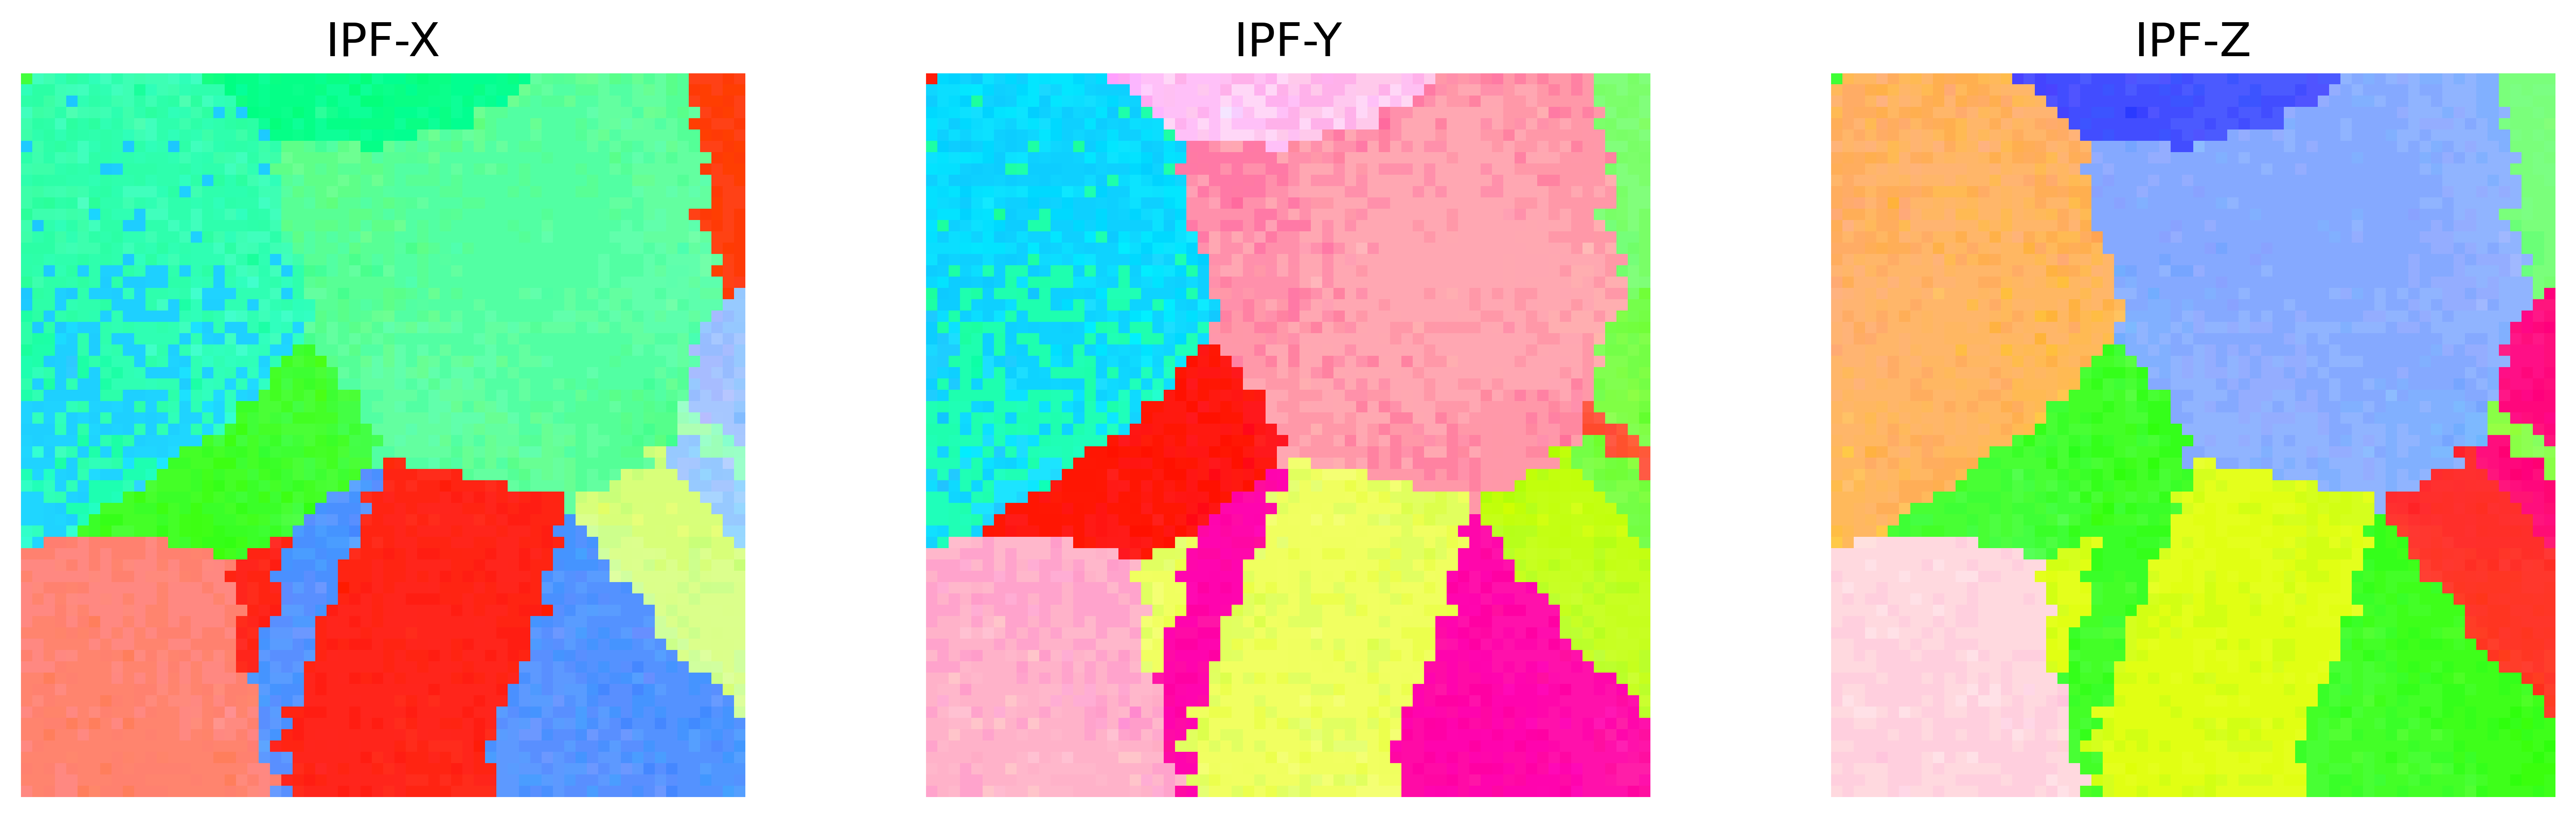

In [ ]:
# Load quaternion data for index 68
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",
    mask_alpha=0.55  # controls how transparent the red mask is
)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.plot import IPFColorKeyTSL
from orix.vector import Vector3d

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = ".",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    include_key: bool = True,
    overwrite: bool = True,
    tol_deg: float = 0.5,
    stride: int = None,
    mask_alpha: float = 0.5,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ and render:
      1. Original patch IPF
      2. FZ-reduced patch IPF
      3. Outside-FZ mask (red)
      4. Overlay with red mask on original
      5. Overlay with outside pixels blacked out
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # --- Compute outside mask for full image ---
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # --- Find worst patch ---
    best_frac = -1.0
    best_yx = (0, 0)
    best_patch = None

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)
                best_patch = q_spatial[y:y+patch_size, x:x+patch_size, :]

    if best_patch is None:
        raise RuntimeError("No valid patch found.")

    print(
        f"[FZ Region] Best patch at (y={best_yx[0]}, x={best_yx[1]}) "
        f"with {best_frac*100:.2f}% outside FZ"
    )

    # --- Map best patch into FZ ---
    ori_patch = Orientation(best_patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    q_patch_fz = ori_patch_fz.data.reshape(best_patch.shape)

    mis_patch = ori_patch_fz.inv() * ori_patch
    outside_mask_patch = (mis_patch.angle > np.deg2rad(tol_deg)).reshape(
        patch_size, patch_size
    )

    # --- Prepare file paths ---
    orig_patch_png = f"{out_dir}/{base_name}_orig_patch_y{best_yx[0]}_x{best_yx[1]}.png"
    fz_patch_png = f"{out_dir}/{base_name}_fz_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"
    mask_png = f"{out_dir}/{base_name}_mask_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"
    overlay_png = f"{out_dir}/{base_name}_overlay_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"
    blackout_png = f"{out_dir}/{base_name}_blackout_patch_y{best_yx[0]}_x{best_yx[1]}_{best_frac*100:.2f}.png"

    # --- Get IPF RGB array for original patch ---
    ipfkey = IPFColorKeyTSL(sym_class.laue)
    if ref_dir.upper() == "X":
        ipfkey.direction = Vector3d.xvector()
    elif ref_dir.upper() == "Y":
        ipfkey.direction = Vector3d.yvector()
    else:
        ipfkey.direction = Vector3d.zvector()
    ori_patch = Orientation(best_patch.reshape(-1, 4), symmetry=sym_class)
    ipf_rgb = ipfkey.orientation2color(ori_patch).reshape(
        patch_size, patch_size, 3
    )

    # --- Render original patch ---
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(ipf_rgb)
    ax.axis("off")
    ax.set_title("Original IPF Patch")
    fig.savefig(orig_patch_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # --- Render FZ-reduced patch ---
    ori_patch_fz2 = Orientation(q_patch_fz.reshape(-1, 4), symmetry=sym_class)
    ipf_rgb_fz = ipfkey.orientation2color(ori_patch_fz2).reshape(
        patch_size, patch_size, 3
    )
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(ipf_rgb_fz)
    ax.axis("off")
    ax.set_title("FZ-Reduced Patch")
    fig.savefig(fz_patch_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # --- Mask only ---
    mask_rgb = np.zeros((*outside_mask_patch.shape, 3), dtype=np.float32)
    mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_rgb)
    ax.axis("off")
    ax.set_title(f"Outside FZ Mask ({best_frac*100:.2f}%)")
    fig.savefig(mask_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # --- Overlay mask on original ---
    overlay_rgb = (ipf_rgb * (1 - mask_alpha * outside_mask_patch[..., None])
                   + mask_rgb * (mask_alpha * outside_mask_patch[..., None]))
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(overlay_rgb)
    ax.axis("off")
    ax.set_title("Overlay (red outside)")
    fig.savefig(overlay_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # --- Blackout outside pixels ---
    blackout_rgb = ipf_rgb.copy()
    blackout_rgb[outside_mask_patch] = [0.0, 0.0, 0.0]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(blackout_rgb)
    ax.axis("off")
    ax.set_title("Blackout Outside FZ")
    fig.savefig(blackout_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"[FZ Region] Saved original patch -> {orig_patch_png}")
    print(f"[FZ Region] Saved FZ-reduced patch -> {fz_patch_png}")
    print(f"[FZ Region] Saved mask -> {mask_png}")
    print(f"[FZ Region] Saved overlay -> {overlay_png}")
    print(f"[FZ Region] Saved blackout -> {blackout_png}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "patch_original": best_patch,
        "patch_fz": q_patch_fz,
        "outside_mask_patch": outside_mask_patch,
        "orig_patch_png": orig_patch_png,
        "fz_patch_png": fz_patch_png,
        "mask_png": mask_png,
        "overlay_png": overlay_png,
        "blackout_png": blackout_png,
    }


In [ ]:
# Load quaternion data for index 68
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="Z",
    mask_alpha=0.55
)


[FZ Region] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ Region] Saved original patch -> fz_patch_debug/idx_68_orig_patch_y0_x64.png
[FZ Region] Saved FZ-reduced patch -> fz_patch_debug/idx_68_fz_patch_y0_x64_3.37.png
[FZ Region] Saved mask -> fz_patch_debug/idx_68_mask_patch_y0_x64_3.37.png
[FZ Region] Saved overlay -> fz_patch_debug/idx_68_overlay_patch_y0_x64_3.37.png
[FZ Region] Saved blackout -> fz_patch_debug/idx_68_blackout_patch_y0_x64_3.37.png


In [ ]:
# Load quaternion data for index 68
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",
    mask_alpha=0.55
)


[FZ Region] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ Region] Saved original patch -> fz_patch_debug/idx_68_orig_patch_y0_x64.png
[FZ Region] Saved FZ-reduced patch -> fz_patch_debug/idx_68_fz_patch_y0_x64_3.37.png
[FZ Region] Saved mask -> fz_patch_debug/idx_68_mask_patch_y0_x64_3.37.png
[FZ Region] Saved overlay -> fz_patch_debug/idx_68_overlay_patch_y0_x64_3.37.png
[FZ Region] Saved blackout -> fz_patch_debug/idx_68_blackout_patch_y0_x64_3.37.png


In [ ]:
from typing import Optional, Union
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
import orix.plot as orix_plot

_DIRS = {
    "X": orix_plot.Vector3d.xvector(),
    "Y": orix_plot.Vector3d.yvector(),
    "Z": orix_plot.Vector3d.zvector(),
}

def render_ipf_image(
    arr_hw4: np.ndarray,
    sym_class,
    out_png: Optional[str] = None,
    ref_dir: str = "ALL",
    include_key: bool = True,
    overwrite: bool = False,
    return_rgb: bool = False,
) -> Union[str, np.ndarray, tuple]:
    """
    Render quaternion orientation array to an IPF image with consistent formatting.
    Can optionally return the RGB array for downstream visualization.

    Parameters
    ----------
    arr_hw4 : np.ndarray
        Array of shape (H, W, 4) representing quaternion orientations.
    sym_class : orix.symmetry.Symmetry
        Symmetry class to use for IPF coloring.
    out_png : str, optional
        Path to save the output PNG.
    ref_dir : {"X", "Y", "Z", "ALL"}, default="ALL"
        Reference direction for IPF coloring.
    include_key : bool, default=True
        Whether to include IPF key.
    overwrite : bool, default=False
        If False and file exists, skip rendering.
    return_rgb : bool, default=False
        If True, returns the RGB array used for plotting.

    Returns
    -------
    out_png or rgb or (out_png, rgb)
        Returns the file path if saved,
        the RGB array if return_rgb=True,
        or a tuple (out_png, rgb) if both.
    """
    if arr_hw4.shape[-1] != 4:
        raise ValueError(f"Expected (H,W,4) input, got {arr_hw4.shape}")

    if out_png and not overwrite and os.path.exists(out_png) and not return_rgb:
        return out_png

    ori = Orientation(arr_hw4)
    ori.symmetry = sym_class
    ckey = orix_plot.IPFColorKeyTSL(sym_class.laue)

    ref_dir_lc = ref_dir.lower()
    show_all = ref_dir_lc == "all"

    ncols = 3 if show_all else 1
    key_cols = 1 if include_key else 0
    fig_cols = ncols + key_cols
    wr = [1] * ncols + ([0.9] if include_key else [])

    fig = plt.figure(
        constrained_layout=False,
        figsize=(5.2 * ncols + (2.6 if include_key else 0), 4.8),
    )
    gs = fig.add_gridspec(1, fig_cols, width_ratios=wr, wspace=0.25)
    axes = [fig.add_subplot(gs[0, i]) for i in range(ncols)]

    rgb_out = None

    if show_all:
        rgb_list = []
        for name, ax in zip(("X", "Y", "Z"), axes):
            ckey.direction = _DIRS[name]
            rgb = ckey.orientation2color(~ori)
            rgb_list.append(rgb)
            ax.imshow(rgb)
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(f"IPF-{name}")
            ax.axis("off")
        # For return_rgb, default to Z-direction or average
        rgb_out = rgb_list[2]
    else:
        ref = ref_dir.upper()
        if ref not in _DIRS:
            raise ValueError("ref_dir must be 'X','Y','Z','ALL'")
        ckey.direction = _DIRS[ref]
        rgb_out = ckey.orientation2color(~ori)
        axes[0].imshow(rgb_out)
        axes[0].set_aspect("equal", adjustable="box")
        axes[0].set_title(f"IPF-{ref}")
        axes[0].axis("off")

    if include_key:
        ax_ipf = fig.add_subplot(
            gs[0, -1], projection="ipf", symmetry=ori.symmetry.laue
        )
        ax_ipf.plot_ipf_color_key()
        ax_ipf.set_title("")

    if out_png:
        os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
        fig.savefig(out_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    if return_rgb and out_png:
        return out_png, rgb_out
    elif return_rgb:
        return rgb_out
    else:
        return out_png


AttributeError: module 'orix.plot' has no attribute 'Vector3d'

In [ ]:
from typing import Optional, Union
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
import orix.plot as orix_plot
from orix.vector import Vector3d  # <-- Correct import

# Reference direction vectors
_DIRS = {
    "X": Vector3d.xvector(),
    "Y": Vector3d.yvector(),
    "Z": Vector3d.zvector(),
}

def render_ipf_image(
    arr_hw4: np.ndarray,
    sym_class,
    out_png: Optional[str] = None,
    ref_dir: str = "ALL",
    include_key: bool = True,
    overwrite: bool = False,
    return_rgb: bool = False,
) -> Union[str, np.ndarray, tuple]:
    """
    Render quaternion orientation array to an IPF image with consistent formatting.
    Can optionally return the RGB array for downstream visualization.

    Parameters
    ----------
    arr_hw4 : np.ndarray
        Array of shape (H, W, 4) representing quaternion orientations.
    sym_class : orix.symmetry.Symmetry
        Symmetry class to use for IPF coloring.
    out_png : str, optional
        Path to save the output PNG.
    ref_dir : {"X", "Y", "Z", "ALL"}, default="ALL"
        Reference direction for IPF coloring.
    include_key : bool, default=True
        Whether to include IPF key.
    overwrite : bool, default=False
        If False and file exists, skip rendering.
    return_rgb : bool, default=False
        If True, returns the RGB array used for plotting.

    Returns
    -------
    out_png or rgb or (out_png, rgb)
        Returns the file path if saved,
        the RGB array if return_rgb=True,
        or a tuple (out_png, rgb) if both.
    """
    if arr_hw4.shape[-1] != 4:
        raise ValueError(f"Expected (H,W,4) input, got {arr_hw4.shape}")

    if out_png and not overwrite and os.path.exists(out_png) and not return_rgb:
        return out_png

    ori = Orientation(arr_hw4)
    ori.symmetry = sym_class
    ckey = orix_plot.IPFColorKeyTSL(sym_class.laue)

    ref_dir_lc = ref_dir.lower()
    show_all = ref_dir_lc == "all"

    ncols = 3 if show_all else 1
    key_cols = 1 if include_key else 0
    fig_cols = ncols + key_cols
    wr = [1] * ncols + ([0.9] if include_key else [])

    fig = plt.figure(
        constrained_layout=False,
        figsize=(5.2 * ncols + (2.6 if include_key else 0), 4.8),
    )
    gs = fig.add_gridspec(1, fig_cols, width_ratios=wr, wspace=0.25)
    axes = [fig.add_subplot(gs[0, i]) for i in range(ncols)]

    rgb_out = None

    if show_all:
        rgb_list = []
        for name, ax in zip(("X", "Y", "Z"), axes):
            ckey.direction = _DIRS[name]
            rgb = ckey.orientation2color(~ori)
            rgb_list.append(rgb)
            ax.imshow(rgb)
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(f"IPF-{name}")
            ax.axis("off")
        # For return_rgb, default to Z-direction or average
        rgb_out = rgb_list[2]
    else:
        ref = ref_dir.upper()
        if ref not in _DIRS:
            raise ValueError("ref_dir must be 'X','Y','Z','ALL'")
        ckey.direction = _DIRS[ref]
        rgb_out = ckey.orientation2color(~ori)
        axes[0].imshow(rgb_out)
        axes[0].set_aspect("equal", adjustable="box")
        axes[0].set_title(f"IPF-{ref}")
        axes[0].axis("off")

    if include_key:
        ax_ipf = fig.add_subplot(
            gs[0, -1], projection="ipf", symmetry=ori.symmetry.laue
        )
        ax_ipf.plot_ipf_color_key()
        ax_ipf.set_title("")

    if out_png:
        os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
        fig.savefig(out_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    if return_rgb and out_png:
        return out_png, rgb_out
    elif return_rgb:
        return rgb_out
    else:
        return out_png


In [ ]:
# Render to file
render_ipf_image(q_spatial, train_ds.sym_class, out_png="patch.png", ref_dir="Z")

# Get RGB array only
rgb = render_ipf_image(q_spatial, train_ds.sym_class, ref_dir="Z", return_rgb=True)
print(rgb.shape)  # (H, W, 3)

# Save and get RGB at once
path, rgb = render_ipf_image(
    q_spatial, train_ds.sym_class,
    out_png="patch.png", ref_dir="Z",
    return_rgb=True
)


(128, 128, 3)


In [ ]:
rgb

array([[[0.26521825, 1.        , 0.15399055],
        [0.20497788, 1.        , 0.10472459],
        [0.2652186 , 1.        , 0.15399056],
        ...,
        [0.48021438, 1.        , 0.48306384],
        [0.48021422, 1.        , 0.48306356],
        [0.48021438, 1.        , 0.48306384]],

       [[0.24696146, 1.        , 0.10275002],
        [0.24696146, 1.        , 0.10275002],
        [0.24696146, 1.        , 0.10275002],
        ...,
        [0.48021438, 1.        , 0.48306384],
        [0.48591172, 1.        , 0.51715543],
        [0.48591172, 1.        , 0.51715543]],

       [[0.26521825, 1.        , 0.15399055],
        [0.24696134, 1.        , 0.10275005],
        [0.26521825, 1.        , 0.15399055],
        ...,
        [0.48591172, 1.        , 0.51715543],
        [0.48021422, 1.        , 0.48306356],
        [0.48021438, 1.        , 0.48306384]],

       ...,

       [[0.69314094, 0.60876087, 1.        ],
        [0.69314094, 0.60876087, 1.        ],
        [0.67635053, 0

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from render_ipf_image import render_ipf_image  # make sure this points to your version

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "Z",
    tol_deg: float = 0.5,
    stride: int = None,
    mask_alpha: float = 0.5,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ
    and render IPF visualizations for inspection.

    Parameters
    ----------
    q_spatial : (H,W,4) ndarray
        Quaternion field.
    sym_class : orix.symmetry.Symmetry
        Symmetry class.
    patch_size : int
        Size of square patch to check.
    out_dir : str
        Output directory for saved plots.
    base_name : str
        Base filename for outputs.
    ref_dir : str
        IPF reference direction ("X","Y","Z").
    tol_deg : float
        Misorientation tolerance in degrees to count as outside FZ.
    stride : int
        Step size when scanning patches (default = patch_size).
    mask_alpha : float
        Transparency factor for overlay mask.

    Returns
    -------
    dict
        Information and file paths for the rendered patch.
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # Compute outside mask for full image
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # Find worst patch
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # FZ reduce the patch
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    # Filenames
    frac_tag = f"{best_frac*100:.2f}"
    orig_png = os.path.join(out_dir, f"{base_name}_orig_y{y0}_x{x0}_{frac_tag}.png")
    fz_png = os.path.join(out_dir, f"{base_name}_fz_y{y0}_x{x0}_{frac_tag}.png")
    mask_png = os.path.join(out_dir, f"{base_name}_mask_y{y0}_x{x0}_{frac_tag}.png")
    overlay_png = os.path.join(out_dir, f"{base_name}_overlay_y{y0}_x{x0}_{frac_tag}.png")
    blackout_png = os.path.join(out_dir, f"{base_name}_blackout_y{y0}_x{x0}_{frac_tag}.png")

    # Original and FZ IPF images
    rgb_orig = render_ipf_image(patch, sym_class, out_png=orig_png, ref_dir=ref_dir, return_rgb=True)
    rgb_fz = render_ipf_image(patch_fz, sym_class, out_png=fz_png, ref_dir=ref_dir, return_rgb=True)

    # Red mask
    mask_rgb = np.zeros_like(rgb_orig)
    mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_rgb)
    ax.axis("off")
    ax.set_title(f"Outside FZ ({frac_tag}%)")
    fig.savefig(mask_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # Overlay (red transparency)
    overlay_rgb = rgb_orig * (1 - mask_alpha * outside_mask_patch[..., None]) \
                + mask_rgb * (mask_alpha * outside_mask_patch[..., None])
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(overlay_rgb)
    ax.axis("off")
    ax.set_title("Overlay (red = outside)")
    fig.savefig(overlay_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # Blackout (outside = black)
    blackout_rgb = rgb_orig.copy()
    blackout_rgb[outside_mask_patch] = [0, 0, 0]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(blackout_rgb)
    ax.axis("off")
    ax.set_title("Blackout Outside FZ")
    fig.savefig(blackout_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"[FZ] Saved visualizations → {out_dir}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "orig_png": orig_png,
        "fz_png": fz_png,
        "mask_png": mask_png,
        "overlay_png": overlay_png,
        "blackout_png": blackout_png,
    }


ModuleNotFoundError: No module named 'render_ipf_image'

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "Z",
    tol_deg: float = 0.5,
    stride: int = None,
    mask_alpha: float = 0.5,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ
    and render IPF visualizations for inspection.

    Parameters
    ----------
    q_spatial : (H,W,4) ndarray
        Quaternion field.
    sym_class : orix.symmetry.Symmetry
        Symmetry class.
    patch_size : int
        Size of square patch to check.
    out_dir : str
        Output directory for saved plots.
    base_name : str
        Base filename for outputs.
    ref_dir : str
        IPF reference direction ("X","Y","Z").
    tol_deg : float
        Misorientation tolerance in degrees to count as outside FZ.
    stride : int
        Step size when scanning patches (default = patch_size).
    mask_alpha : float
        Transparency factor for overlay mask.

    Returns
    -------
    dict
        Information and file paths for the rendered patch.
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # Compute outside mask for full image
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # Find worst patch
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # FZ reduce the patch
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    # Filenames
    frac_tag = f"{best_frac*100:.2f}"
    orig_png = os.path.join(out_dir, f"{base_name}_orig_y{y0}_x{x0}_{frac_tag}.png")
    fz_png = os.path.join(out_dir, f"{base_name}_fz_y{y0}_x{x0}_{frac_tag}.png")
    mask_png = os.path.join(out_dir, f"{base_name}_mask_y{y0}_x{x0}_{frac_tag}.png")
    overlay_png = os.path.join(out_dir, f"{base_name}_overlay_y{y0}_x{x0}_{frac_tag}.png")
    blackout_png = os.path.join(out_dir, f"{base_name}_blackout_y{y0}_x{x0}_{frac_tag}.png")

    # Original and FZ IPF images
    rgb_orig = render_ipf_image(patch, sym_class, out_png=orig_png, ref_dir=ref_dir, return_rgb=True)
    rgb_fz = render_ipf_image(patch_fz, sym_class, out_png=fz_png, ref_dir=ref_dir, return_rgb=True)

    # Red mask
    mask_rgb = np.zeros_like(rgb_orig)
    mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_rgb)
    ax.axis("off")
    ax.set_title(f"Outside FZ ({frac_tag}%)")
    fig.savefig(mask_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # Overlay (red transparency)
    overlay_rgb = rgb_orig * (1 - mask_alpha * outside_mask_patch[..., None]) \
                + mask_rgb * (mask_alpha * outside_mask_patch[..., None])
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(overlay_rgb)
    ax.axis("off")
    ax.set_title("Overlay (red = outside)")
    fig.savefig(overlay_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # Blackout (outside = black)
    blackout_rgb = rgb_orig.copy()
    blackout_rgb[outside_mask_patch] = [0, 0, 0]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(blackout_rgb)
    ax.axis("off")
    ax.set_title("Blackout Outside FZ")
    fig.savefig(blackout_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"[FZ] Saved visualizations → {out_dir}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "orig_png": orig_png,
        "fz_png": fz_png,
        "mask_png": mask_png,
        "overlay_png": overlay_png,
        "blackout_png": blackout_png,
    }


In [ ]:
# Load quaternion data for a file
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="Z",
    tol_deg=0.5,
    mask_alpha=0.6,
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from render_ipf_image import render_ipf_image

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "Z",
    tol_deg: float = 0.5,
    stride: int = None,
    mask_alpha: float = 0.5,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ
    and render IPF visualizations for inspection.
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # --- Compute outside mask for full image ---
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # --- Find worst patch ---
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # --- FZ reduce the patch ---
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    frac_tag = f"{best_frac*100:.2f}"
    orig_png = os.path.join(out_dir, f"{base_name}_orig_y{y0}_x{x0}_{frac_tag}.png")
    fz_png = os.path.join(out_dir, f"{base_name}_fz_y{y0}_x{x0}_{frac_tag}.png")
    mask_png = os.path.join(out_dir, f"{base_name}_mask_y{y0}_x{x0}_{frac_tag}.png")
    overlay_png = os.path.join(out_dir, f"{base_name}_overlay_y{y0}_x{x0}_{frac_tag}.png")
    blackout_png = os.path.join(out_dir, f"{base_name}_blackout_y{y0}_x{x0}_{frac_tag}.png")

    # --- Ensure we get a single RGB array ---
    rgb_orig = render_ipf_image(patch, sym_class, out_png=orig_png, ref_dir=ref_dir, return_rgb=True)
    rgb_fz = render_ipf_image(patch_fz, sym_class, out_png=fz_png, ref_dir=ref_dir, return_rgb=True)

    # If ref_dir="ALL", take Z-direction image (3rd in list)
    if isinstance(rgb_orig, list):
        rgb_orig = rgb_orig[2]
    if isinstance(rgb_fz, list):
        rgb_fz = rgb_fz[2]

    # --- Red mask ---
    mask_rgb = np.zeros_like(rgb_orig)
    mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_rgb)
    ax.axis("off")
    ax.set_title(f"Outside FZ ({frac_tag}%)")
    fig.savefig(mask_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # --- Overlay ---
    overlay_rgb = rgb_orig * (1 - mask_alpha * outside_mask_patch[..., None]) \
                + mask_rgb * (mask_alpha * outside_mask_patch[..., None])
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(overlay_rgb)
    ax.axis("off")
    ax.set_title("Overlay (red = outside)")
    fig.savefig(overlay_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # --- Blackout ---
    blackout_rgb = rgb_orig.copy()
    blackout_rgb[outside_mask_patch] = [0, 0, 0]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(blackout_rgb)
    ax.axis("off")
    ax.set_title("Blackout Outside FZ")
    fig.savefig(blackout_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"[FZ] Saved visualizations → {out_dir}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "orig_png": orig_png,
        "fz_png": fz_png,
        "mask_png": mask_png,
        "overlay_png": overlay_png,
        "blackout_png": blackout_png,
    }


ModuleNotFoundError: No module named 'render_ipf_image'

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "Z",
    tol_deg: float = 0.5,
    stride: int = None,
    mask_alpha: float = 0.5,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ
    and render IPF visualizations for inspection.
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # --- Compute outside mask for full image ---
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # --- Find worst patch ---
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # --- FZ reduce the patch ---
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    frac_tag = f"{best_frac*100:.2f}"
    orig_png = os.path.join(out_dir, f"{base_name}_orig_y{y0}_x{x0}_{frac_tag}.png")
    fz_png = os.path.join(out_dir, f"{base_name}_fz_y{y0}_x{x0}_{frac_tag}.png")
    mask_png = os.path.join(out_dir, f"{base_name}_mask_y{y0}_x{x0}_{frac_tag}.png")
    overlay_png = os.path.join(out_dir, f"{base_name}_overlay_y{y0}_x{x0}_{frac_tag}.png")
    blackout_png = os.path.join(out_dir, f"{base_name}_blackout_y{y0}_x{x0}_{frac_tag}.png")

    # --- Ensure we get a single RGB array ---
    rgb_orig = render_ipf_image(patch, sym_class, out_png=orig_png, ref_dir=ref_dir, return_rgb=True)
    rgb_fz = render_ipf_image(patch_fz, sym_class, out_png=fz_png, ref_dir=ref_dir, return_rgb=True)

    # If ref_dir="ALL", take Z-direction image (3rd in list)
    if isinstance(rgb_orig, list):
        rgb_orig = rgb_orig[2]
    if isinstance(rgb_fz, list):
        rgb_fz = rgb_fz[2]

    # --- Red mask ---
    mask_rgb = np.zeros_like(rgb_orig)
    mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_rgb)
    ax.axis("off")
    ax.set_title(f"Outside FZ ({frac_tag}%)")
    fig.savefig(mask_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # --- Overlay ---
    overlay_rgb = rgb_orig * (1 - mask_alpha * outside_mask_patch[..., None]) \
                + mask_rgb * (mask_alpha * outside_mask_patch[..., None])
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(overlay_rgb)
    ax.axis("off")
    ax.set_title("Overlay (red = outside)")
    fig.savefig(overlay_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # --- Blackout ---
    blackout_rgb = rgb_orig.copy()
    blackout_rgb[outside_mask_patch] = [0, 0, 0]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(blackout_rgb)
    ax.axis("off")
    ax.set_title("Blackout Outside FZ")
    fig.savefig(blackout_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"[FZ] Saved visualizations → {out_dir}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "orig_png": orig_png,
        "fz_png": fz_png,
        "mask_png": mask_png,
        "overlay_png": overlay_png,
        "blackout_png": blackout_png,
    }


In [ ]:
# Load quaternion data for a file
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="Z",
    tol_deg=0.5,
    mask_alpha=0.6,
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from render_ipf_image import render_ipf_image

_DIR_NAMES = ("X", "Y", "Z")

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    tol_deg: float = 0.5,
    stride: int = None,
    mask_alpha: float = 0.5,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ
    and render IPF visualizations in X/Y/Z directions, consistent with render_ipf_image.
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # --- Compute outside mask ---
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # --- Find patch with max outside fraction ---
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # --- FZ reduce patch ---
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    frac_tag = f"{best_frac*100:.2f}"
    results = []

    # --- Loop over directions ---
    directions = _DIR_NAMES if ref_dir.upper() == "ALL" else (ref_dir.upper(),)

    for d in directions:
        orig_png = os.path.join(out_dir, f"{base_name}_orig_{d}_y{y0}_x{x0}_{frac_tag}.png")
        fz_png = os.path.join(out_dir, f"{base_name}_fz_{d}_y{y0}_x{x0}_{frac_tag}.png")
        mask_png = os.path.join(out_dir, f"{base_name}_mask_{d}_y{y0}_x{x0}_{frac_tag}.png")
        overlay_png = os.path.join(out_dir, f"{base_name}_overlay_{d}_y{y0}_x{x0}_{frac_tag}.png")
        blackout_png = os.path.join(out_dir, f"{base_name}_blackout_{d}_y{y0}_x{x0}_{frac_tag}.png")

        # --- Get RGB ---
        rgb_orig = render_ipf_image(patch, sym_class, out_png=orig_png, ref_dir=d, return_rgb=True)
        rgb_fz = render_ipf_image(patch_fz, sym_class, out_png=fz_png, ref_dir=d, return_rgb=True)

        # --- Mask ---
        mask_rgb = np.zeros_like(rgb_orig)
        mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(mask_rgb)
        ax.axis("off")
        ax.set_title(f"Outside FZ ({frac_tag}%) - {d}")
        fig.savefig(mask_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        # --- Overlay ---
        overlay_rgb = rgb_orig * (1 - mask_alpha * outside_mask_patch[..., None]) \
                    + mask_rgb * (mask_alpha * outside_mask_patch[..., None])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(overlay_rgb)
        ax.axis("off")
        ax.set_title(f"Overlay (red=outside) - {d}")
        fig.savefig(overlay_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        # --- Blackout ---
        blackout_rgb = rgb_orig.copy()
        blackout_rgb[outside_mask_patch] = [0, 0, 0]
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(blackout_rgb)
        ax.axis("off")
        ax.set_title(f"Blackout Outside FZ - {d}")
        fig.savefig(blackout_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        results.append({
            "direction": d,
            "orig_png": orig_png,
            "fz_png": fz_png,
            "mask_png": mask_png,
            "overlay_png": overlay_png,
            "blackout_png": blackout_png,
        })

    print(f"[FZ] Saved visualizations for directions {directions} → {out_dir}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "results": results
    }


ModuleNotFoundError: No module named 'render_ipf_image'

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation

_DIR_NAMES = ("X", "Y", "Z")

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    tol_deg: float = 0.5,
    stride: int = None,
    mask_alpha: float = 0.5,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ
    and render IPF visualizations in X/Y/Z directions, consistent with render_ipf_image.
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # --- Compute outside mask ---
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # --- Find patch with max outside fraction ---
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # --- FZ reduce patch ---
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    frac_tag = f"{best_frac*100:.2f}"
    results = []

    # --- Loop over directions ---
    directions = _DIR_NAMES if ref_dir.upper() == "ALL" else (ref_dir.upper(),)

    for d in directions:
        orig_png = os.path.join(out_dir, f"{base_name}_orig_{d}_y{y0}_x{x0}_{frac_tag}.png")
        fz_png = os.path.join(out_dir, f"{base_name}_fz_{d}_y{y0}_x{x0}_{frac_tag}.png")
        mask_png = os.path.join(out_dir, f"{base_name}_mask_{d}_y{y0}_x{x0}_{frac_tag}.png")
        overlay_png = os.path.join(out_dir, f"{base_name}_overlay_{d}_y{y0}_x{x0}_{frac_tag}.png")
        blackout_png = os.path.join(out_dir, f"{base_name}_blackout_{d}_y{y0}_x{x0}_{frac_tag}.png")

        # --- Get RGB ---
        rgb_orig = render_ipf_image(patch, sym_class, out_png=orig_png, ref_dir=d, return_rgb=True)
        rgb_fz = render_ipf_image(patch_fz, sym_class, out_png=fz_png, ref_dir=d, return_rgb=True)

        # --- Mask ---
        mask_rgb = np.zeros_like(rgb_orig)
        mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(mask_rgb)
        ax.axis("off")
        ax.set_title(f"Outside FZ ({frac_tag}%) - {d}")
        fig.savefig(mask_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        # --- Overlay ---
        overlay_rgb = rgb_orig * (1 - mask_alpha * outside_mask_patch[..., None]) \
                    + mask_rgb * (mask_alpha * outside_mask_patch[..., None])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(overlay_rgb)
        ax.axis("off")
        ax.set_title(f"Overlay (red=outside) - {d}")
        fig.savefig(overlay_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        # --- Blackout ---
        blackout_rgb = rgb_orig.copy()
        blackout_rgb[outside_mask_patch] = [0, 0, 0]
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(blackout_rgb)
        ax.axis("off")
        ax.set_title(f"Blackout Outside FZ - {d}")
        fig.savefig(blackout_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        results.append({
            "direction": d,
            "orig_png": orig_png,
            "fz_png": fz_png,
            "mask_png": mask_png,
            "overlay_png": overlay_png,
            "blackout_png": blackout_png,
        })

    print(f"[FZ] Saved visualizations for directions {directions} → {out_dir}")

    return {
        "best_yx": best_yx,
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "results": results
    }


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # now generates X, Y, Z images separately
    tol_deg=0.5,
    mask_alpha=0.6,
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="Z",  # now generates X, Y, Z images separately
    tol_deg=0.5,
    mask_alpha=0.6,
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix import plot as orix_plot
from orix.vector import Vector3d

# Direction vectors for IPF coloring
_DIRS = {
    "X": Vector3d.xvector(),
    "Y": Vector3d.yvector(),
    "Z": Vector3d.zvector(),
}

def render_ipf_image(
    arr_hw4: np.ndarray,
    sym_class,
    out_png: str = None,
    ref_dir: str = "ALL",
    include_key: bool = False,
    overwrite: bool = False,
    return_rgb: bool = False,
):
    """Render quaternion orientation array to an IPF image with consistent formatting."""
    if arr_hw4.shape[-1] != 4:
        raise ValueError(f"Expected (H,W,4) input, got {arr_hw4.shape}")

    if out_png and not overwrite and os.path.exists(out_png):
        return out_png

    ori = Orientation(arr_hw4)
    ori.symmetry = sym_class
    ckey = orix_plot.IPFColorKeyTSL(sym_class.laue)

    ref_dir_lc = ref_dir.lower()
    show_all = ref_dir_lc == "all"
    directions = ("X", "Y", "Z") if show_all else (ref_dir.upper(),)

    rgb_outputs = []

    for d in directions:
        ckey.direction = _DIRS[d]
        rgb = ckey.orientation2color(~ori)
        rgb_outputs.append(rgb)

        if out_png:
            d_tag = f"_{d}" if show_all else ""
            out_path = out_png.replace(".png", f"{d_tag}.png")
            fig, ax = plt.subplots(figsize=(4, 4))
            ax.imshow(rgb)
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(f"IPF-{d}")
            ax.axis("off")
            fig.savefig(out_path, bbox_inches="tight", dpi=300)
            plt.close(fig)

    return rgb_outputs if show_all else rgb_outputs[0]

def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    tol_deg: float = 0.5,
    stride: int = None,
    mask_alpha: float = 0.5,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ
    and render IPF visualizations in X/Y/Z directions, consistent with render_ipf_image.
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # --- Compute outside mask ---
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # --- Find worst patch ---
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # --- FZ reduce patch ---
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    frac_tag = f"{best_frac*100:.2f}"
    results = []
    directions = ("X", "Y", "Z") if ref_dir.upper() == "ALL" else (ref_dir.upper(),)

    for d in directions:
        # File paths
        orig_png = os.path.join(out_dir, f"{base_name}_orig_{d}_y{y0}_x{x0}_{frac_tag}.png")
        fz_png = os.path.join(out_dir, f"{base_name}_fz_{d}_y{y0}_x{x0}_{frac_tag}.png")
        mask_png = os.path.join(out_dir, f"{base_name}_mask_{d}_y{y0}_x{x0}_{frac_tag}.png")
        overlay_png = os.path.join(out_dir, f"{base_name}_overlay_{d}_y{y0}_x{x0}_{frac_tag}.png")
        blackout_png = os.path.join(out_dir, f"{base_name}_blackout_{d}_y{y0}_x{x0}_{frac_tag}.png")

        # RGB render
        rgb_orig = render_ipf_image(patch, sym_class, out_png=orig_png, ref_dir=d, return_rgb=True)
        rgb_fz = render_ipf_image(patch_fz, sym_class, out_png=fz_png, ref_dir=d, return_rgb=True)

        # Mask image
        mask_rgb = np.zeros_like(rgb_orig)
        mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(mask_rgb)
        ax.axis("off")
        ax.set_title(f"Outside FZ ({frac_tag}%) - {d}")
        fig.savefig(mask_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        # Overlay
        overlay_rgb = rgb_orig * (1 - mask_alpha * outside_mask_patch[..., None]) \
                    + mask_rgb * (mask_alpha * outside_mask_patch[..., None])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(overlay_rgb)
        ax.axis("off")
        ax.set_title(f"Overlay (red=outside) - {d}")
        fig.savefig(overlay_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        # Blackout
        blackout_rgb = rgb_orig.copy()
        blackout_rgb[outside_mask_patch] = [0, 0, 0]
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(blackout_rgb)
        ax.axis("off")
        ax.set_title(f"Blackout Outside FZ - {d}")
        fig.savefig(blackout_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        results.append({
            "direction": d,
            "orig_png": orig_png,
            "fz_png": fz_png,
            "mask_png": mask_png,
            "overlay_png": overlay_png,
            "blackout_png": blackout_png,
        })

    print(f"[FZ] Saved visualizations for directions {directions} → {out_dir}")

    return {
        "best_yx": (y0, x0),
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "results": results,
    }


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # fully supported: X, Y, Z
    tol_deg=0.5,
    mask_alpha=0.6,
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ


IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix import plot as orix_plot
from orix.vector import Vector3d

# -----------------------------------------------------------
# Helper: Direction vectors for IPF coloring
# -----------------------------------------------------------
_DIRS = {
    "X": Vector3d.xvector(),
    "Y": Vector3d.yvector(),
    "Z": Vector3d.zvector(),
}

# -----------------------------------------------------------
# Helper: Render quaternion orientation array to IPF image
# -----------------------------------------------------------
def render_ipf_image(
    arr_hw4: np.ndarray,
    sym_class,
    out_png: str = None,
    ref_dir: str = "ALL",
    include_key: bool = False,
    overwrite: bool = False,
    return_rgb: bool = False,
):
    """
    Render quaternion orientation array to an IPF image with consistent formatting.
    If ref_dir='ALL', returns three RGB arrays for X/Y/Z directions.
    """
    if arr_hw4.shape[-1] != 4:
        raise ValueError(f"Expected (H,W,4) input, got {arr_hw4.shape}")

    if out_png and not overwrite and os.path.exists(out_png):
        return out_png

    ori = Orientation(arr_hw4)
    ori.symmetry = sym_class
    ckey = orix_plot.IPFColorKeyTSL(sym_class.laue)

    ref_dir_lc = ref_dir.lower()
    show_all = ref_dir_lc == "all"
    directions = ("X", "Y", "Z") if show_all else (ref_dir.upper(),)

    rgb_outputs = []

    for d in directions:
        ckey.direction = _DIRS[d]
        rgb = ckey.orientation2color(~ori)
        rgb_outputs.append(rgb)

        if out_png:
            d_tag = f"_{d}" if show_all else ""
            out_path = out_png.replace(".png", f"{d_tag}.png")
            fig, ax = plt.subplots(figsize=(4, 4))
            ax.imshow(rgb)
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(f"IPF-{d}")
            ax.axis("off")
            fig.savefig(out_path, bbox_inches="tight", dpi=300)
            plt.close(fig)

    if return_rgb:
        return rgb_outputs if show_all else rgb_outputs[0]
    else:
        return out_png

# -----------------------------------------------------------
# Main: Find and visualize worst FZ region
# -----------------------------------------------------------
def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    tol_deg: float = 0.5,
    stride: int = None,
    mask_alpha: float = 0.5,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ
    and render IPF visualizations in X/Y/Z directions.
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # --- Compute outside mask ---
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # --- Find patch with max outside fraction ---
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # --- FZ reduced patch ---
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    frac_tag = f"{best_frac*100:.2f}"
    results = []
    directions = ("X", "Y", "Z") if ref_dir.upper() == "ALL" else (ref_dir.upper(),)

    for d in directions:
        # File paths
        orig_png = os.path.join(out_dir, f"{base_name}_orig_{d}_y{y0}_x{x0}_{frac_tag}.png")
        fz_png = os.path.join(out_dir, f"{base_name}_fz_{d}_y{y0}_x{x0}_{frac_tag}.png")
        mask_png = os.path.join(out_dir, f"{base_name}_mask_{d}_y{y0}_x{x0}_{frac_tag}.png")
        overlay_png = os.path.join(out_dir, f"{base_name}_overlay_{d}_y{y0}_x{x0}_{frac_tag}.png")
        blackout_png = os.path.join(out_dir, f"{base_name}_blackout_{d}_y{y0}_x{x0}_{frac_tag}.png")

        # RGB render
        rgb_orig = render_ipf_image(patch, sym_class, out_png=orig_png, ref_dir=d, return_rgb=True)
        rgb_fz = render_ipf_image(patch_fz, sym_class, out_png=fz_png, ref_dir=d, return_rgb=True)

        # --- Validate shape ---
        if rgb_orig is None or not isinstance(rgb_orig, np.ndarray) or rgb_orig.ndim != 3:
            raise ValueError(f"[FZ] Failed to render IPF image for direction {d}. Got {type(rgb_orig)}")

        if rgb_orig.shape[:2] != outside_mask_patch.shape:
            raise ValueError(
                f"[FZ] Shape mismatch: rgb {rgb_orig.shape[:2]} vs mask {outside_mask_patch.shape}"
            )

        # --- Mask image ---
        mask_rgb = np.zeros_like(rgb_orig)
        mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(mask_rgb)
        ax.axis("off")
        ax.set_title(f"Outside FZ ({frac_tag}%) - {d}")
        fig.savefig(mask_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        # --- Overlay ---
        overlay_rgb = rgb_orig * (1 - mask_alpha * outside_mask_patch[..., None]) \
                    + mask_rgb * (mask_alpha * outside_mask_patch[..., None])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(overlay_rgb)
        ax.axis("off")
        ax.set_title(f"Overlay (red=outside) - {d}")
        fig.savefig(overlay_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        # --- Blackout ---
        blackout_rgb = rgb_orig.copy()
        blackout_rgb[outside_mask_patch] = [0, 0, 0]
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(blackout_rgb)
        ax.axis("off")
        ax.set_title(f"Blackout Outside FZ - {d}")
        fig.savefig(blackout_png, bbox_inches="tight", dpi=300)
        plt.close(fig)

        results.append({
            "direction": d,
            "orig_png": orig_png,
            "fz_png": fz_png,
            "mask_png": mask_png,
            "overlay_png": overlay_png,
            "blackout_png": blackout_png,
        })

    print(f"[FZ] Saved visualizations for directions {directions} → {out_dir}")

    return {
        "best_yx": (y0, x0),
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "results": results,
    }


In [ ]:
# Load quaternion image for a specific sample
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

# Visualize worst patch
result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # generates X, Y, Z plots
    tol_deg=0.5,
    mask_alpha=0.6,
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ] Saved visualizations for directions ('X', 'Y', 'Z') → fz_patch_debug


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix import plot as orix_plot
from orix.vector import Vector3d

# -----------------------------------------------------------
# Helper: Direction vectors for IPF coloring
# -----------------------------------------------------------
_DIRS = {
    "X": Vector3d.xvector(),
    "Y": Vector3d.yvector(),
    "Z": Vector3d.zvector(),
}

# -----------------------------------------------------------
# Helper: Render quaternion orientation array to IPF image
# -----------------------------------------------------------
def render_ipf_image(
    arr_hw4: np.ndarray,
    sym_class,
    out_png: str = None,
    ref_dir: str = "ALL",
    include_key: bool = False,
    overwrite: bool = False,
    return_rgb: bool = False,
):
    """
    Render quaternion orientation array to an IPF image with consistent formatting.
    If ref_dir='ALL', returns three RGB arrays for X/Y/Z directions.
    """
    if arr_hw4.shape[-1] != 4:
        raise ValueError(f"Expected (H,W,4) input, got {arr_hw4.shape}")

    if out_png and not overwrite and os.path.exists(out_png):
        return out_png

    ori = Orientation(arr_hw4)
    ori.symmetry = sym_class
    ckey = orix_plot.IPFColorKeyTSL(sym_class.laue)

    ref_dir_lc = ref_dir.lower()
    show_all = ref_dir_lc == "all"
    directions = ("X", "Y", "Z") if show_all else (ref_dir.upper(),)

    rgb_outputs = []

    for d in directions:
        ckey.direction = _DIRS[d]
        rgb = ckey.orientation2color(~ori)
        rgb_outputs.append(rgb)

        if out_png:
            d_tag = f"_{d}" if show_all else ""
            out_path = out_png.replace(".png", f"{d_tag}.png")
            fig, ax = plt.subplots(figsize=(4, 4))
            ax.imshow(rgb)
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(f"IPF-{d}")
            ax.axis("off")
            fig.savefig(out_path, bbox_inches="tight", dpi=300)
            plt.close(fig)

    if return_rgb:
        return rgb_outputs if show_all else rgb_outputs[0]
    else:
        return out_png

# -----------------------------------------------------------
# Main: Find and visualize worst FZ region
# -----------------------------------------------------------
def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    tol_deg: float = 0.5,
    stride: int = None,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ,
    render IPF images in X/Y/Z, and create a single red/black FZ mask image.
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # --- Compute outside mask ---
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # --- Find worst patch ---
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # --- FZ reduced patch ---
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    frac_tag = f"{best_frac*100:.2f}"
    directions = ("X", "Y", "Z") if ref_dir.upper() == "ALL" else (ref_dir.upper(),)

    # --- Render original and FZ IPF images ---
    for d in directions:
        orig_png = os.path.join(out_dir, f"{base_name}_orig_{d}_y{y0}_x{x0}_{frac_tag}.png")
        fz_png = os.path.join(out_dir, f"{base_name}_fz_{d}_y{y0}_x{x0}_{frac_tag}.png")

        render_ipf_image(patch, sym_class, out_png=orig_png, ref_dir=d, return_rgb=False)
        render_ipf_image(patch_fz, sym_class, out_png=fz_png, ref_dir=d, return_rgb=False)

    # --- Red/Black outside FZ mask ---
    mask_rgb = np.zeros((patch_size, patch_size, 3), dtype=np.float32)
    mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]  # red outside, black inside

    mask_png = os.path.join(out_dir, f"{base_name}_FZ_mask_y{y0}_x{x0}_{frac_tag}.png")
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_rgb)
    ax.axis("off")
    ax.set_title(f"Outside Fundamental Zone ({frac_tag}%)")
    fig.savefig(mask_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"[FZ] Saved IPF and mask visualizations → {out_dir}")

    return {
        "best_yx": (y0, x0),
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "mask_png": mask_png,
    }


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # X, Y, Z IPF renders, but only ONE mask image
    tol_deg=0.5
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ] Saved IPF and mask visualizations → fz_patch_debug


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # X, Y, Z IPF renders, but only ONE mask image
    tol_deg=0.5
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ] Saved IPF and mask visualizations → fz_patch_debug


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix import plot as orix_plot
from orix.vector import Vector3d

# -----------------------------------------------------------
# Helper: Direction vectors for IPF coloring
# -----------------------------------------------------------
_DIRS = {
    "X": Vector3d.xvector(),
    "Y": Vector3d.yvector(),
    "Z": Vector3d.zvector(),
}

# -----------------------------------------------------------
# Helper: Render quaternion orientation array to RGB(s)
# -----------------------------------------------------------
def render_ipf_rgb(
    arr_hw4: np.ndarray,
    sym_class,
    ref_dir: str = "ALL",
):
    """
    Render quaternion orientation array to RGB image(s).
    Returns:
        np.ndarray for single direction,
        list of np.ndarray for ALL.
    """
    if arr_hw4.shape[-1] != 4:
        raise ValueError(f"Expected (H,W,4) input, got {arr_hw4.shape}")

    ori = Orientation(arr_hw4)
    ori.symmetry = sym_class
    ckey = orix_plot.IPFColorKeyTSL(sym_class.laue)

    show_all = ref_dir.lower() == "all"
    directions = ("X", "Y", "Z") if show_all else (ref_dir.upper(),)
    rgb_list = []

    for d in directions:
        ckey.direction = _DIRS[d]
        rgb = ckey.orientation2color(~ori)
        rgb_list.append(rgb)

    return rgb_list if show_all else rgb_list[0]

# -----------------------------------------------------------
# Helper: Save 3-panel IPF figure for XYZ directions
# -----------------------------------------------------------
def save_ipf_xyz_figure(rgb_list, out_path: str, title: str = ""):
    """
    Save a single figure with IPF-X, IPF-Y, IPF-Z side by side.
    """
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, rgb, d in zip(axes, rgb_list, ("X", "Y", "Z")):
        ax.imshow(rgb)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"IPF-{d}", fontsize=12)
        ax.axis("off")

    if title:
        fig.suptitle(title, fontsize=14, y=0.93)

    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    plt.close(fig)

# -----------------------------------------------------------
# Main: Find and visualize worst FZ region
# -----------------------------------------------------------
def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    tol_deg: float = 0.5,
    stride: int = None,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ,
    save:
      - One 3-panel original IPF XYZ figure
      - One 3-panel FZ-reduced IPF XYZ figure
      - One red/black Outside FZ mask figure
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # --- Compute outside mask ---
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # --- Find worst patch ---
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # --- FZ reduced patch ---
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    frac_tag = f"{best_frac*100:.2f}"

    # --- RGB render for X,Y,Z ---
    rgb_orig_list = render_ipf_rgb(patch, sym_class, ref_dir="ALL")
    rgb_fz_list = render_ipf_rgb(patch_fz, sym_class, ref_dir="ALL")

    # --- Save combined figures ---
    orig_out = os.path.join(out_dir, f"{base_name}_orig_xyz_y{y0}_x{x0}_{frac_tag}.png")
    fz_out = os.path.join(out_dir, f"{base_name}_fz_xyz_y{y0}_x{x0}_{frac_tag}.png")
    save_ipf_xyz_figure(rgb_orig_list, orig_out, title=f"Original Patch (Outside FZ: {frac_tag}%)")
    save_ipf_xyz_figure(rgb_fz_list, fz_out, title="FZ Reduced Patch")

    # --- Red/Black Outside FZ mask ---
    mask_rgb = np.zeros((patch_size, patch_size, 3), dtype=np.float32)
    mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]  # red outside

    mask_png = os.path.join(out_dir, f"{base_name}_FZ_mask_y{y0}_x{x0}_{frac_tag}.png")
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_rgb)
    ax.axis("off")
    ax.set_title(f"Outside FZ ({frac_tag}%)")
    fig.savefig(mask_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"[FZ] Saved multi-panel IPF + mask visualizations → {out_dir}")

    return {
        "best_yx": (y0, x0),
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "mask_png": mask_png,
        "orig_png": orig_out,
        "fz_png": fz_out,
    }


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # X, Y, Z IPF renders, but only ONE mask image
    tol_deg=0.5
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ] Saved multi-panel IPF + mask visualizations → fz_patch_debug


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # X, Y, Z IPF renders, but only ONE mask image
    tol_deg=0.5
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ] Saved multi-panel IPF + mask visualizations → fz_patch_debug


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix import plot as orix_plot
from orix.vector import Vector3d

# -----------------------------------------------------------
# Helper: Direction vectors for IPF coloring
# -----------------------------------------------------------
_DIRS = {
    "X": Vector3d.xvector(),
    "Y": Vector3d.yvector(),
    "Z": Vector3d.zvector(),
}

# -----------------------------------------------------------
# Helper: Render quaternion orientation array to RGB(s)
# -----------------------------------------------------------
def render_ipf_rgb(
    arr_hw4: np.ndarray,
    sym_class,
    ref_dir: str = "ALL",
):
    """Render quaternion orientation array to RGB image(s)."""
    if arr_hw4.shape[-1] != 4:
        raise ValueError(f"Expected (H,W,4) input, got {arr_hw4.shape}")

    ori = Orientation(arr_hw4)
    ori.symmetry = sym_class
    ckey = orix_plot.IPFColorKeyTSL(sym_class.laue)

    show_all = ref_dir.lower() == "all"
    directions = ("X", "Y", "Z") if show_all else (ref_dir.upper(),)
    rgb_list = []

    for d in directions:
        ckey.direction = _DIRS[d]
        rgb = ckey.orientation2color(~ori)
        rgb_list.append(rgb)

    return rgb_list if show_all else rgb_list[0]

# -----------------------------------------------------------
# Helper: Save 3-panel IPF figure for XYZ directions
# -----------------------------------------------------------
def save_ipf_xyz_figure(rgb_list, out_path: str, title: str = ""):
    """Save a single figure with IPF-X, IPF-Y, IPF-Z side by side."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, rgb, d in zip(axes, rgb_list, ("X", "Y", "Z")):
        ax.imshow(rgb)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"IPF-{d}", fontsize=12)
        ax.axis("off")

    if title:
        fig.suptitle(title, fontsize=14, y=0.93)

    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    plt.close(fig)

# -----------------------------------------------------------
# Main: Find and visualize worst FZ region
# -----------------------------------------------------------
def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    tol_deg: float = 0.5,
    stride: int = None,
):
    """
    Find the patch with the highest fraction of orientations outside the FZ,
    save:
      - One 3-panel Original IPF XYZ figure
      - One 3-panel FZ-reduced IPF XYZ figure
      - One 3-panel Original + Black overlay outside FZ figure
      - One red/black mask figure
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # --- Compute outside mask ---
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis = ori_fz_full.inv() * ori_full
    ang = mis.angle
    outside_mask_full = (ang > np.deg2rad(tol_deg)).reshape(H, W)

    # --- Find worst patch ---
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # --- FZ reduced patch ---
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    frac_tag = f"{best_frac*100:.2f}"

    # --- RGB render for X,Y,Z ---
    rgb_orig_list = render_ipf_rgb(patch, sym_class, ref_dir="ALL")
    rgb_fz_list = render_ipf_rgb(patch_fz, sym_class, ref_dir="ALL")

    # --- Blackout overlay ---
    blackout_list = []
    for rgb in rgb_orig_list:
        blackout = rgb.copy()
        blackout[outside_mask_patch] = [0.0, 0.0, 0.0]
        blackout_list.append(blackout)

    # --- Save figures ---
    orig_out = os.path.join(out_dir, f"{base_name}_orig_xyz_y{y0}_x{x0}_{frac_tag}.png")
    fz_out = os.path.join(out_dir, f"{base_name}_fz_xyz_y{y0}_x{x0}_{frac_tag}.png")
    blackout_out = os.path.join(out_dir, f"{base_name}_black_xyz_y{y0}_x{x0}_{frac_tag}.png")

    save_ipf_xyz_figure(rgb_orig_list, orig_out, title=f"Original Patch (Outside FZ: {frac_tag}%)")
    save_ipf_xyz_figure(rgb_fz_list, fz_out, title="FZ Reduced Patch")
    save_ipf_xyz_figure(blackout_list, blackout_out, title="Original with Outside FZ Blacked Out")

    # --- Red/Black Outside FZ mask ---
    mask_rgb = np.zeros((patch_size, patch_size, 3), dtype=np.float32)
    mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]  # red outside

    mask_png = os.path.join(out_dir, f"{base_name}_FZ_mask_y{y0}_x{x0}_{frac_tag}.png")
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_rgb)
    ax.axis("off")
    ax.set_title(f"Outside FZ ({frac_tag}%)")
    fig.savefig(mask_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"[FZ] Saved multi-panel IPF + blackout + mask visualizations → {out_dir}")

    return {
        "best_yx": (y0, x0),
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "mask_png": mask_png,
        "orig_png": orig_out,
        "fz_png": fz_out,
        "blackout_png": blackout_out,
    }


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # X, Y, Z IPF renders, but only ONE mask image
    tol_deg=0.5
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ] Saved multi-panel IPF + blackout + mask visualizations → fz_patch_debug


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix import plot as orix_plot
from orix.vector import Vector3d

# -----------------------------------------------------------
# Direction vectors for IPF coloring
# -----------------------------------------------------------
_DIRS = {
    "X": Vector3d.xvector(),
    "Y": Vector3d.yvector(),
    "Z": Vector3d.zvector(),
}

# -----------------------------------------------------------
# Render quaternion orientation array to RGB(s)
# -----------------------------------------------------------
def render_ipf_rgb(
    arr_hw4: np.ndarray,
    sym_class,
    ref_dir: str = "ALL",
):
    """Render quaternion orientation array to RGB image(s)."""
    if arr_hw4.shape[-1] != 4:
        raise ValueError(f"Expected (H,W,4) input, got {arr_hw4.shape}")

    ori = Orientation(arr_hw4)
    ori.symmetry = sym_class
    ckey = orix_plot.IPFColorKeyTSL(sym_class.laue)

    show_all = ref_dir.lower() == "all"
    directions = ("X", "Y", "Z") if show_all else (ref_dir.upper(),)
    rgb_list = []

    for d in directions:
        ckey.direction = _DIRS[d]
        rgb = ckey.orientation2color(~ori)
        rgb_list.append(rgb)

    return rgb_list if show_all else rgb_list[0]

# -----------------------------------------------------------
# Save 3-panel IPF figure for XYZ directions
# -----------------------------------------------------------
def save_ipf_xyz_figure(rgb_list, out_path: str, title: str = ""):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, rgb, d in zip(axes, rgb_list, ("X", "Y", "Z")):
        ax.imshow(rgb)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"IPF-{d}", fontsize=12)
        ax.axis("off")

    if title:
        fig.suptitle(title, fontsize=14, y=0.93)

    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    plt.close(fig)

# -----------------------------------------------------------
# Main visualization function
# -----------------------------------------------------------
def find_and_render_worst_fz_region(
    q_spatial: np.ndarray,
    sym_class,
    patch_size: int = 64,
    out_dir: str = "fz_patch_debug",
    base_name: str = "fz_region",
    ref_dir: str = "ALL",
    tol_deg: float = 0.5,
    stride: int = None,
):
    """
    Find patch with highest fraction of orientations outside FZ and render:
      1. Original IPF XYZ
      2. FZ-reduced IPF XYZ
      3. Original IPF XYZ with black overlay on outside-FZ pixels
      4. Red/black outside FZ mask
      5. 🔥 Misorientation heatmap from FZ
    """
    os.makedirs(out_dir, exist_ok=True)
    H, W, _ = q_spatial.shape
    stride = stride or patch_size

    # --- Compute outside mask ---
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)
    ori_fz_full = ori_full.map_into_symmetry_reduced_zone()
    mis_full = ori_fz_full.inv() * ori_full
    ang_full = mis_full.angle.reshape(H, W)
    outside_mask_full = ang_full > np.deg2rad(tol_deg)

    # --- Find worst patch ---
    best_frac = -1.0
    best_yx = (0, 0)
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            frac = outside_mask_full[y:y+patch_size, x:x+patch_size].mean()
            if frac > best_frac:
                best_frac = frac
                best_yx = (y, x)

    y0, x0 = best_yx
    patch = q_spatial[y0:y0+patch_size, x0:x0+patch_size, :]
    outside_mask_patch = outside_mask_full[y0:y0+patch_size, x0:x0+patch_size]
    ang_patch = ang_full[y0:y0+patch_size, x0:x0+patch_size]

    print(f"[FZ] Best patch at (y={y0}, x={x0}) with {best_frac*100:.2f}% outside FZ")

    # --- FZ reduced patch ---
    ori_patch = Orientation(patch.reshape(-1, 4), symmetry=sym_class)
    ori_patch_fz = ori_patch.map_into_symmetry_reduced_zone()
    patch_fz = ori_patch_fz.data.reshape(patch.shape)

    frac_tag = f"{best_frac*100:.2f}"

    # --- IPF RGB render ---
    rgb_orig_list = render_ipf_rgb(patch, sym_class, ref_dir="ALL")
    rgb_fz_list = render_ipf_rgb(patch_fz, sym_class, ref_dir="ALL")

    # --- Blackout overlay ---
    blackout_list = []
    for rgb in rgb_orig_list:
        blackout = rgb.copy()
        blackout[outside_mask_patch] = [0.0, 0.0, 0.0]
        blackout_list.append(blackout)

    # --- Save figures ---
    orig_out = os.path.join(out_dir, f"{base_name}_orig_xyz_y{y0}_x{x0}_{frac_tag}.png")
    fz_out = os.path.join(out_dir, f"{base_name}_fz_xyz_y{y0}_x{x0}_{frac_tag}.png")
    blackout_out = os.path.join(out_dir, f"{base_name}_black_xyz_y{y0}_x{x0}_{frac_tag}.png")
    mask_png = os.path.join(out_dir, f"{base_name}_FZ_mask_y{y0}_x{x0}_{frac_tag}.png")
    heatmap_png = os.path.join(out_dir, f"{base_name}_FZ_misorientation_y{y0}_x{x0}_{frac_tag}.png")

    save_ipf_xyz_figure(rgb_orig_list, orig_out, title=f"Original Patch (Outside FZ: {frac_tag}%)")
    save_ipf_xyz_figure(rgb_fz_list, fz_out, title="FZ Reduced Patch")
    save_ipf_xyz_figure(blackout_list, blackout_out, title="Original with Outside FZ Blacked Out")

    # --- Red mask ---
    mask_rgb = np.zeros((patch_size, patch_size, 3), dtype=np.float32)
    mask_rgb[outside_mask_patch] = [1.0, 0.0, 0.0]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_rgb)
    ax.axis("off")
    ax.set_title(f"Outside FZ ({frac_tag}%)")
    fig.savefig(mask_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    # --- 🔥 Misorientation heatmap ---
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(np.degrees(ang_patch), cmap="inferno")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Angle to FZ [°]", fontsize=10)
    ax.axis("off")
    ax.set_title("FZ Misorientation Heatmap")
    fig.savefig(heatmap_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"[FZ] Saved multi-panel IPF + blackout + mask + heatmap → {out_dir}")

    return {
        "best_yx": (y0, x0),
        "frac_outside": best_frac,
        "outside_mask_patch": outside_mask_patch,
        "patch_original": patch,
        "patch_fz": patch_fz,
        "mask_png": mask_png,
        "orig_png": orig_out,
        "fz_png": fz_out,
        "blackout_png": blackout_out,
        "heatmap_png": heatmap_png,
    }


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # X, Y, Z IPF renders, but only ONE mask image
    tol_deg=0.5
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ] Saved multi-panel IPF + blackout + mask + heatmap → fz_patch_debug


In [ ]:
from orix.quaternion import Orientation
from orix.plot import IPFColorKeyTSL
from orix.vector import Vector3d
import matplotlib.pyplot as plt
import numpy as np

def plot_outside_fz_orientations(
    q_spatial: np.ndarray,
    sym_class,
    tol_deg: float = 0.5,
    ref_dir: str = "Z",
    out_png: str = "outside_fz_orientations.png",
    n_sample: int = None,
):
    """
    Plot orientations that lie outside the fundamental zone on an IPF stereographic plot.

    Parameters
    ----------
    q_spatial : np.ndarray
        Quaternion array (*spatial, 4).
    sym_class : orix symmetry class
        Crystal symmetry used for FZ mapping.
    tol_deg : float, default=0.5
        Angular tolerance for FZ membership in degrees.
    ref_dir : {"X","Y","Z"}, default="Z"
        Reference direction for the IPF plot.
    out_png : str, default="outside_fz_orientations.png"
        Output file path.
    n_sample : int, optional
        Optional random subsample of orientations to plot for speed.
    """
    H, W, _ = q_spatial.shape
    q_flat = q_spatial.reshape(-1, 4)

    if n_sample and n_sample < q_flat.shape[0]:
        idx = np.random.choice(q_flat.shape[0], n_sample, replace=False)
        q_flat = q_flat[idx]

    # Build orientation object
    ori = Orientation(q_flat, symmetry=sym_class)
    ori_fz = ori.map_into_symmetry_reduced_zone()

    # Misorientation to FZ
    mis = ori_fz.inv() * ori
    ang = np.degrees(mis.angle)
    outside_mask = ang > tol_deg

    print(f"[FZ Scatter] {outside_mask.mean()*100:.2f}% outside fundamental zone")

    # Set up IPF color key and plot
    ipfkey = IPFColorKeyTSL(sym_class.laue)
    ipfkey.direction = {"X": Vector3d.xvector(),
                        "Y": Vector3d.yvector(),
                        "Z": Vector3d.zvector()}[ref_dir.upper()]

    fig, ax = plt.subplots(
        subplot_kw={"projection": "ipf", "symmetry": sym_class.laue}, figsize=(6, 6)
    )

    # Plot all orientations lightly for reference
    ori.scatter(
        projection="ipf",
        ax=ax,
        size=5,
        alpha=0.15,
        color="gray",
        direction=ipfkey.direction,
    )

    # Plot outside-FZ orientations in red
    if np.any(outside_mask):
        ori[outside_mask].scatter(
            projection="ipf",
            ax=ax,
            size=5,
            alpha=0.9,
            color="red",
            direction=ipfkey.direction,
        )

    ax.set_title(f"Outside FZ ({outside_mask.mean()*100:.2f}%)")
    fig.savefig(out_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    return out_png


[FZ Scatter] 3.37% outside fundamental zone


TypeError: Axes.scatter() got multiple values for argument 'ax'

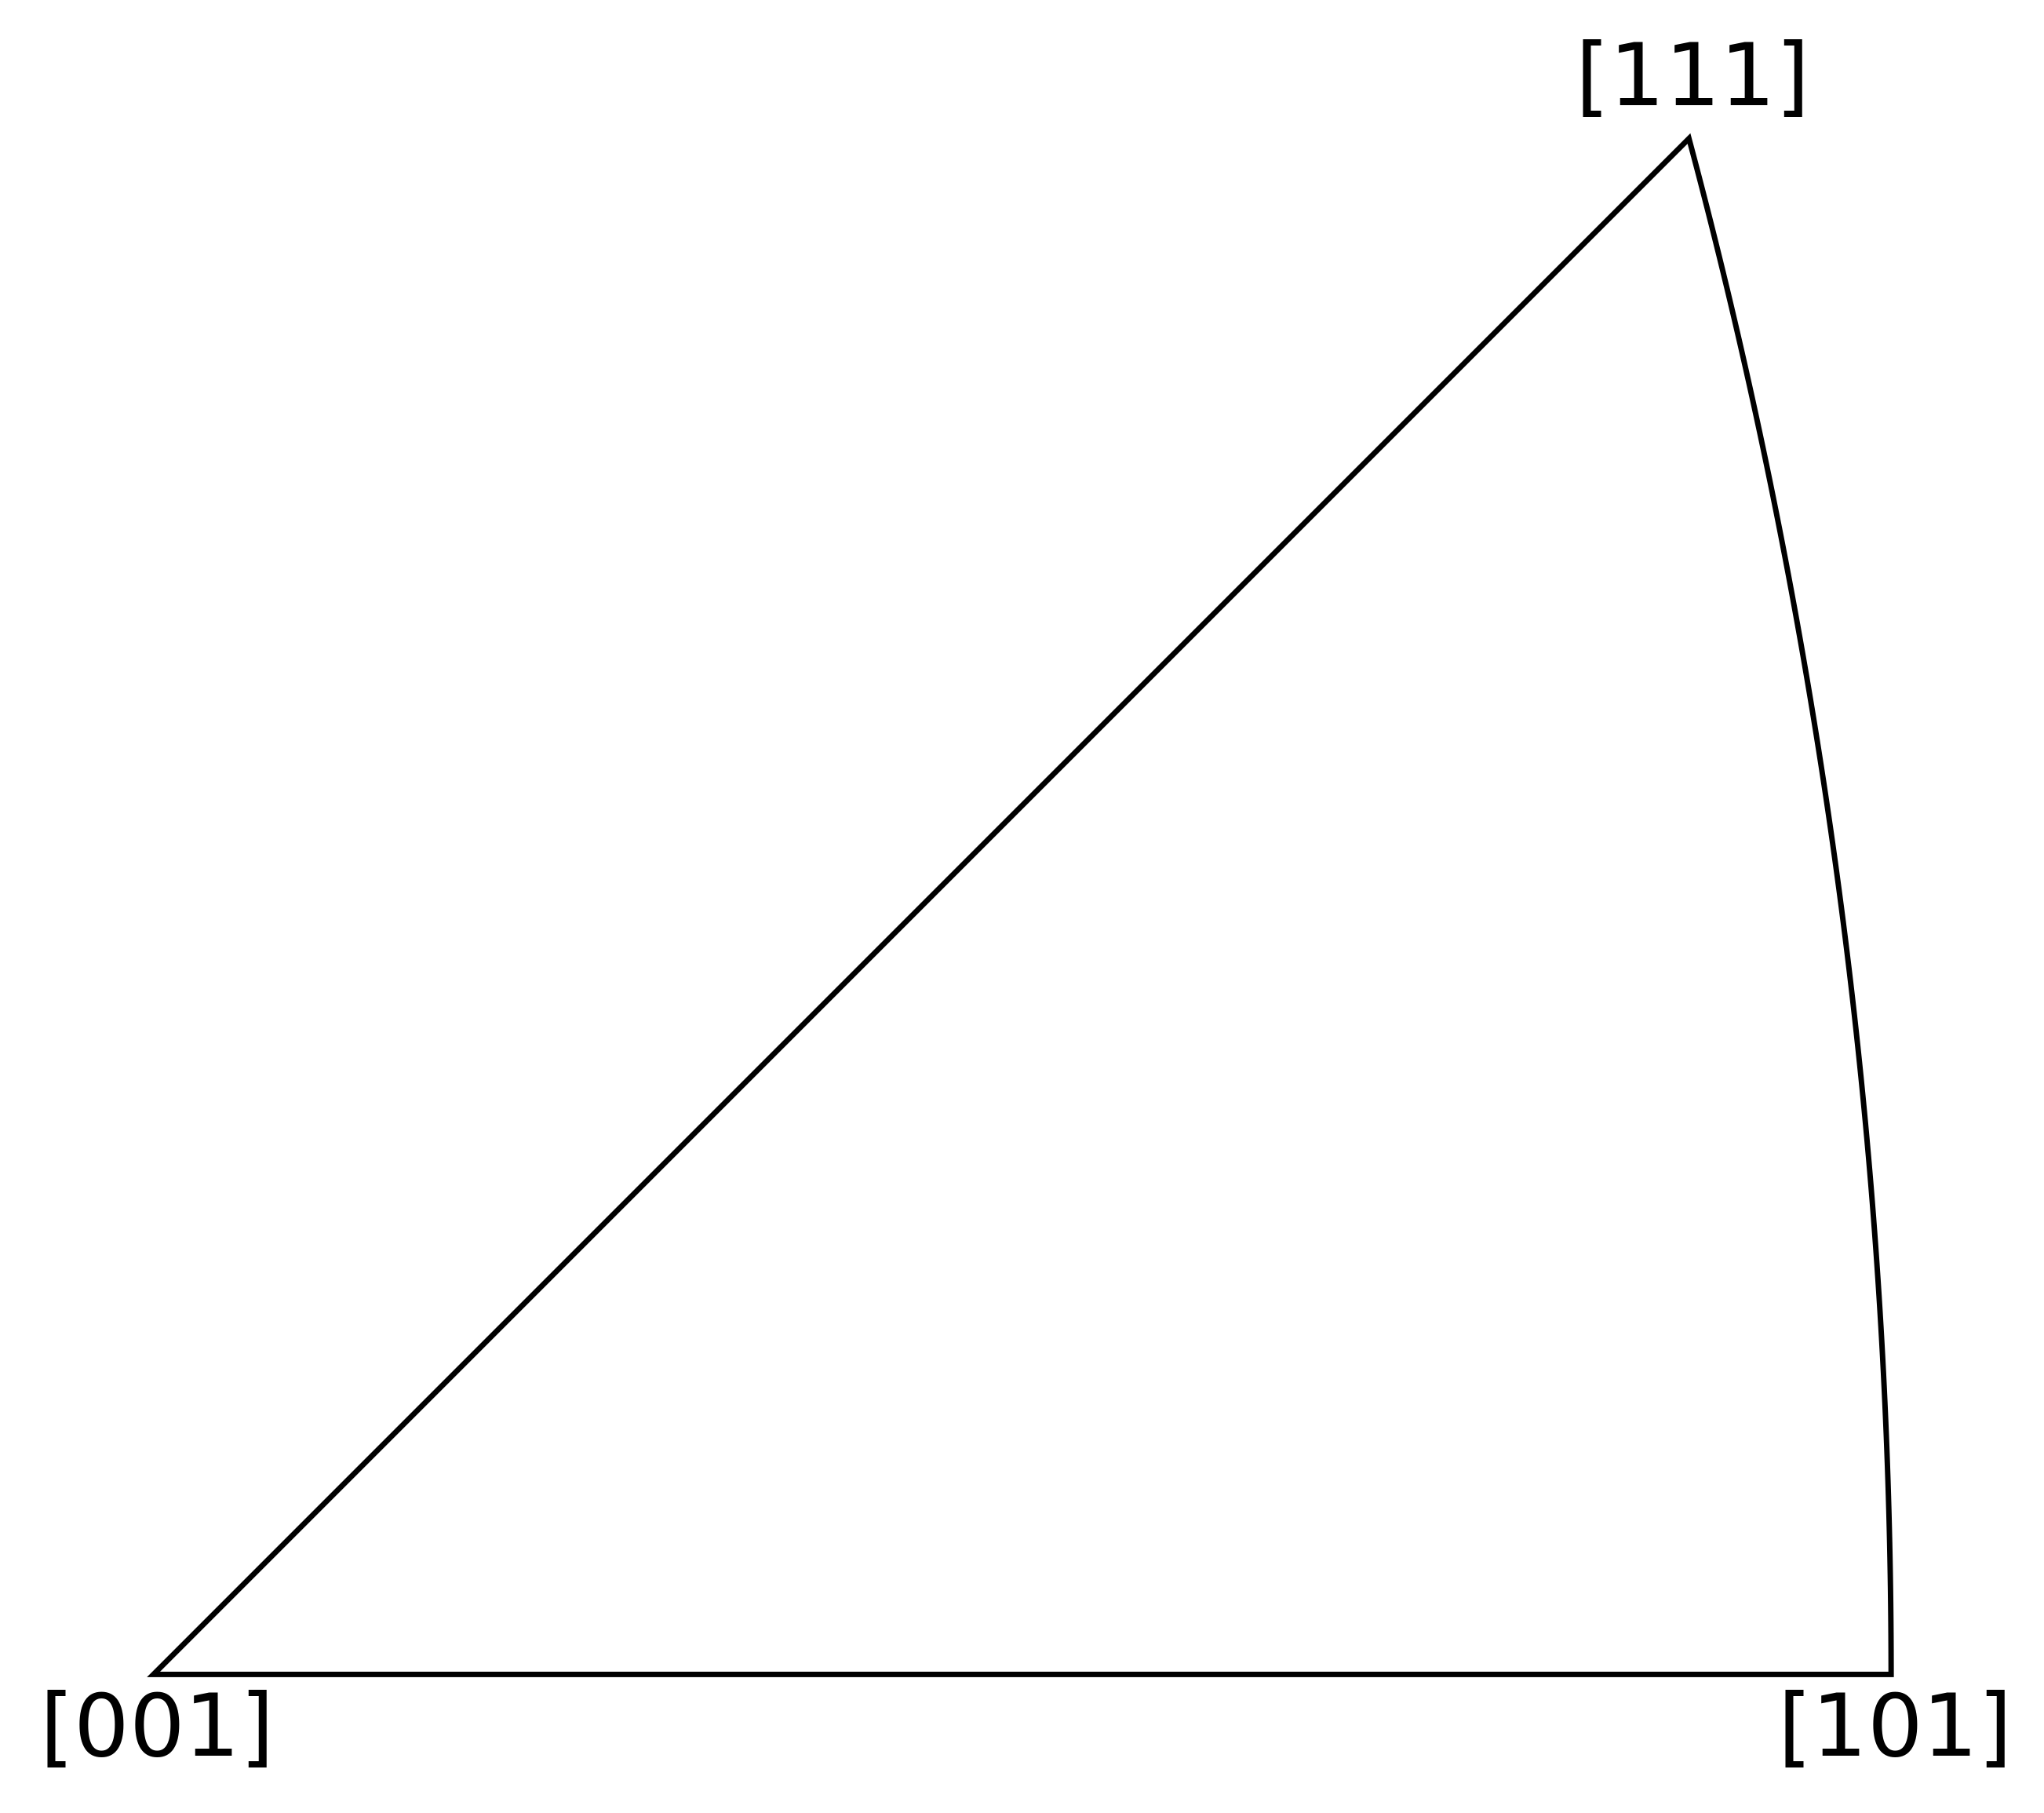

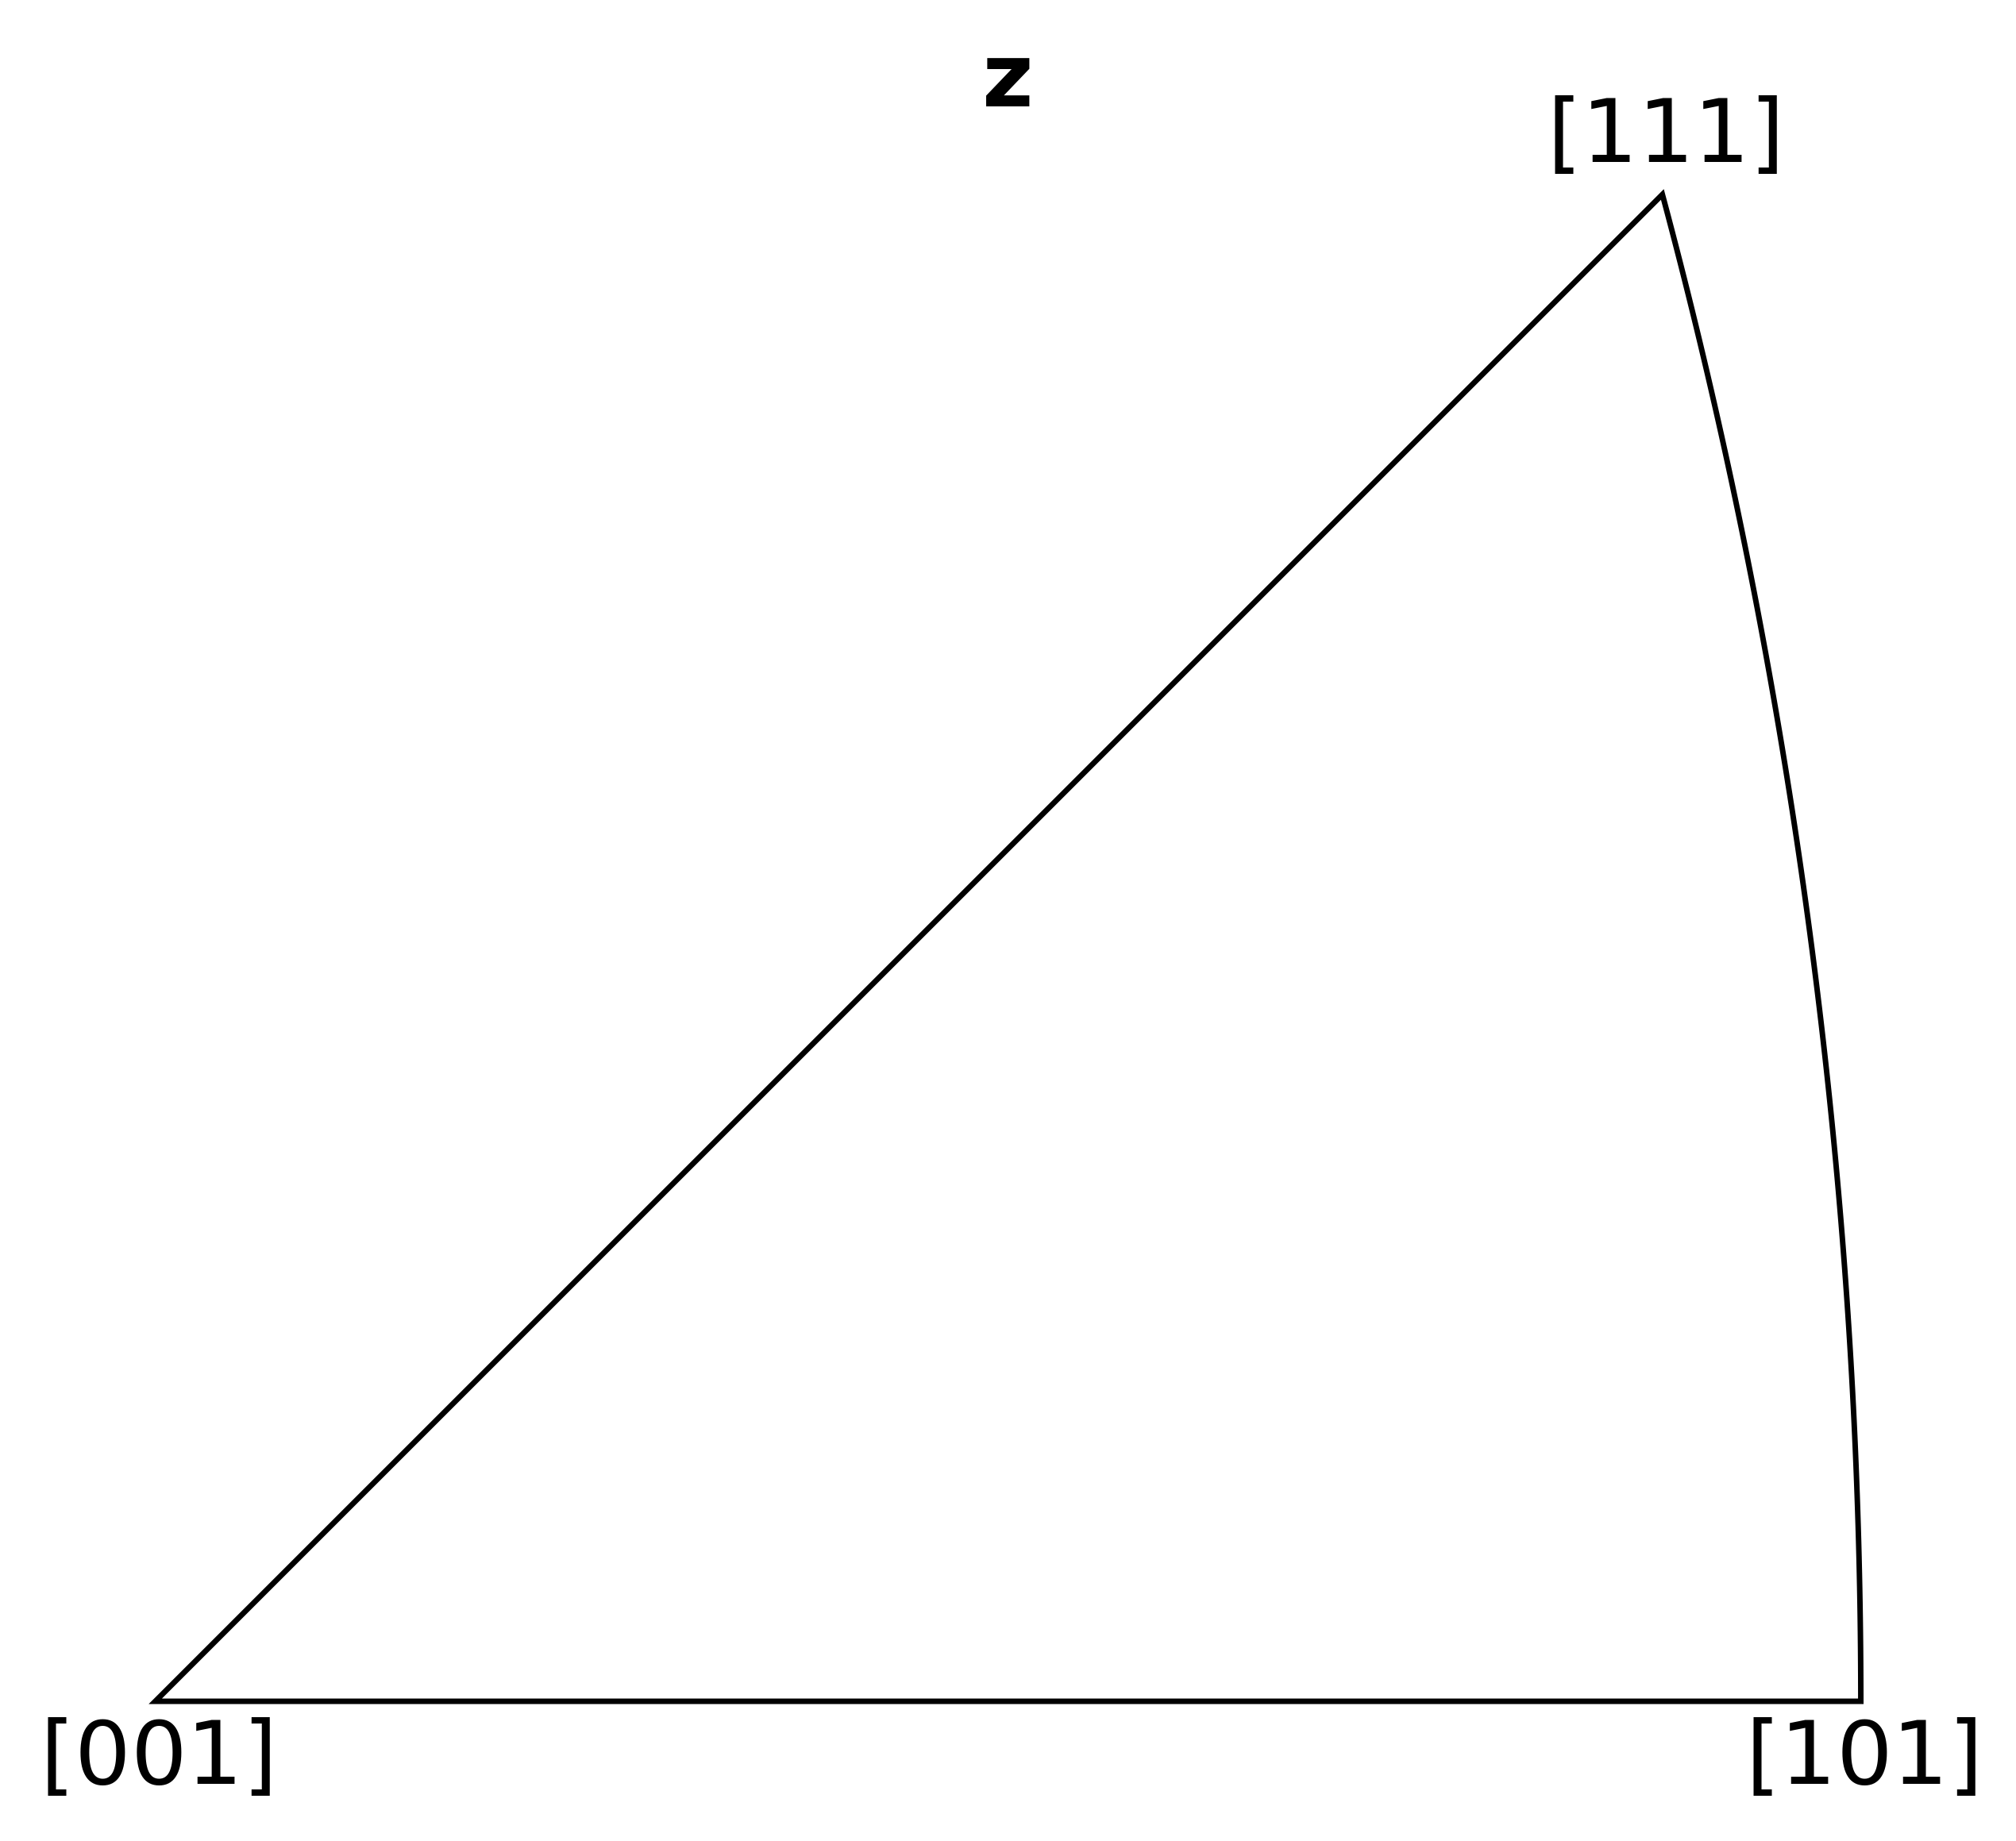

In [ ]:
# For the worst FZ patch found earlier
plot_outside_fz_orientations(
    result["patch_original"],   # or q_spatial for full field
    train_ds.sym_class,
    tol_deg=0.5,
    ref_dir="Z",
    out_png="fz_patch_debug/idx_68_outside_fz_stereographic.png",
)


In [ ]:
from orix.quaternion import Orientation
from orix.plot import IPFColorKeyTSL
from orix.vector import Vector3d
import matplotlib.pyplot as plt
import numpy as np

def plot_outside_fz_orientations(
    q_spatial: np.ndarray,
    sym_class,
    tol_deg: float = 0.5,
    ref_dir: str = "Z",
    out_png: str = "outside_fz_orientations.png",
    n_sample: int = None,
):
    """
    Plot orientations that lie outside the fundamental zone on an IPF stereographic plot.

    Parameters
    ----------
    q_spatial : np.ndarray
        Quaternion array (*spatial, 4).
    sym_class : orix symmetry class
        Crystal symmetry used for FZ mapping.
    tol_deg : float, default=0.5
        Angular tolerance for FZ membership in degrees.
    ref_dir : {"X","Y","Z"}, default="Z"
        Reference direction for the IPF plot.
    out_png : str, default="outside_fz_orientations.png"
        Output file path.
    n_sample : int, optional
        Optional random subsample of orientations to plot for speed.
    """
    H, W, _ = q_spatial.shape
    q_flat = q_spatial.reshape(-1, 4)

    if n_sample and n_sample < q_flat.shape[0]:
        idx = np.random.choice(q_flat.shape[0], n_sample, replace=False)
        q_flat = q_flat[idx]

    # Build orientation object
    ori = Orientation(q_flat, symmetry=sym_class)
    ori_fz = ori.map_into_symmetry_reduced_zone()

    # Misorientation to FZ
    mis = ori_fz.inv() * ori
    ang = np.degrees(mis.angle)
    outside_mask = ang > tol_deg

    print(f"[FZ Scatter] {outside_mask.mean()*100:.2f}% outside fundamental zone")

    # Set up IPF color key and plot
    ipfkey = IPFColorKeyTSL(sym_class.laue)
    ipfkey.direction = {"X": Vector3d.xvector(),
                        "Y": Vector3d.yvector(),
                        "Z": Vector3d.zvector()}[ref_dir.upper()]

    fig, ax = plt.subplots(
        subplot_kw={"projection": "ipf", "symmetry": sym_class.laue}, figsize=(6, 6)
    )

    # Plot all orientations lightly for reference
    ori.scatter(
        projection="ipf",
        ax=ax,
        size=5,
        alpha=0.15,
        color="gray",
        direction=ipfkey.direction,
    )

    # Plot outside-FZ orientations in red
    if np.any(outside_mask):
        ori[outside_mask].scatter(
            projection="ipf",
            ax=ax,
            size=5,
            alpha=0.9,
            color="red",
            direction=ipfkey.direction,
        )

    ax.set_title(f"Outside FZ ({outside_mask.mean()*100:.2f}%)")
    fig.savefig(out_png, bbox_inches="tight", dpi=300)
    plt.close(fig)

    return out_png


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # X, Y, Z IPF renders, but only ONE mask image
    tol_deg=0.5
)


[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ] Saved multi-panel IPF + blackout + mask + heatmap → fz_patch_debug


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.vector import Vector3d
from orix.plot import StereographicPlot
from orix.symmetry import Oh  # or your symmetry
from orix.plot.stereographic import plot_fundamental_sector

def plot_unfolded_ipf(
    q_spatial: np.ndarray,
    sym_class,
    ref_dir: str = "Z",
    n_sample: int = None,
    out_png: str = "unfolded_ipf.png",
):
    """
    Plot raw orientations on a stereographic projection (no FZ folding),
    overlaid with the fundamental zone boundaries.

    Parameters
    ----------
    q_spatial : np.ndarray
        Quaternion array (*spatial, 4).
    sym_class : orix symmetry class
        Crystal symmetry to draw FZ boundaries.
    ref_dir : {"X","Y","Z"}, default="Z"
        Reference sample direction to project.
    n_sample : int, optional
        Optional subsample size for plotting.
    out_png : str
        Output PNG path.
    """
    # Flatten quaternions
    q_flat = q_spatial.reshape(-1, 4)
    if n_sample and n_sample < q_flat.shape[0]:
        idx = np.random.choice(q_flat.shape[0], n_sample, replace=False)
        q_flat = q_flat[idx]

    # Build orientations
    ori = Orientation(q_flat, symmetry=sym_class)

    # Choose sample direction
    ref_map = {"X": Vector3d.xvector(), "Y": Vector3d.yvector(), "Z": Vector3d.zvector()}
    s_dir = ref_map[ref_dir.upper()]

    # Map to crystal directions WITHOUT folding
    crystal_dirs = ori.inv() * s_dir

    # Project onto stereographic projection
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="stereographic")

    # Plot all raw crystal directions as scatter
    ax.scatter(
        crystal_dirs.x,
        crystal_dirs.y,
        crystal_dirs.z,
        s=4,
        c="red",
        alpha=0.6,
    )

    # Plot FZ boundaries for the symmetry
    plot_fundamental_sector(ax, sym_class)

    ax.set_title(f"Unfolded IPF: {ref_dir}-direction ({sym_class.name})")
    fig.savefig(out_png, bbox_inches="tight", dpi=300)
    plt.close(fig)
    return out_png


ModuleNotFoundError: No module named 'orix.symmetry'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.path as mpath
from copy import deepcopy

from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

def plot_unfolded_ipf_with_symmetry_and_fz(
    arr_hw4,
    sym_class="Oh",
    ref_dir="Z",
    max_points=5000,
    highlight_outside_fz=True,
    tol_deg=0.5,
    out_png="unfolded_ipf_fz.png",
):
    """
    Plot unfolded IPF directions with symmetry axes and FZ boundary for cubic (or any) symmetry.

    Parameters
    ----------
    arr_hw4 : ndarray
        Quaternion array, (H,W,4) or (4,H,W), scalar-last or first.
    sym_class : str or orix symmetry, default="Oh"
        Symmetry class to use.
    ref_dir : str, default="Z"
        Crystal direction to project.
    max_points : int, default=5000
        Max orientations to plot.
    highlight_outside_fz : bool, default=True
        Whether to highlight orientations lying outside FZ.
    tol_deg : float, default=0.5
        Misorientation tolerance (deg) for outside FZ classification.
    out_png : str
        Path to save PNG figure.
    """
    # --- Handle input array ---
    if arr_hw4.ndim == 3 and arr_hw4.shape[0] == 4:
        arr_hw4 = np.moveaxis(arr_hw4, 0, -1)
    q_flat = arr_hw4.reshape(-1, 4)
    # Normalize
    q_flat /= np.linalg.norm(q_flat, axis=1, keepdims=True)
    flip = q_flat[:, 0] < 0
    q_flat[flip] *= -1

    if max_points and q_flat.shape[0] > max_points:
        idx = np.random.choice(q_flat.shape[0], max_points, replace=False)
        q_flat = q_flat[idx]

    # --- ORIX orientation ---
    sym = getattr(symmetry, sym_class) if isinstance(sym_class, str) else sym_class
    ori = Orientation(q_flat, symmetry=sym)
    ori_fz = ori.map_into_symmetry_reduced_zone()

    # --- Ref direction ---
    ref_map = {"X": Vector3d.xvector(), "Y": Vector3d.yvector(), "Z": Vector3d.zvector()}
    v_ref = ref_map[ref_dir.upper()]

    v_unfolded = ori * v_ref
    v_reduced = ori_fz * v_ref

    # Determine which points lie outside FZ
    outside_mask = None
    if highlight_outside_fz:
        mis = ori_fz.inv() * ori
        ang = np.rad2deg(mis.angle)
        outside_mask = ang > tol_deg
        frac_outside = outside_mask.mean() * 100
    else:
        frac_outside = 0.0

    # --- Plot ---
    fig, ax = plt.subplots(subplot_kw={"projection": "stereographic"}, figsize=(6, 6))
    ax.set_title(
        f"{sym.name} Unfolded IPF ({ref_dir}) — Outside FZ: {frac_outside:.2f}%",
        pad=20,
    )

    # Plot points
    if highlight_outside_fz and outside_mask is not None:
        ax.scatter(v_unfolded[~outside_mask], c="black", s=5, alpha=0.5, label="Inside FZ")
        if np.any(outside_mask):
            ax.scatter(v_unfolded[outside_mask], c="red", s=5, alpha=0.7, label="Outside FZ")
    else:
        ax.scatter(v_unfolded, c="black", s=5, alpha=0.5)

    # Draw symmetry axes (432 example)
    marker_size = 200
    v4fold = Vector3d([[0, 0, 1], [1, 0, 0], [-1, 0, 0], [0, 1, 0], [0, -1, 0]])
    ax.symmetry_marker(v4fold, fold=4, c="C4", s=marker_size)
    ax.draw_circle(v4fold, color="C4")

    v3fold = Vector3d([[1, 1, 1], [1, -1, 1], [-1, -1, 1], [-1, 1, 1]])
    ax.symmetry_marker(v3fold, fold=3, c="C3", s=marker_size)
    ax.draw_circle(v3fold, color="C3")

    v2fold = Vector3d(
        [
            [ 1,  0, 1],
            [ 0,  1, 1],
            [-1,  0, 1],
            [ 0, -1, 1],
            [ 1,  1, 0],
            [-1, -1, 0],
            [-1,  1, 0],
            [ 1, -1, 0],
        ]
    )
    ax.symmetry_marker(v2fold, fold=2, c="C2", s=marker_size)
    ax.draw_circle(v2fold, color="C2")

    # Draw FZ boundary manually
    sector = sym.fundamental_sector
    original_pole = deepcopy(sector._pole)
    sector._pole = ax.pole
    edges = sector.edges
    sector._pole = original_pole
    x, y, _ = ax._pretransform_input((edges,))
    patch = mpatches.PathPatch(
        mpath.Path(np.column_stack([x, y]), closed=True),
        facecolor="none",
        edgecolor="black",
        linewidth=1.5,
        alpha=0.9,
        zorder=5,
    )
    ax.add_patch(patch)

    ax.set_labels("RD", "TD", None)
    ax.show_hemisphere_label()
    ax.legend(loc="upper right", fontsize=10)

    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return out_png


In [ ]:
# Load quaternions
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

# Plot
plot_unfolded_ipf_with_symmetry_and_fz(
    q_spatial,
    sym_class=train_ds.sym_class,
    ref_dir="Z",
    highlight_outside_fz=True,
    tol_deg=0.5,
    out_png="unfolded_ipf_idx_68.png"
)


'unfolded_ipf_idx_68.png'

In [ ]:
# Load quaternions
_, q_spatial = train_ds.get_numpy_spatial_quat(179)

# Plot
plot_unfolded_ipf_with_symmetry_and_fz(
    q_spatial,
    sym_class=train_ds.sym_class,
    ref_dir="Z",
    highlight_outside_fz=True,
    tol_deg=0.5,
    out_png="unfolded_ipf_idx_68.png"
)


'unfolded_ipf_idx_68.png'

In [ ]:
# Load quaternions
_, q_spatial = train_ds.get_numpy_spatial_quat(179)

# Plot
plot_unfolded_ipf_with_symmetry_and_fz(
    q_spatial,
    sym_class=train_ds.sym_class,
    ref_dir="Z",
    highlight_outside_fz=True,
    tol_deg=0.1,
    out_png="unfolded_ipf_idx_68.png"
)


'unfolded_ipf_idx_68.png'

In [ ]:
# Load quaternions
_, q_spatial = train_ds.get_numpy_spatial_quat(179)

# Plot
plot_unfolded_ipf_with_symmetry_and_fz(
    q_spatial,
    sym_class=train_ds.sym_class,
    ref_dir="Z",
    highlight_outside_fz=True,
    tol_deg=0,
    out_png="unfolded_ipf_idx_68.png"
)


'unfolded_ipf_idx_68.png'

In [ ]:
# Load quaternions
_, q_spatial = train_ds.get_numpy_spatial_quat(179)

# Plot
plot_unfolded_ipf_with_symmetry_and_fz(
    q_spatial,
    sym_class=train_ds.sym_class,
    ref_dir="Z",
    highlight_outside_fz=True,
    tol_deg=-1,
    out_png="unfolded_ipf_idx_68.png"
)


'unfolded_ipf_idx_68.png'

In [ ]:
# Load quaternions
_, q_spatial = train_ds.get_numpy_spatial_quat(179)

# Plot
plot_unfolded_ipf_with_symmetry_and_fz(
    q_spatial,
    sym_class=train_ds.sym_class,
    ref_dir="Z",
    highlight_outside_fz=True,
    tol_deg=1e-6,
    out_png="unfolded_ipf_idx_68.png"
)


'unfolded_ipf_idx_68.png'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.vector import Vector3d
from orix import plot as orix_plot

def plot_outside_fz_ipf_map(
    arr_hw4,
    sym,
    ref_dir="Z",
    tol_deg=0.5,
    out_png="outside_fz_ipf_map.png",
    mask_alpha=0.5,
):
    """
    Visualize orientations and highlight pixels lying outside the FZ on IPF map.

    Parameters
    ----------
    arr_hw4 : ndarray
        Quaternion array, shape (H,W,4) or (4,H,W).
    sym : orix.symmetry
        Symmetry class (e.g., symmetry.Oh).
    ref_dir : {"X","Y","Z"}, default="Z"
        IPF reference direction.
    tol_deg : float, default=0.5
        Misorientation tolerance.
    out_png : str
        Output image filename.
    mask_alpha : float
        Transparency for the red overlay.
    """

    # --- Standardize quaternion format ---
    if arr_hw4.ndim == 3 and arr_hw4.shape[0] == 4:
        arr_hw4 = np.moveaxis(arr_hw4, 0, -1)
    h, w, _ = arr_hw4.shape
    q_flat = arr_hw4.reshape(-1, 4)
    q_flat /= np.linalg.norm(q_flat, axis=1, keepdims=True)
    flip = q_flat[:, 0] < 0
    q_flat[flip] *= -1

    ori = Orientation(q_flat, symmetry=sym)
    ori_fz = ori.map_into_symmetry_reduced_zone()

    # --- Outside FZ mask ---
    mis = ori_fz.inv() * ori
    ang = np.rad2deg(mis.angle)
    outside_mask = (ang > tol_deg).reshape(h, w)
    frac_outside = outside_mask.mean() * 100

    # --- IPF color map ---
    ref_map = {"X": Vector3d.xvector(), "Y": Vector3d.yvector(), "Z": Vector3d.zvector()}
    ipfkey = orix_plot.IPFColorKeyTSL(sym.laue)
    ipfkey.direction = ref_map[ref_dir.upper()]

    rgb_all = ipfkey.orientation2color(ori).reshape(h, w, 3)

    # --- Overlay mask ---
    overlay = rgb_all.copy()
    overlay[outside_mask] = (
        overlay[outside_mask] * (1 - mask_alpha)
        + np.array([1.0, 0.0, 0.0]) * mask_alpha
    )

    only_outside = np.zeros_like(rgb_all)
    only_outside[outside_mask] = [1.0, 0.0, 0.0]

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(rgb_all)
    axes[0].set_title("Original IPF Map")
    axes[1].imshow(overlay)
    axes[1].set_title(f"Outside FZ highlighted ({frac_outside:.2f}%)")
    axes[2].imshow(only_outside)
    axes[2].set_title("Outside FZ Mask (red)")
    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return out_png


In [ ]:
# Get quaternion array for some index
_, q_spatial = train_ds.get_numpy_spatial_quat(68)

plot_outside_fz_ipf_map(
    q_spatial,
    sym=train_ds.sym_class,
    ref_dir="Z",
    tol_deg=0.5,
    out_png="outside_fz_ipf_idx_68.png"
)


'outside_fz_ipf_idx_68.png'

In [ ]:
# Get quaternion array for some index
_, q_spatial = train_ds.get_numpy_spatial_quat(179)

plot_outside_fz_ipf_map(
    q_spatial,
    sym=train_ds.sym_class,
    ref_dir="Z",
    tol_deg=0.5,
    out_png="outside_fz_ipf_idx_68.png"
)


'outside_fz_ipf_idx_68.png'

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.vector import Vector3d
import orix.plot as orix_plot

def save_dataset_outside_fz_ipf_summary(
    dataset,
    out_png: str,
    which: str = "HR",
    ref_dir: str = "Z",
    n_total: int = 100_000,
    per_file_max: int = 2000,
    tol_deg: float = 0.5,
    include_key: bool = True,
    overwrite: bool = True,
    figsize: tuple = (7, 6),
):
    """
    Render and save an IPF summary figure that shows only orientations lying
    *outside the fundamental zone* for a given dataset split.

    Parameters
    ----------
    dataset : QuaternionDataset
        Loaded dataset instance (e.g., train_ds, val_ds, test_ds).
    out_png : str
        Output PNG path for the saved IPF summary.
    which : {"HR", "LR"}, default="HR"
        Whether to visualize high-resolution (HR) or low-resolution (LR) data.
    ref_dir : {"X", "Y", "Z"}, default="Z"
        Reference direction for IPF coloring.
    n_total : int, default=100_000
        Approximate total number of orientations to plot across all files.
    per_file_max : int, default=2000
        Maximum number of orientations to sample from each file.
    tol_deg : float, default=0.5
        Misorientation angle tolerance (degrees) to determine outside-FZ.
    include_key : bool, default=True
        Whether to include the IPF color key.
    overwrite : bool, default=True
        If False, skip rendering if the output file already exists.
    figsize : tuple, default=(7, 6)
        Figure size.
    """

    if not overwrite and os.path.exists(out_png):
        print(f"[IPF Outside-FZ] Skipping existing file: {out_png}")
        return out_png

    sym_class = dataset.sym_class
    ref_dir = ref_dir.upper()
    if ref_dir not in ("X", "Y", "Z"):
        raise ValueError("ref_dir must be 'X', 'Y', or 'Z'")

    # Initialize figure
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="ipf", symmetry=sym_class.laue)
    ax.set_aspect("equal", adjustable="box")

    title = f"{dataset.info['dataset']} {which.upper()} Outside-FZ IPF-{ref_dir}"
    ax.set_title(title, pad=14)

    ipfkey = orix_plot.IPFColorKeyTSL(sym_class.laue)
    ipfkey.direction = Vector3d(
        {"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref_dir]
    )

    n_files = len(dataset.pairs)
    per_file = min(max(1, n_total // n_files), per_file_max)
    print(f"[IPF Outside-FZ] Sampling ~{per_file} orientations per file across {n_files} files...")

    total_plotted = 0
    for i in range(n_files):
        try:
            # Load quaternions
            lr_np, hr_np = dataset.get_numpy_spatial_quat(i)
            q = hr_np if which.upper() == "HR" else lr_np
            q_flat = q.reshape(-1, 4)

            total = q_flat.shape[0]
            if total > per_file:
                q_flat = q_flat[np.random.choice(total, per_file, replace=False)]

            # Compute outside FZ mask
            O = Orientation(q_flat, symmetry=sym_class)
            O_fz = O.map_into_symmetry_reduced_zone()
            mis = O_fz.inv() * O
            ang = np.rad2deg(mis.angle)
            outside_mask = ang > tol_deg

            if np.any(outside_mask):
                O_outside = O[outside_mask]
                rgb = ipfkey.orientation2color(O_outside)
                O_outside.scatter(
                    projection="ipf",
                    c=rgb,
                    s=3,
                    alpha=0.8,
                    direction=ipfkey.direction,
                    figure=fig,
                )
                total_plotted += outside_mask.sum()

        except Exception as e:
            print(f"[IPF Outside-FZ] Skipping index {i}: {e}")

    print(f"[IPF Outside-FZ] Done. Total OUTSIDE-FZ orientations plotted: {total_plotted}")

    if include_key:
        ax_ipf = fig.add_subplot(111, projection="ipf", symmetry=sym_class.laue)
        ax_ipf.plot_ipf_color_key()
        ax_ipf.set_title("")

    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    fig.tight_layout(pad=1.4)
    fig.savefig(out_png, bbox_inches="tight", dpi=500)
    plt.close(fig)

    print(f"[IPF Outside-FZ] Saved summary → {out_png}")
    return out_png
    

In [ ]:
save_dataset_outside_fz_ipf_summary(
    dataset=train_ds,
    out_png="train_outside_fz_ipf_Z.png",
    which="HR",
    ref_dir="Z",
    tol_deg=0.5,
    n_total=50000
)


[IPF Outside-FZ] Sampling ~39 orientations per file across 1273 files...
[IPF Outside-FZ] Done. Total OUTSIDE-FZ orientations plotted: 29
[IPF Outside-FZ] Saved summary → train_outside_fz_ipf_Z.png


'train_outside_fz_ipf_Z.png'

In [ ]:
save_dataset_outside_fz_ipf_summary(
    dataset=train_ds,
    out_png="train_outside_fz_ipf_Z.png",
    which="HR",
    ref_dir="Z",
    tol_deg=0.5,
    n_total=50000,include_key=False
)


[IPF Outside-FZ] Sampling ~39 orientations per file across 1273 files...
[IPF Outside-FZ] Done. Total OUTSIDE-FZ orientations plotted: 26
[IPF Outside-FZ] Saved summary → train_outside_fz_ipf_Z.png


'train_outside_fz_ipf_Z.png'

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.vector import Vector3d

def plot_outside_fz_ipf_for_index(
    dataset,
    index: int,
    out_png: str,
    ref_dir: str = "Z",
    tol_deg: float = 0.5,
    which: str = "HR",
    s: int = 6,
    alpha: float = 0.8,
    figsize: tuple = (7, 6),
    overwrite: bool = True,
):
    """
    Scatter plot of orientations lying outside the FZ for a *single file index*
    on an IPF triangle.

    Parameters
    ----------
    dataset : QuaternionDataset
        The dataset object (e.g. train_ds).
    index : int
        Index of the file/sample to plot.
    out_png : str
        Path to save output image.
    ref_dir : {"X","Y","Z"}, default="Z"
        Reference direction for IPF coloring.
    tol_deg : float, default=0.5
        Misorientation tolerance for detecting outside-FZ orientations.
    which : {"HR","LR"}, default="HR"
        Which resolution data to use.
    s : int, default=6
        Scatter point size.
    alpha : float, default=0.8
        Scatter alpha transparency.
    figsize : tuple, default=(7,6)
        Figure size.
    overwrite : bool, default=True
        If False, skip if file exists.
    """

    if not overwrite and os.path.exists(out_png):
        print(f"[IPF Outside-FZ] Skipping existing file: {out_png}")
        return out_png

    sym_class = dataset.sym_class
    ref_dir = ref_dir.upper()
    if ref_dir not in ("X", "Y", "Z"):
        raise ValueError("ref_dir must be 'X', 'Y', or 'Z'")

    ipf_dir = Vector3d({"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref_dir])

    # Load quaternions
    lr_np, hr_np = dataset.get_numpy_spatial_quat(index)
    q = hr_np if which.upper() == "HR" else lr_np
    q_flat = q.reshape(-1, 4)

    # Compute misorientation between original and reduced orientation
    O = Orientation(q_flat, symmetry=sym_class)
    O_fz = O.map_into_symmetry_reduced_zone()
    mis = O_fz.inv() * O
    ang = np.rad2deg(mis.angle)
    outside_mask = ang > tol_deg

    n_out = np.count_nonzero(outside_mask)
    frac_out = 100 * (n_out / len(q_flat))

    # Make plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="ipf", symmetry=sym_class.laue)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"Outside-FZ Scatter (idx={index}, {frac_out:.2f}%) IPF-{ref_dir}", pad=14)

    if n_out > 0:
        O_outside = O[outside_mask]
        O_outside.scatter(
            projection="ipf",
            c="red",
            s=s,
            alpha=alpha,
            direction=ipf_dir,
            figure=fig,
        )
    else:
        print(f"[IPF Outside-FZ] No points outside FZ for index {index}")

    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    fig.tight_layout(pad=1.4)
    fig.savefig(out_png, bbox_inches="tight", dpi=500)
    plt.close(fig)

    print(f"[IPF Outside-FZ] Saved scatter plot for index {index} ({n_out} points, {frac_out:.2f}%) → {out_png}")
    return out_png


In [ ]:
plot_outside_fz_ipf_for_index(
    train_ds,
    index=68,
    out_png="outside_fz_index_68.png",
    ref_dir="Z",
    tol_deg=0.5,
    s=5,
    alpha=0.8
)


[IPF Outside-FZ] Saved scatter plot for index 68 (185 points, 1.13%) → outside_fz_index_68.png


'outside_fz_index_68.png'

In [ ]:
sym_class = dataset.sym_class
ref_dir = ref_dir.upper()
if ref_dir not in ("X", "Y", "Z"):
    raise ValueError("ref_dir must be 'X', 'Y', or 'Z'")

ipf_dir = Vector3d({"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref_dir])

# Load quaternions
lr_np, hr_np = dataset.get_numpy_spatial_quat(index)
q = hr_np if which.upper() == "HR" else lr_np
q_flat = q.reshape(-1, 4)

# Compute misorientation between original and reduced orientation
O = Orientation(q_flat, symmetry=sym_class)
O_fz = O.map_into_symmetry_reduced_zone()
mis = O_fz.inv() * O
ang = np.rad2deg(mis.angle)
outside_mask = ang > tol_deg

n_out = np.count_nonzero(outside_mask)
frac_out = 100 * (n_out / len(q_flat))


NameError: name 'dataset' is not defined

In [ ]:
dataset = train_ds
sym_class = dataset.sym_class
ref_dir = ref_dir.upper()
if ref_dir not in ("X", "Y", "Z"):
    raise ValueError("ref_dir must be 'X', 'Y', or 'Z'")

ipf_dir = Vector3d({"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref_dir])

# Load quaternions
lr_np, hr_np = dataset.get_numpy_spatial_quat(index)
q = hr_np if which.upper() == "HR" else lr_np
q_flat = q.reshape(-1, 4)

# Compute misorientation between original and reduced orientation
O = Orientation(q_flat, symmetry=sym_class)
O_fz = O.map_into_symmetry_reduced_zone()
mis = O_fz.inv() * O
ang = np.rad2deg(mis.angle)
outside_mask = ang > tol_deg

n_out = np.count_nonzero(outside_mask)
frac_out = 100 * (n_out / len(q_flat))


NameError: name 'ref_dir' is not defined

In [ ]:
dataset = train_ds
sym_class = dataset.sym_class
ref_dir = "Z"
ref_dir = ref_dir.upper()
if ref_dir not in ("X", "Y", "Z"):
    raise ValueError("ref_dir must be 'X', 'Y', or 'Z'")

ipf_dir = Vector3d({"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref_dir])

# Load quaternions
lr_np, hr_np = dataset.get_numpy_spatial_quat(index)
q = hr_np if which.upper() == "HR" else lr_np
q_flat = q.reshape(-1, 4)

# Compute misorientation between original and reduced orientation
O = Orientation(q_flat, symmetry=sym_class)
O_fz = O.map_into_symmetry_reduced_zone()
mis = O_fz.inv() * O
ang = np.rad2deg(mis.angle)
outside_mask = ang > tol_deg

n_out = np.count_nonzero(outside_mask)
frac_out = 100 * (n_out / len(q_flat))


NameError: name 'index' is not defined

In [ ]:
index = 68
dataset = train_ds
sym_class = dataset.sym_class
ref_dir = "Z"
ref_dir = ref_dir.upper()
if ref_dir not in ("X", "Y", "Z"):
    raise ValueError("ref_dir must be 'X', 'Y', or 'Z'")

ipf_dir = Vector3d({"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref_dir])

# Load quaternions
lr_np, hr_np = dataset.get_numpy_spatial_quat(index)
q = hr_np if which.upper() == "HR" else lr_np
q_flat = q.reshape(-1, 4)

# Compute misorientation between original and reduced orientation
O = Orientation(q_flat, symmetry=sym_class)
O_fz = O.map_into_symmetry_reduced_zone()
mis = O_fz.inv() * O
ang = np.rad2deg(mis.angle)
outside_mask = ang > tol_deg

n_out = np.count_nonzero(outside_mask)
frac_out = 100 * (n_out / len(q_flat))


NameError: name 'which' is not defined

In [ ]:
which = "HR"
index = 68
dataset = train_ds
sym_class = dataset.sym_class
ref_dir = "Z"
ref_dir = ref_dir.upper()
if ref_dir not in ("X", "Y", "Z"):
    raise ValueError("ref_dir must be 'X', 'Y', or 'Z'")

ipf_dir = Vector3d({"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref_dir])

# Load quaternions
lr_np, hr_np = dataset.get_numpy_spatial_quat(index)
q = hr_np if which.upper() == "HR" else lr_np
q_flat = q.reshape(-1, 4)

# Compute misorientation between original and reduced orientation
O = Orientation(q_flat, symmetry=sym_class)
O_fz = O.map_into_symmetry_reduced_zone()
mis = O_fz.inv() * O
ang = np.rad2deg(mis.angle)
outside_mask = ang > tol_deg

n_out = np.count_nonzero(outside_mask)
frac_out = 100 * (n_out / len(q_flat))


NameError: name 'tol_deg' is not defined

In [ ]:
which = "HR"
index = 68
dataset = train_ds
sym_class = dataset.sym_class
ref_dir = "Z"
tol_deg = 0
ref_dir = ref_dir.upper()
if ref_dir not in ("X", "Y", "Z"):
    raise ValueError("ref_dir must be 'X', 'Y', or 'Z'")

ipf_dir = Vector3d({"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref_dir])

# Load quaternions
lr_np, hr_np = dataset.get_numpy_spatial_quat(index)
q = hr_np if which.upper() == "HR" else lr_np
q_flat = q.reshape(-1, 4)

# Compute misorientation between original and reduced orientation
O = Orientation(q_flat, symmetry=sym_class)
O_fz = O.map_into_symmetry_reduced_zone()
mis = O_fz.inv() * O
ang = np.rad2deg(mis.angle)
outside_mask = ang > tol_deg

n_out = np.count_nonzero(outside_mask)
frac_out = 100 * (n_out / len(q_flat))


In [ ]:
frac_out

1.129150390625

In [ ]:
O = O_fz

In [ ]:
O_fz = O.map_into_symmetry_reduced_zone()
mis = O_fz.inv() * O
ang = np.rad2deg(mis.angle)
outside_mask = ang > tol_deg

n_out = np.count_nonzero(outside_mask)
frac_out = 100 * (n_out / len(q_flat))

In [ ]:
frac_out

0.0

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.vector import Vector3d
import orix.plot as orix_plot

def plot_outside_fz_ipf_for_index(
    dataset,
    index: int,
    out_png: str,
    ref_dir: str = "Z",
    tol_deg: float = 0.5,
    which: str = "HR",
    s: int = 6,
    alpha: float = 0.8,
    figsize: tuple = (7, 6),
    overwrite: bool = True,
):
    """
    Scatter plot of orientations lying outside the FZ for a *single file index*
    on an IPF triangle, colored by their IPF color.

    Parameters
    ----------
    dataset : QuaternionDataset
        The dataset object (e.g. train_ds).
    index : int
        Index of the file/sample to plot.
    out_png : str
        Path to save output image.
    ref_dir : {"X","Y","Z"}, default="Z"
        Reference direction for IPF coloring.
    tol_deg : float, default=0.5
        Misorientation tolerance for detecting outside-FZ orientations.
    which : {"HR","LR"}, default="HR"
        Which resolution data to use.
    s : int, default=6
        Scatter point size.
    alpha : float, default=0.8
        Scatter alpha transparency.
    figsize : tuple, default=(7,6)
        Figure size.
    overwrite : bool, default=True
        If False, skip if file exists.
    """

    if not overwrite and os.path.exists(out_png):
        print(f"[IPF Outside-FZ] Skipping existing file: {out_png}")
        return out_png

    sym_class = dataset.sym_class
    ref_dir = ref_dir.upper()
    if ref_dir not in ("X", "Y", "Z"):
        raise ValueError("ref_dir must be 'X', 'Y', or 'Z'")

    ipf_dir = Vector3d({"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref_dir])
    ipfkey = orix_plot.IPFColorKeyTSL(sym_class.laue)
    ipfkey.direction = ipf_dir

    # Load quaternions
    lr_np, hr_np = dataset.get_numpy_spatial_quat(index)
    q = hr_np if which.upper() == "HR" else lr_np
    q_flat = q.reshape(-1, 4)

    # Compute misorientation between original and reduced orientation
    O = Orientation(q_flat, symmetry=sym_class)
    O_fz = O.map_into_symmetry_reduced_zone()
    mis = O_fz.inv() * O
    ang = np.rad2deg(mis.angle)
    outside_mask = ang > tol_deg

    n_out = np.count_nonzero(outside_mask)
    frac_out = 100 * (n_out / len(q_flat))

    # Make plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="ipf", symmetry=sym_class.laue)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"Outside-FZ (idx={index}, {frac_out:.2f}%) IPF-{ref_dir}", pad=14)

    if n_out > 0:
        O_outside = O[outside_mask]
        colors = ipfkey.orientation2color(O_outside)
        O_outside.scatter(
            projection="ipf",
            c=colors,
            s=s,
            alpha=alpha,
            direction=ipf_dir,
            figure=fig,
        )
    else:
        print(f"[IPF Outside-FZ] No points outside FZ for index {index}")

    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    fig.tight_layout(pad=1.4)
    fig.savefig(out_png, bbox_inches="tight", dpi=500)
    plt.close(fig)

    print(f"[IPF Outside-FZ] Saved scatter plot for index {index} ({n_out} points, {frac_out:.2f}%) → {out_png}")
    return out_png


In [ ]:
plot_outside_fz_ipf_for_index(
    train_ds,
    index=68,
    out_png="outside_fz_index_68_ipfcolor.png",
    ref_dir="Z",
    tol_deg=0.5,
    s=5,
    alpha=0.8
)


[IPF Outside-FZ] Saved scatter plot for index 68 (185 points, 1.13%) → outside_fz_index_68_ipfcolor.png


'outside_fz_index_68_ipfcolor.png'

In [ ]:
plot_outside_fz_ipf_for_index(
    train_ds,
    index=68,
    out_png="outside_fz_index_68_ipfcolor.png",
    ref_dir="X",
    tol_deg=0.5,
    s=5,
    alpha=0.8
)


[IPF Outside-FZ] Saved scatter plot for index 68 (185 points, 1.13%) → outside_fz_index_68_ipfcolor.png


'outside_fz_index_68_ipfcolor.png'

In [ ]:
plot_outside_fz_ipf_for_index(
    train_ds,
    index=68,
    out_png="outside_fz_index_68_ipfcolor.png",
    ref_dir="Y",
    tol_deg=0.5,
    s=5,
    alpha=0.8
)


[IPF Outside-FZ] Saved scatter plot for index 68 (185 points, 1.13%) → outside_fz_index_68_ipfcolor.png


'outside_fz_index_68_ipfcolor.png'

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.vector import Vector3d
import orix.plot as orix_plot

def plot_outside_fz_ipf_for_index(
    dataset,
    index: int,
    out_png: str,
    ref_dir: str = "Z",
    tol_deg: float = 0.5,
    which: str = "HR",
    s: int = 6,
    alpha: float = 0.8,
    figsize: tuple = (7, 6),
    overwrite: bool = True,
    key_loc: str = "inset",  # 'inset' or 'side'
):
    """
    Scatter plot of orientations lying outside the FZ for a single file index
    on an IPF triangle, colored by their IPF color, with a small IPF color key.

    Parameters
    ----------
    dataset : QuaternionDataset
        Dataset object (e.g. train_ds).
    index : int
        Index of the file/sample to plot.
    out_png : str
        Path to save output image.
    ref_dir : {"X","Y","Z"}, default="Z"
        Reference direction for IPF coloring.
    tol_deg : float, default=0.5
        Misorientation tolerance for detecting outside-FZ orientations.
    which : {"HR","LR"}, default="HR"
        Which resolution data to use.
    s : int, default=6
        Scatter point size.
    alpha : float, default=0.8
        Scatter transparency.
    figsize : tuple, default=(7,6)
        Figure size.
    key_loc : {"inset","side"}, default="inset"
        Where to place the IPF color key.
    """

    if not overwrite and os.path.exists(out_png):
        print(f"[IPF Outside-FZ] Skipping existing file: {out_png}")
        return out_png

    sym_class = dataset.sym_class
    ref_dir = ref_dir.upper()
    if ref_dir not in ("X", "Y", "Z"):
        raise ValueError("ref_dir must be 'X', 'Y', or 'Z'")

    ipf_dir = Vector3d({"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref_dir])
    ipfkey = orix_plot.IPFColorKeyTSL(sym_class.laue)
    ipfkey.direction = ipf_dir

    # Load quaternions
    lr_np, hr_np = dataset.get_numpy_spatial_quat(index)
    q = hr_np if which.upper() == "HR" else lr_np
    q_flat = q.reshape(-1, 4)

    # Compute outside-FZ mask
    O = Orientation(q_flat, symmetry=sym_class)
    O_fz = O.map_into_symmetry_reduced_zone()
    mis = O_fz.inv() * O
    ang = np.rad2deg(mis.angle)
    outside_mask = ang > tol_deg

    n_out = np.count_nonzero(outside_mask)
    frac_out = 100 * (n_out / len(q_flat))

    # Main IPF plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="ipf", symmetry=sym_class.laue)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(
        f"Outside-FZ (idx={index}, {frac_out:.2f}%) IPF-{ref_dir}",
        pad=14
    )

    if n_out > 0:
        O_outside = O[outside_mask]
        colors = ipfkey.orientation2color(O_outside)
        O_outside.scatter(
            projection="ipf",
            c=colors,
            s=s,
            alpha=alpha,
            direction=ipf_dir,
            figure=fig,
        )
    else:
        print(f"[IPF Outside-FZ] No points outside FZ for index {index}")

    # --- Add IPF color key ---
    if key_loc == "inset":
        # Small inset axis for the IPF key
        inset_ax = fig.add_axes([0.72, 0.72, 0.22, 0.22], projection="ipf", symmetry=sym_class.laue)
        inset_ax.plot_ipf_color_key()
        inset_ax.set_title("")
    elif key_loc == "side":
        # Side-by-side larger key
        key_ax = fig.add_axes([0.82, 0.15, 0.15, 0.3], projection="ipf", symmetry=sym_class.laue)
        key_ax.plot_ipf_color_key()
        key_ax.set_title("")

    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    fig.tight_layout(pad=1.4)
    fig.savefig(out_png, bbox_inches="tight", dpi=500)
    plt.close(fig)

    print(
        f"[IPF Outside-FZ] Saved scatter plot for index {index} "
        f"({n_out} points, {frac_out:.2f}%) → {out_png}"
    )
    return out_png


In [ ]:
plot_outside_fz_ipf_for_index(
    train_ds,
    index=68,
    out_png="outside_fz_index_68_ipfcolor.png",
    ref_dir="Z",
    tol_deg=0.5,
    s=5,
    alpha=0.8,
    key_loc="inset",  # or "side"
)


<ipython-input-94-a462f550ca1c>:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=1.4)


[IPF Outside-FZ] Saved scatter plot for index 68 (185 points, 1.13%) → outside_fz_index_68_ipfcolor.png


'outside_fz_index_68_ipfcolor.png'

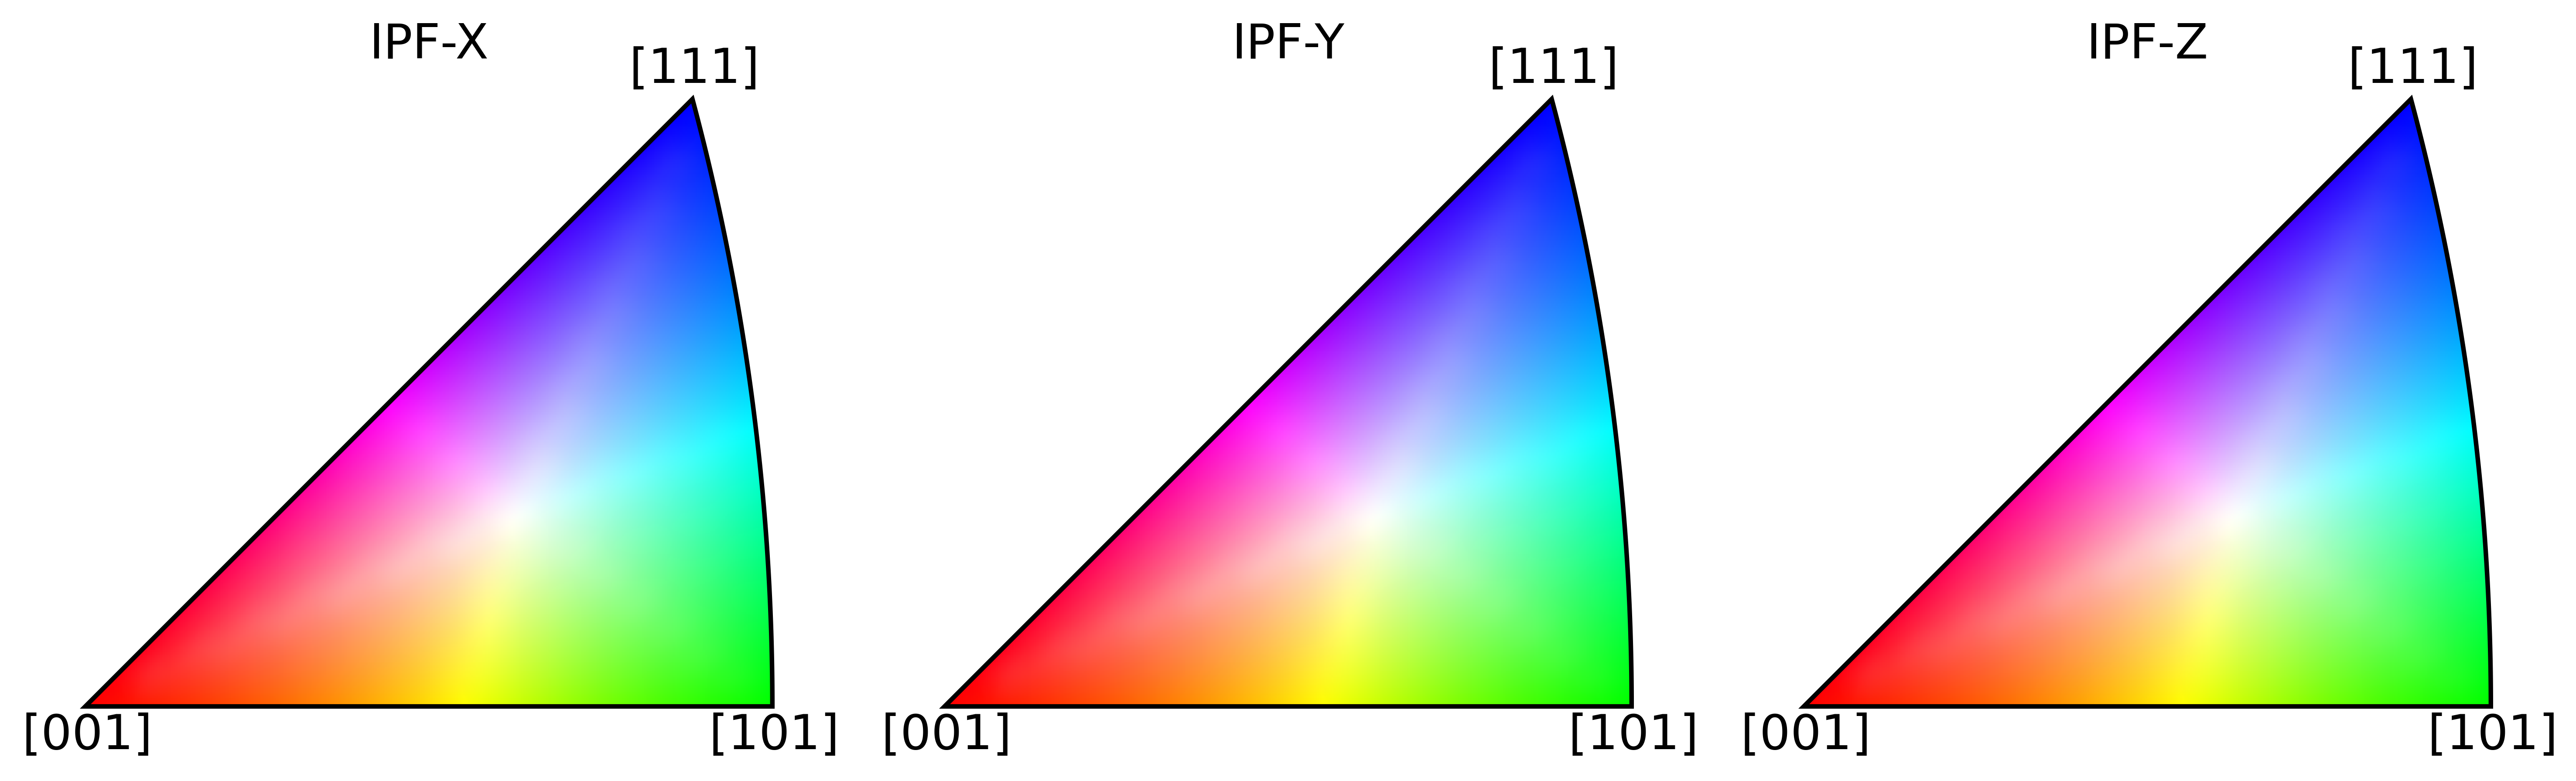

In [ ]:
from orix.vector import Vector3d
import orix.plot as orix_plot
import matplotlib.pyplot as plt

sym = train_ds.sym_class  # or e.g. symmetry.Oh

fig, axs = plt.subplots(1, 3, figsize=(12, 4), subplot_kw={"projection": "ipf", "symmetry": sym.laue})

for ax, ref, title in zip(axs, ["X", "Y", "Z"], ["IPF-X", "IPF-Y", "IPF-Z"]):
    key = orix_plot.IPFColorKeyTSL(sym.laue)
    key.direction = Vector3d({"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref])
    ax.plot_ipf_color_key()
    ax.set_title(title)

plt.tight_layout()
plt.show()


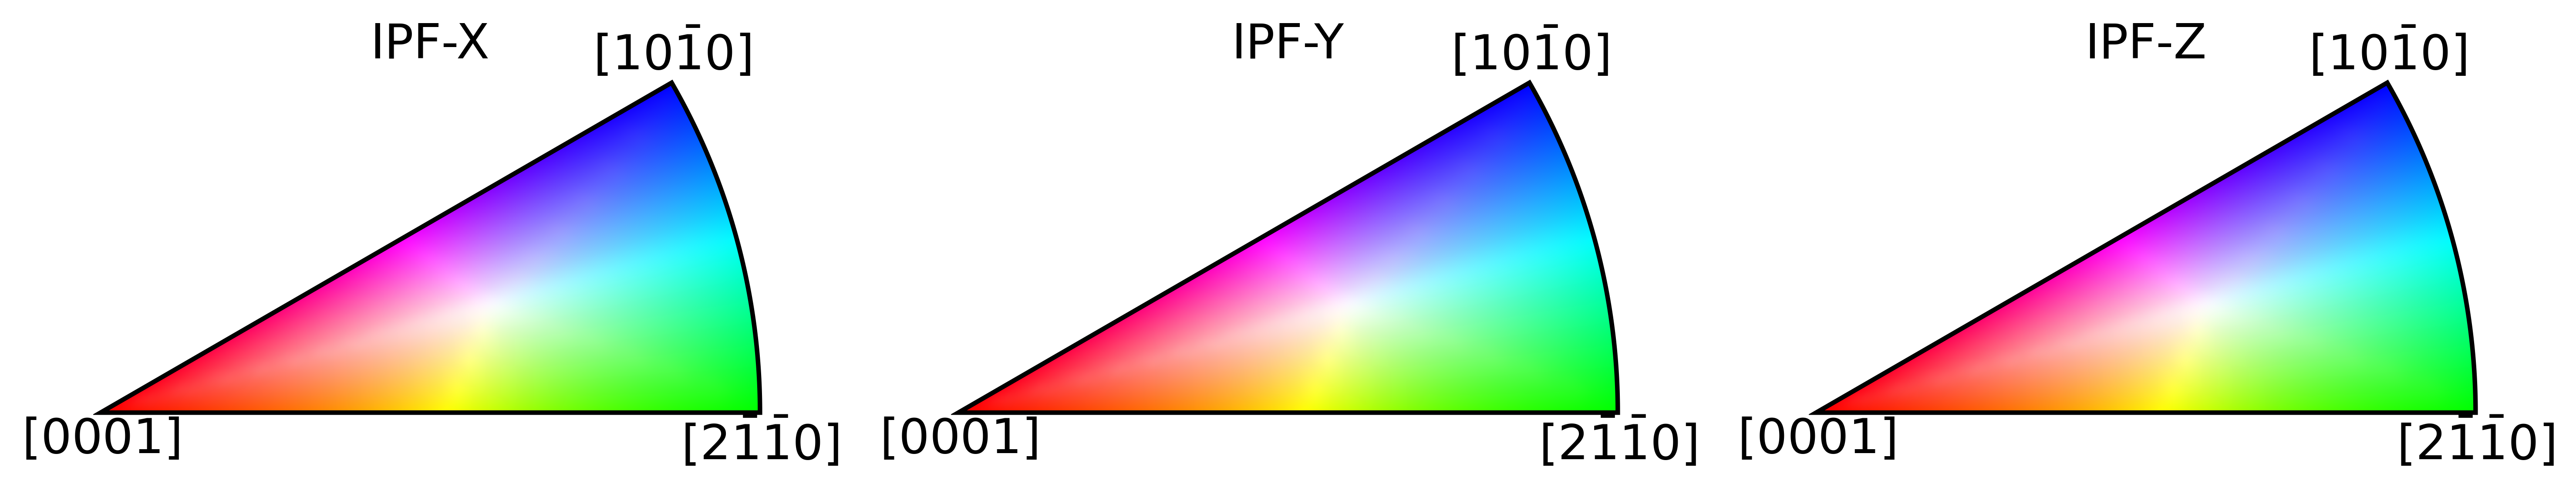

In [ ]:
from orix.quaternion import symmetry
from orix.vector import Vector3d
import orix.plot as orix_plot
import matplotlib.pyplot as plt

sym = symmetry.D6h  # hexagonal

fig, axs = plt.subplots(1, 3, figsize=(12, 4), subplot_kw={"projection": "ipf", "symmetry": sym.laue})
for ax, ref, title in zip(axs, ["X", "Y", "Z"], ["IPF-X", "IPF-Y", "IPF-Z"]):
    key = orix_plot.IPFColorKeyTSL(sym.laue)
    key.direction = Vector3d({"X": (1, 0, 0), "Y": (0, 1, 0), "Z": (0, 0, 1)}[ref])
    ax.plot_ipf_color_key()
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d
import orix.plot as orix_plot

def plot_orientations_on_ipf_xyz(q_spatial, sym_class, max_points=5000, figsize=(15, 5)):
    """
    Plot the same orientations on IPF-X, IPF-Y, and IPF-Z.
    """
    # --- Ensure correct shape and normalization ---
    if q_spatial.shape[0] == 4 and q_spatial.ndim == 3:
        q_spatial = np.moveaxis(q_spatial, 0, -1)
    q_spatial = q_spatial / np.linalg.norm(q_spatial, axis=-1, keepdims=True)
    flip = q_spatial[..., 0] < 0
    q_spatial[flip] *= -1
    q_flat = q_spatial.reshape(-1, 4)

    # --- Subsample for clarity ---
    if q_flat.shape[0] > max_points:
        idx = np.random.choice(q_flat.shape[0], max_points, replace=False)
        q_flat = q_flat[idx]

    # --- ORIX orientation object ---
    sym = sym_class
    O = Orientation(q_flat, symmetry=sym)

    # --- Reference directions ---
    ref_dirs = {
        "X": Vector3d.xvector(),
        "Y": Vector3d.yvector(),
        "Z": Vector3d.zvector(),
    }

    fig, axs = plt.subplots(1, 3, figsize=figsize, subplot_kw={"projection": "ipf", "symmetry": sym.laue})

    for ax, ref_name in zip(axs, ["X", "Y", "Z"]):
        ipf_key = orix_plot.IPFColorKeyTSL(sym.laue)
        ipf_key.direction = ref_dirs[ref_name]
        rgb = ipf_key.orientation2color(O)
        O.scatter(
            projection="ipf",
            direction=ipf_key.direction,
            c=rgb,
            s=3,
            alpha=0.7,
            figure=fig,
            ax=ax,
        )
        ax.set_title(f"IPF-{ref_name}")

    plt.tight_layout()
    plt.show()


TypeError: Axes.scatter() got multiple values for argument 'ax'

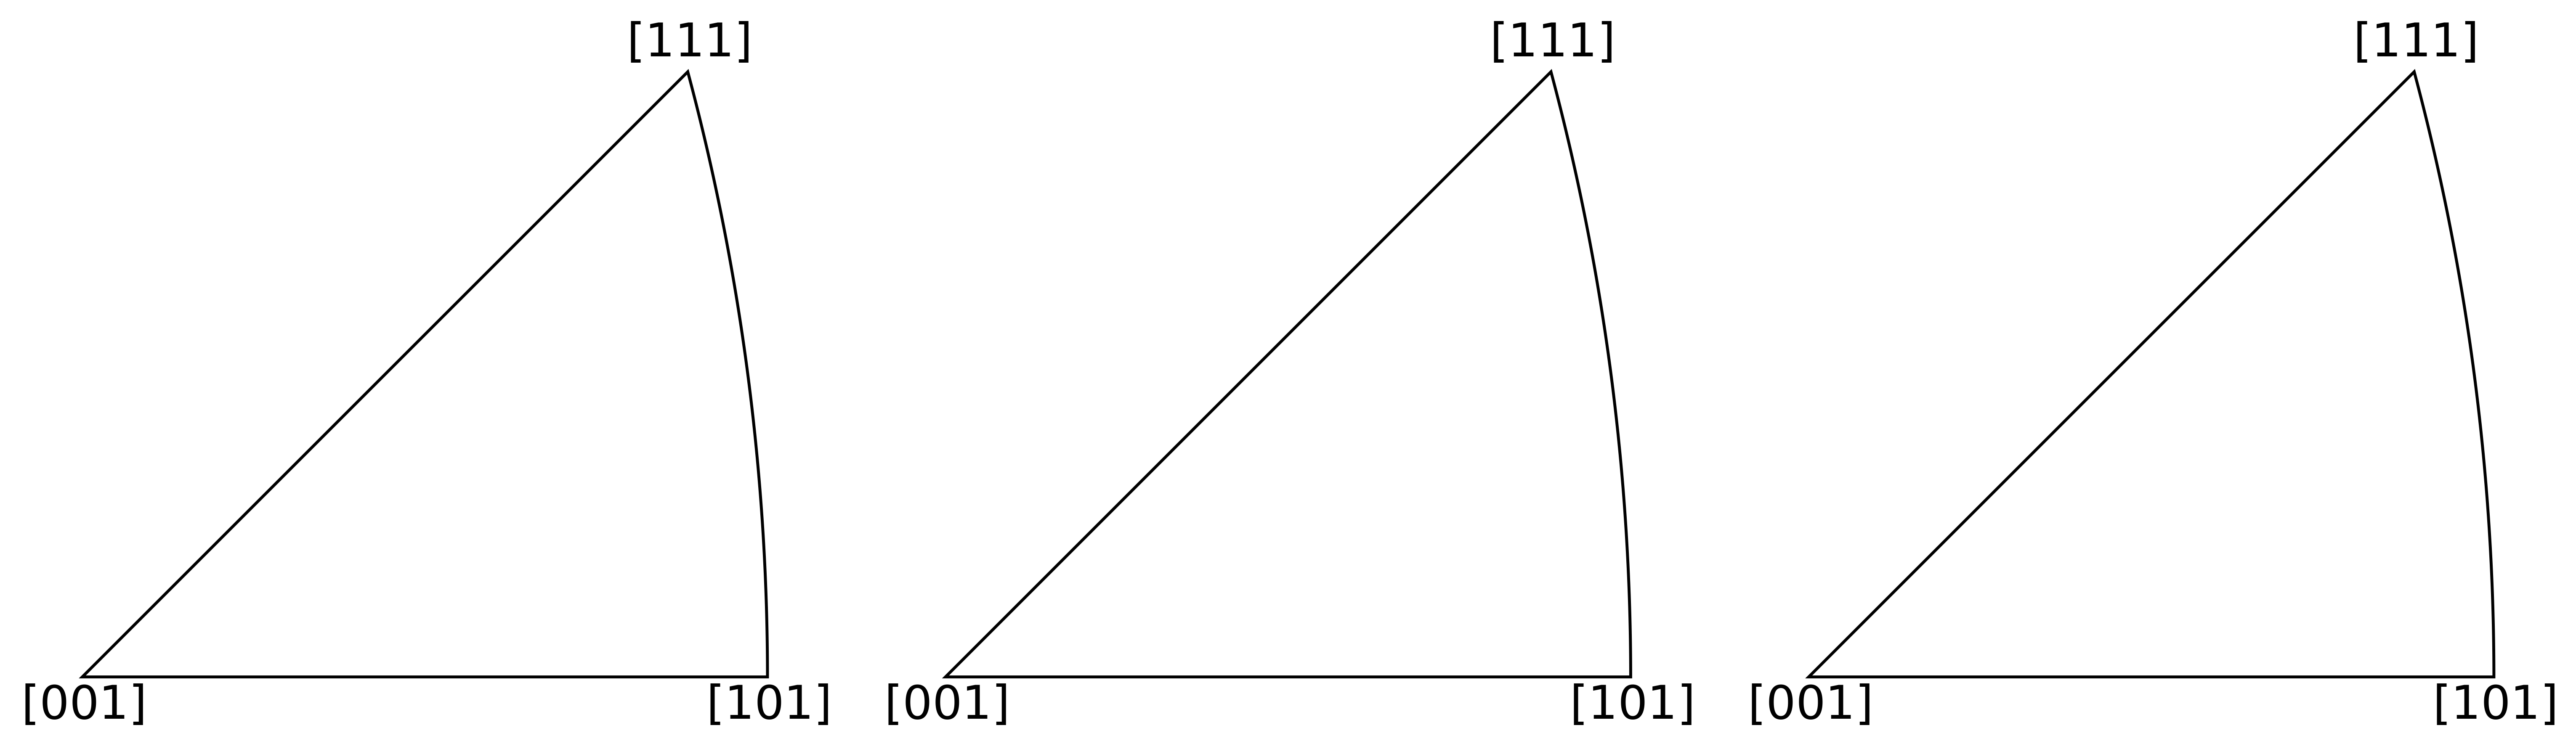

In [ ]:
# Example with your dataset index 68
_, q_spatial = train_ds.get_numpy_spatial_quat(68)
plot_orientations_on_ipf_xyz(q_spatial, train_ds.sym_class, max_points=8000)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.vector import Vector3d
import orix.plot as orix_plot

def plot_orientations_on_ipf_xyz(q_spatial, sym_class, max_points=5000, figsize=(15, 5)):
    """
    Plot the same orientations on IPF-X, IPF-Y, and IPF-Z with proper coloring.
    """
    # --- Ensure correct shape and normalization ---
    if q_spatial.shape[0] == 4 and q_spatial.ndim == 3:
        q_spatial = np.moveaxis(q_spatial, 0, -1)
    q_spatial = q_spatial / np.linalg.norm(q_spatial, axis=-1, keepdims=True)
    flip = q_spatial[..., 0] < 0
    q_spatial[flip] *= -1
    q_flat = q_spatial.reshape(-1, 4)

    # --- Subsample for clarity ---
    if q_flat.shape[0] > max_points:
        idx = np.random.choice(q_flat.shape[0], max_points, replace=False)
        q_flat = q_flat[idx]

    # --- ORIX orientation object ---
    O = Orientation(q_flat, symmetry=sym_class)

    # --- Reference directions ---
    ref_dirs = {
        "X": Vector3d.xvector(),
        "Y": Vector3d.yvector(),
        "Z": Vector3d.zvector(),
    }

    fig, axs = plt.subplots(
        1, 3,
        figsize=figsize,
        subplot_kw={"projection": "ipf", "symmetry": sym_class.laue}
    )

    for ax, ref_name in zip(axs, ["X", "Y", "Z"]):
        ipf_key = orix_plot.IPFColorKeyTSL(sym_class.laue)
        ipf_key.direction = ref_dirs[ref_name]

        rgb = ipf_key.orientation2color(O)

        # Switch to the specific axis for plotting
        plt.sca(ax)
        O.scatter(
            projection="ipf",
            direction=ipf_key.direction,
            c=rgb,
            s=3,
            alpha=0.7,
        )
        ax.set_title(f"IPF-{ref_name}")

    plt.tight_layout()
    plt.show()


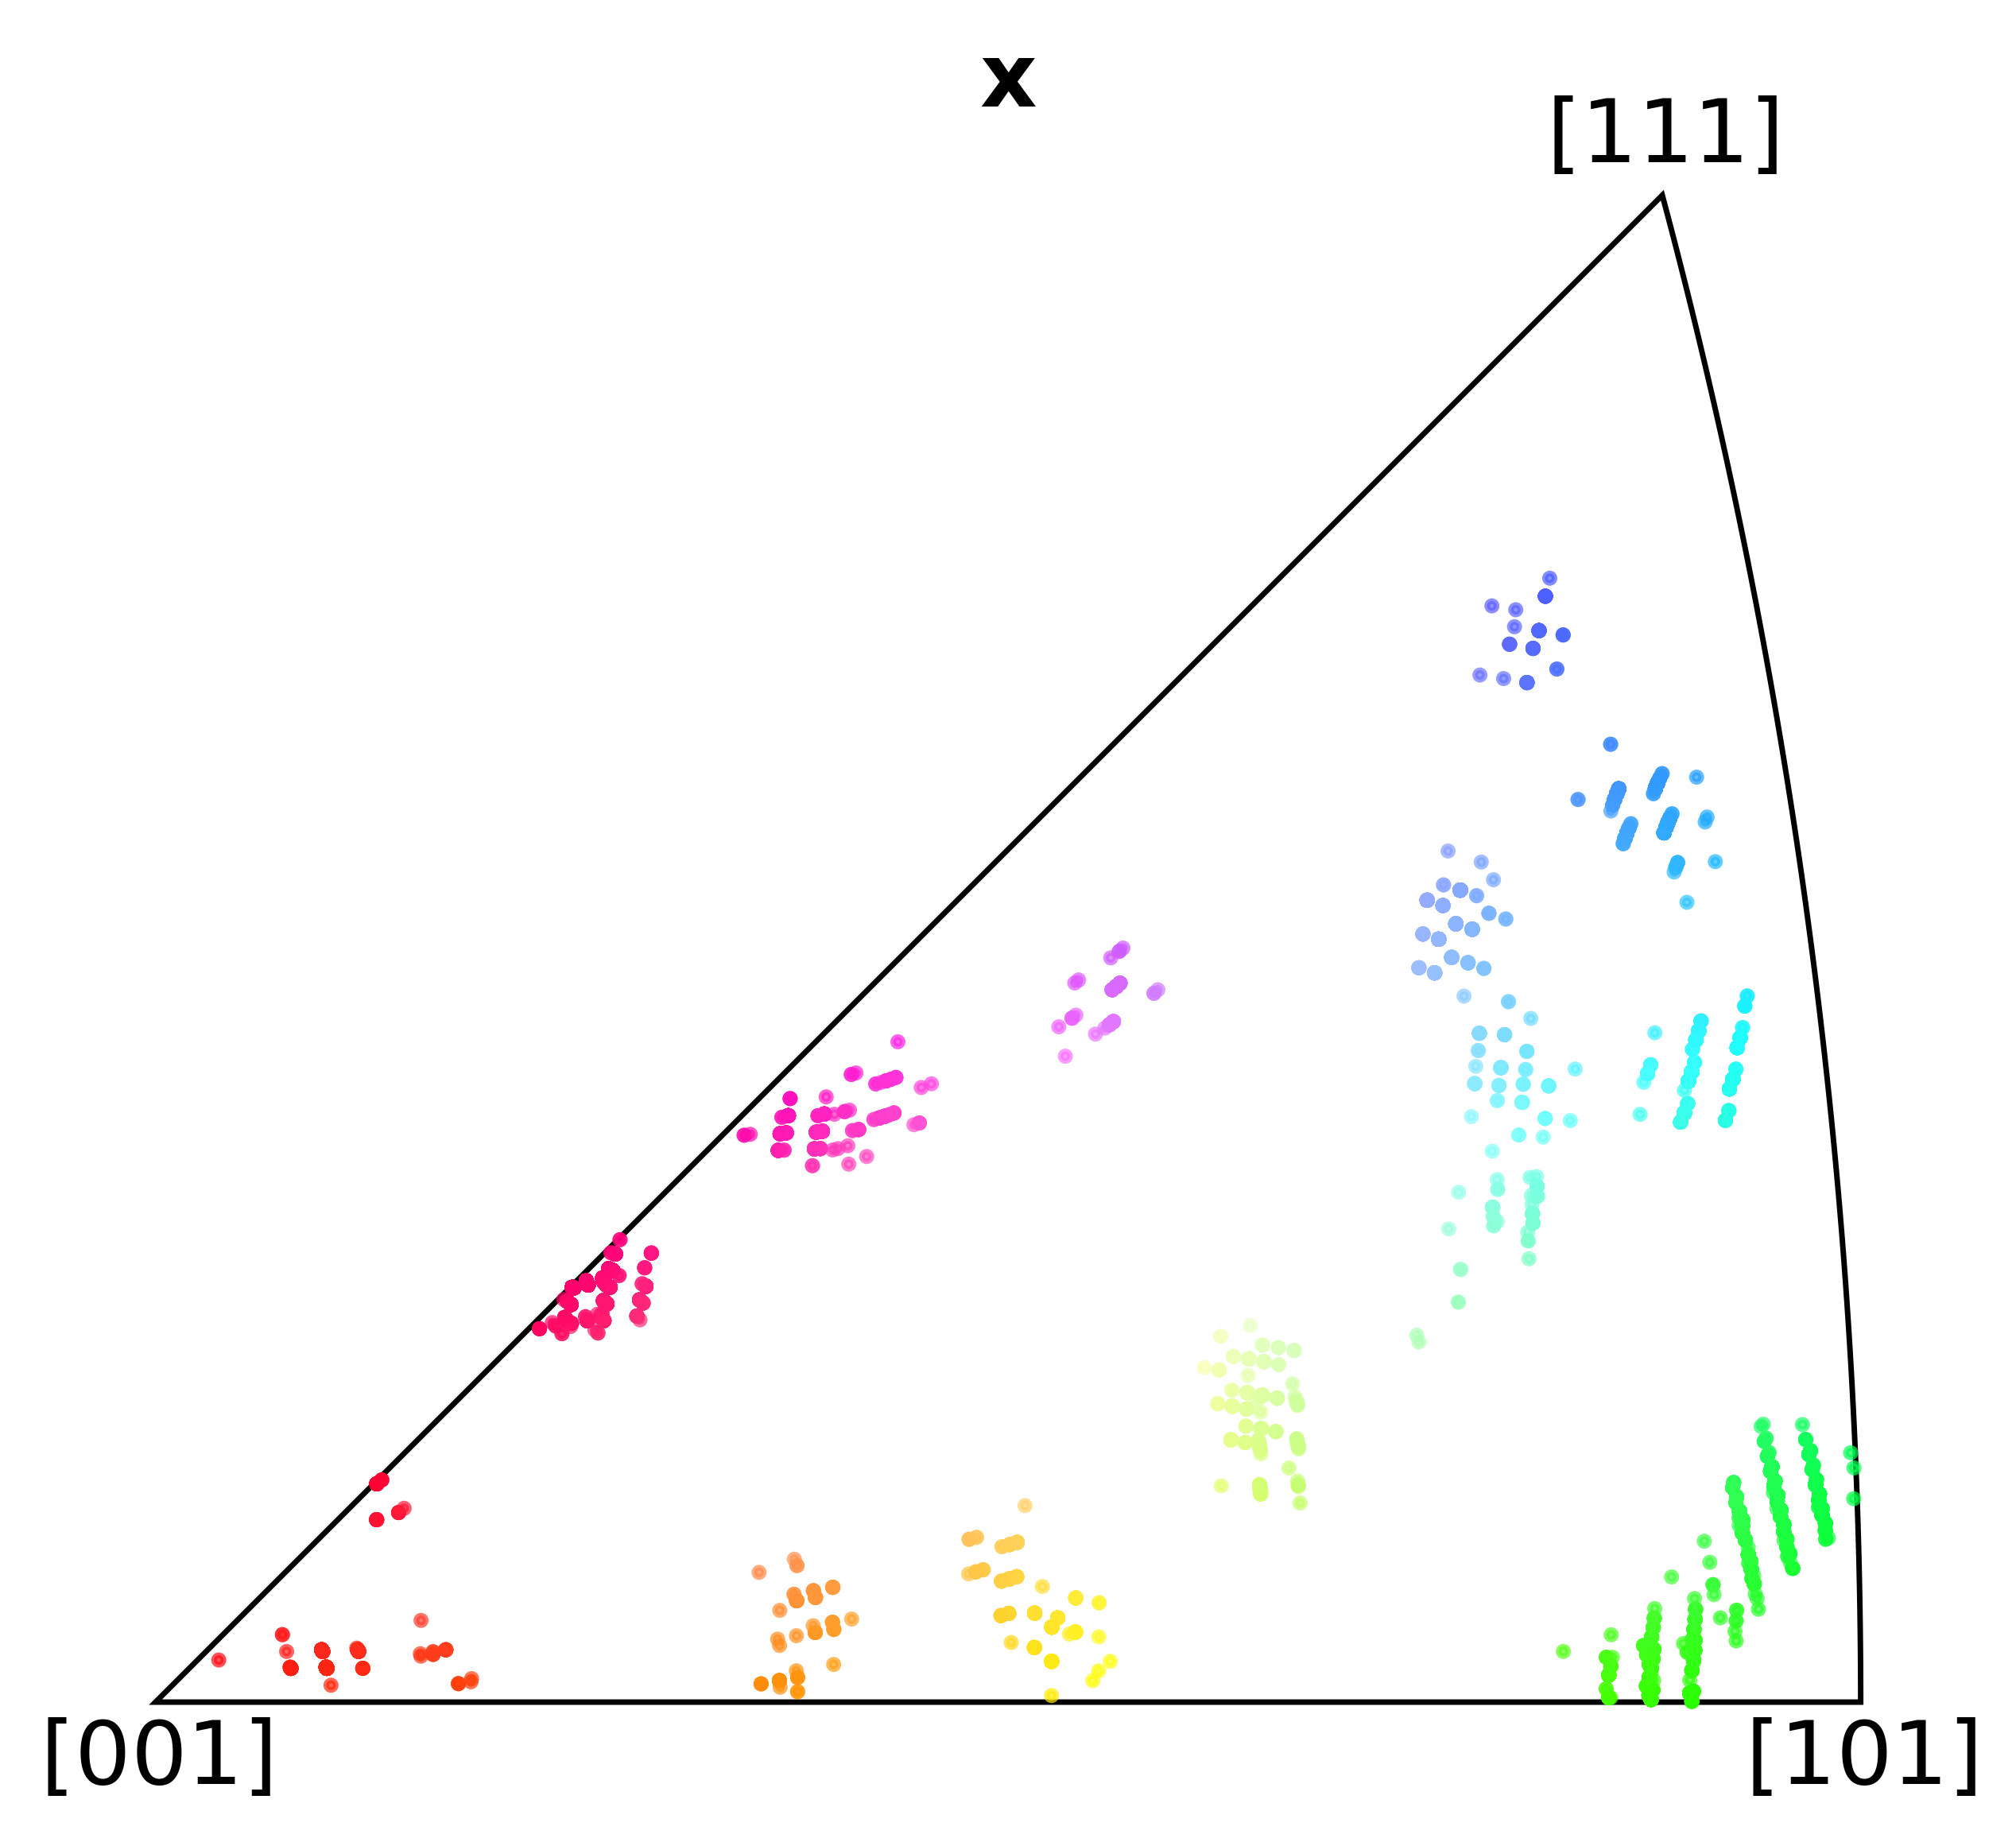

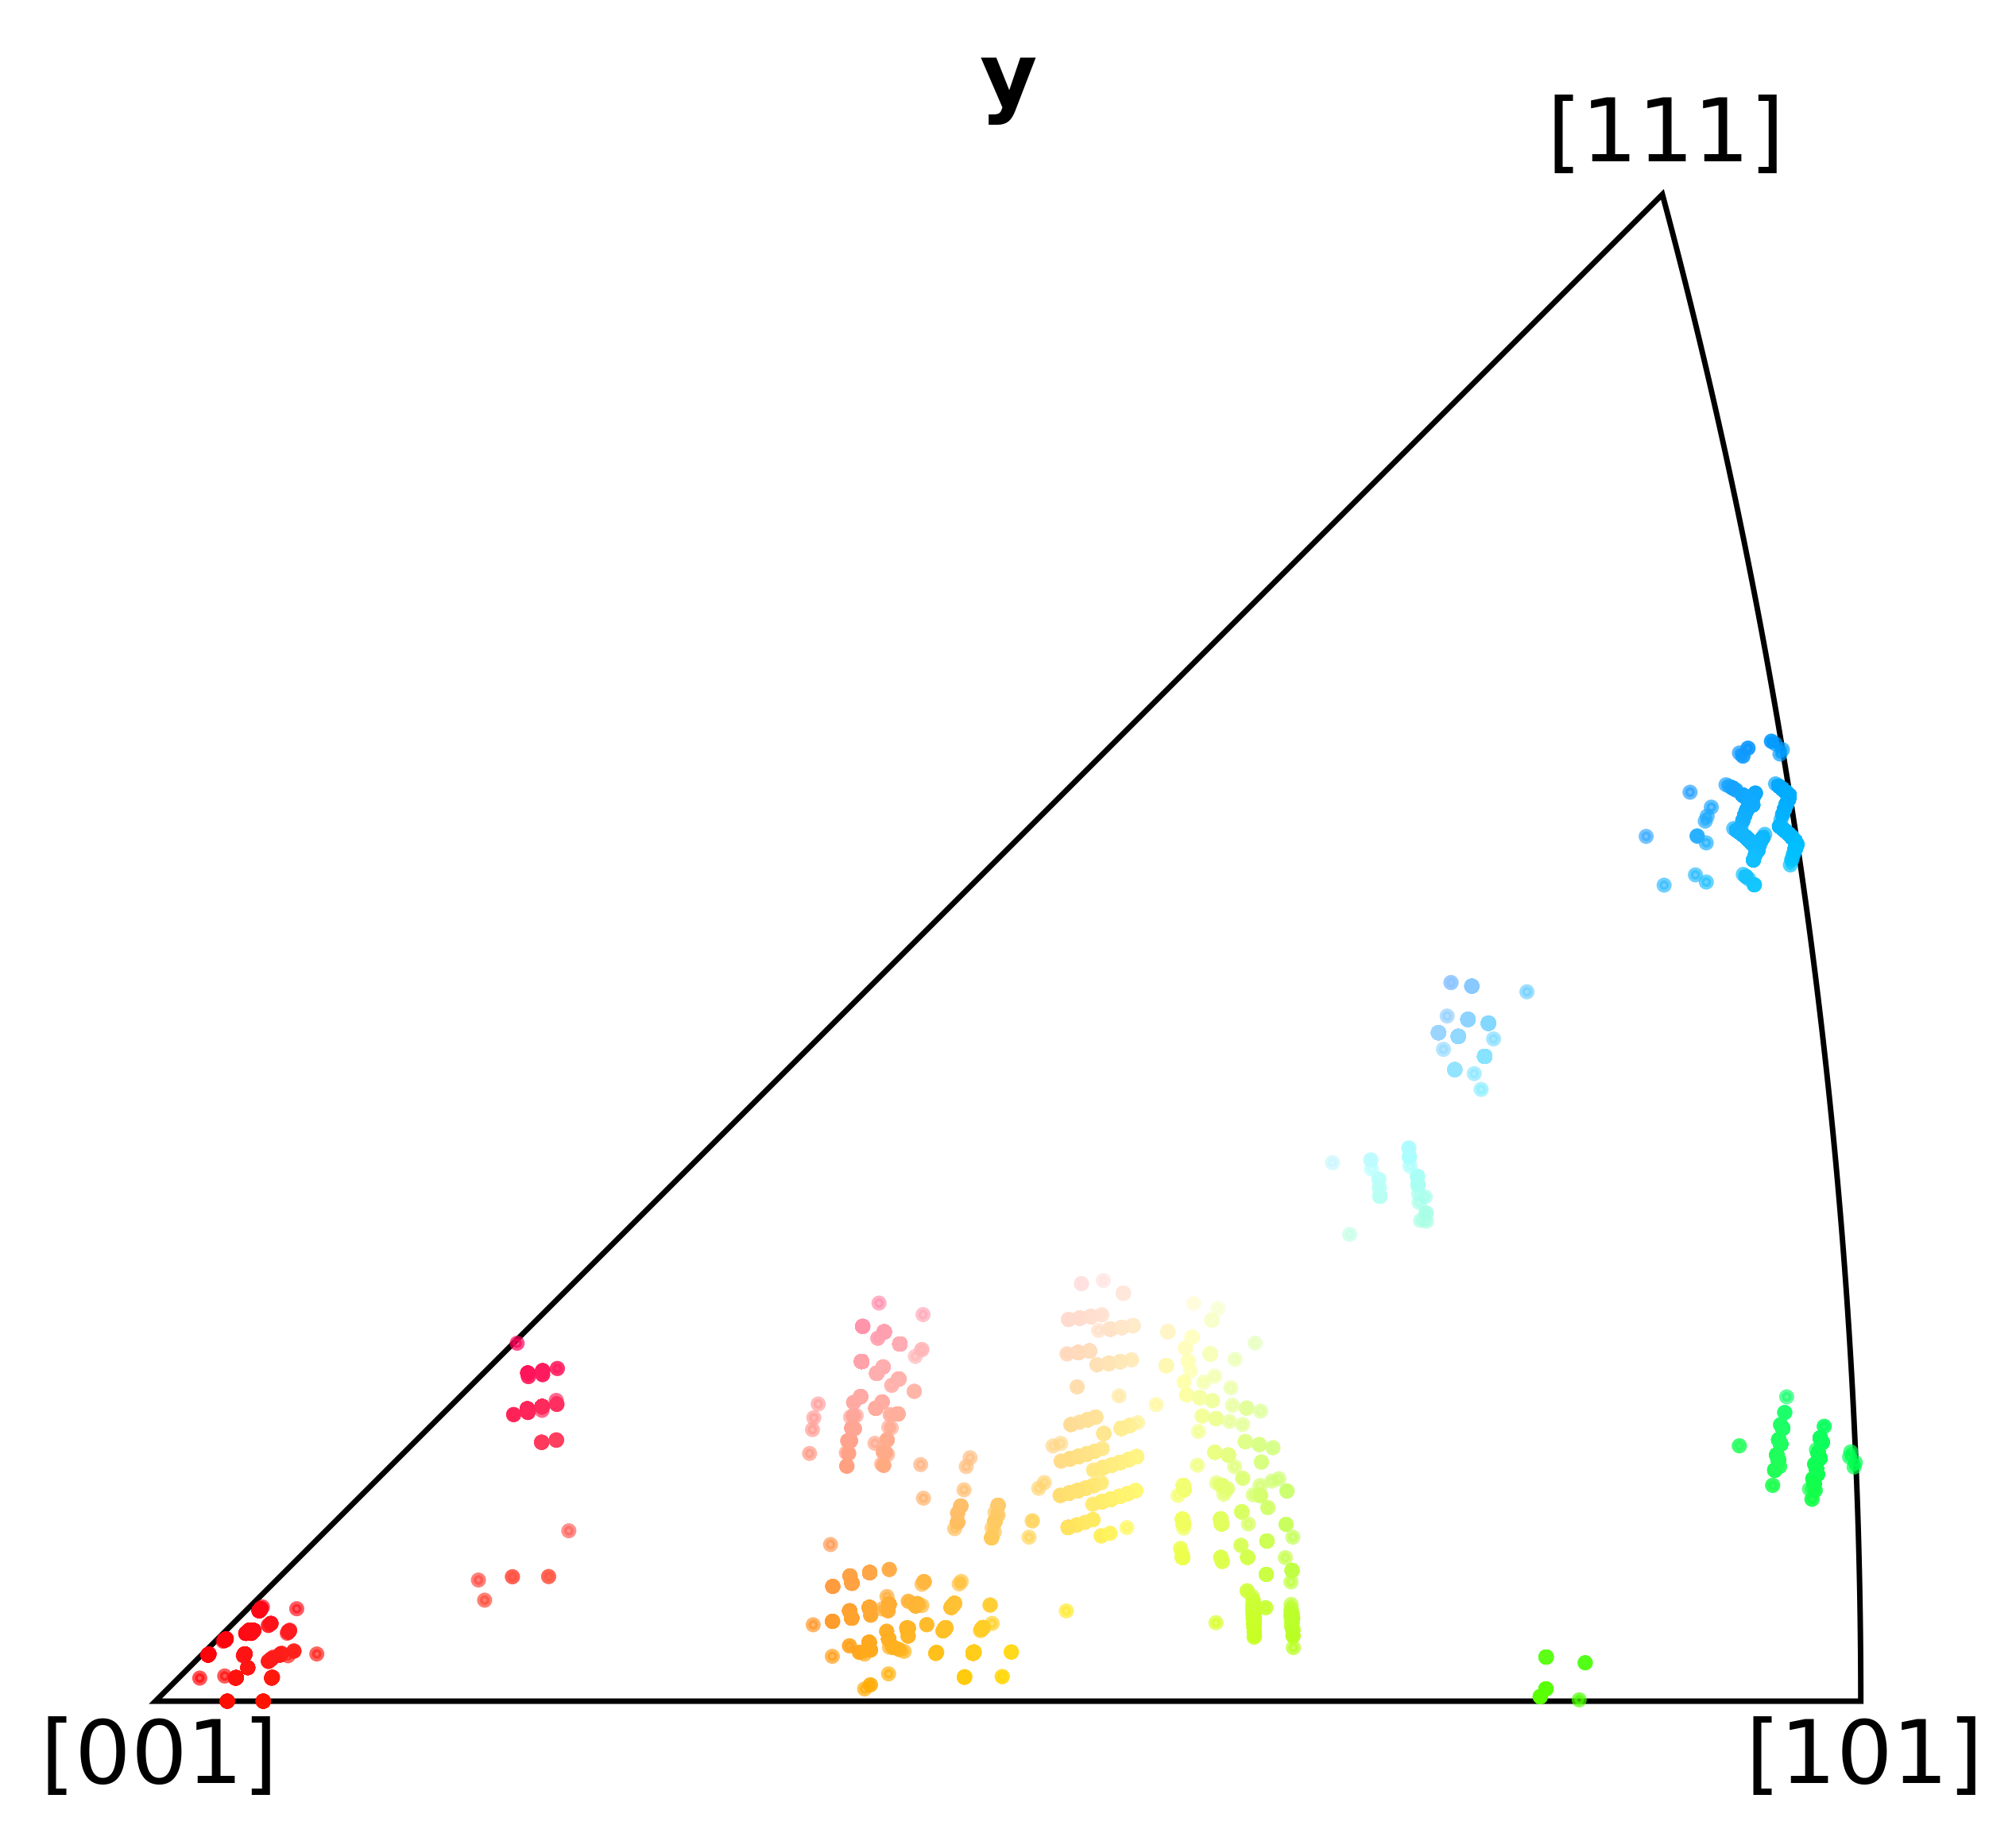

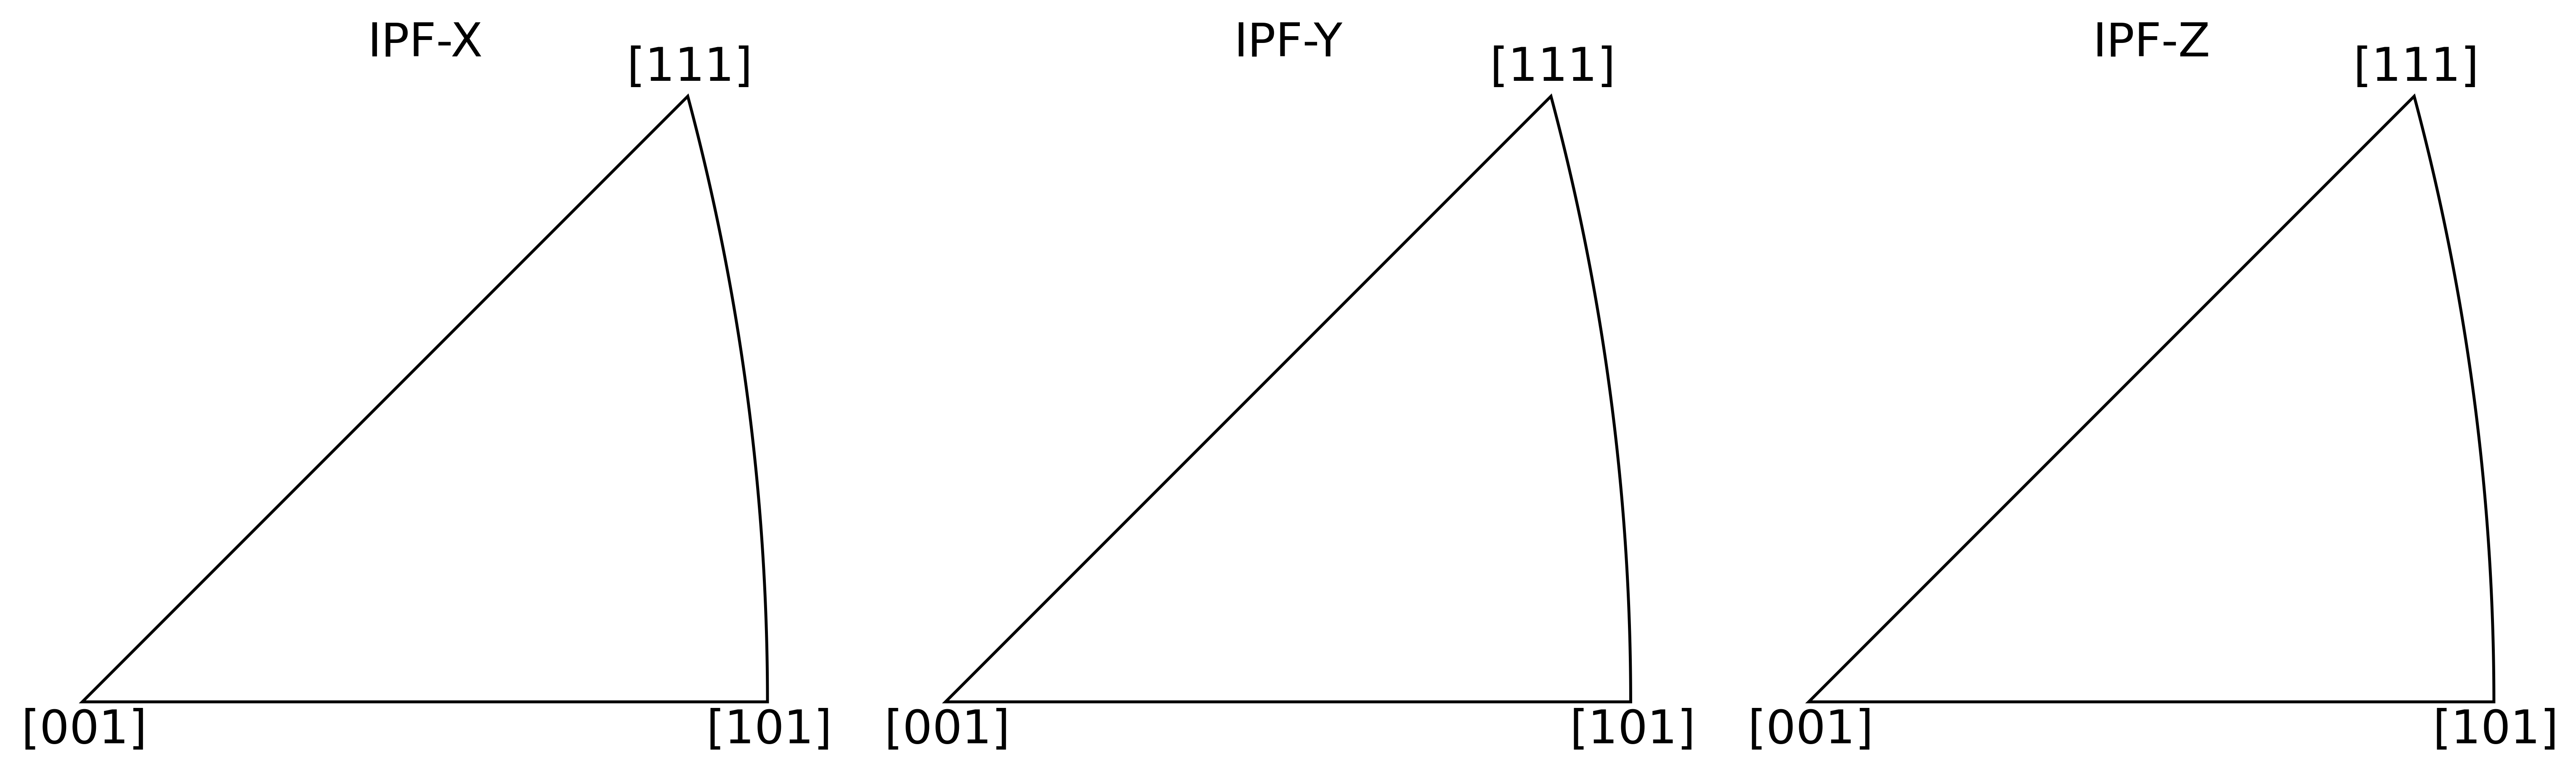

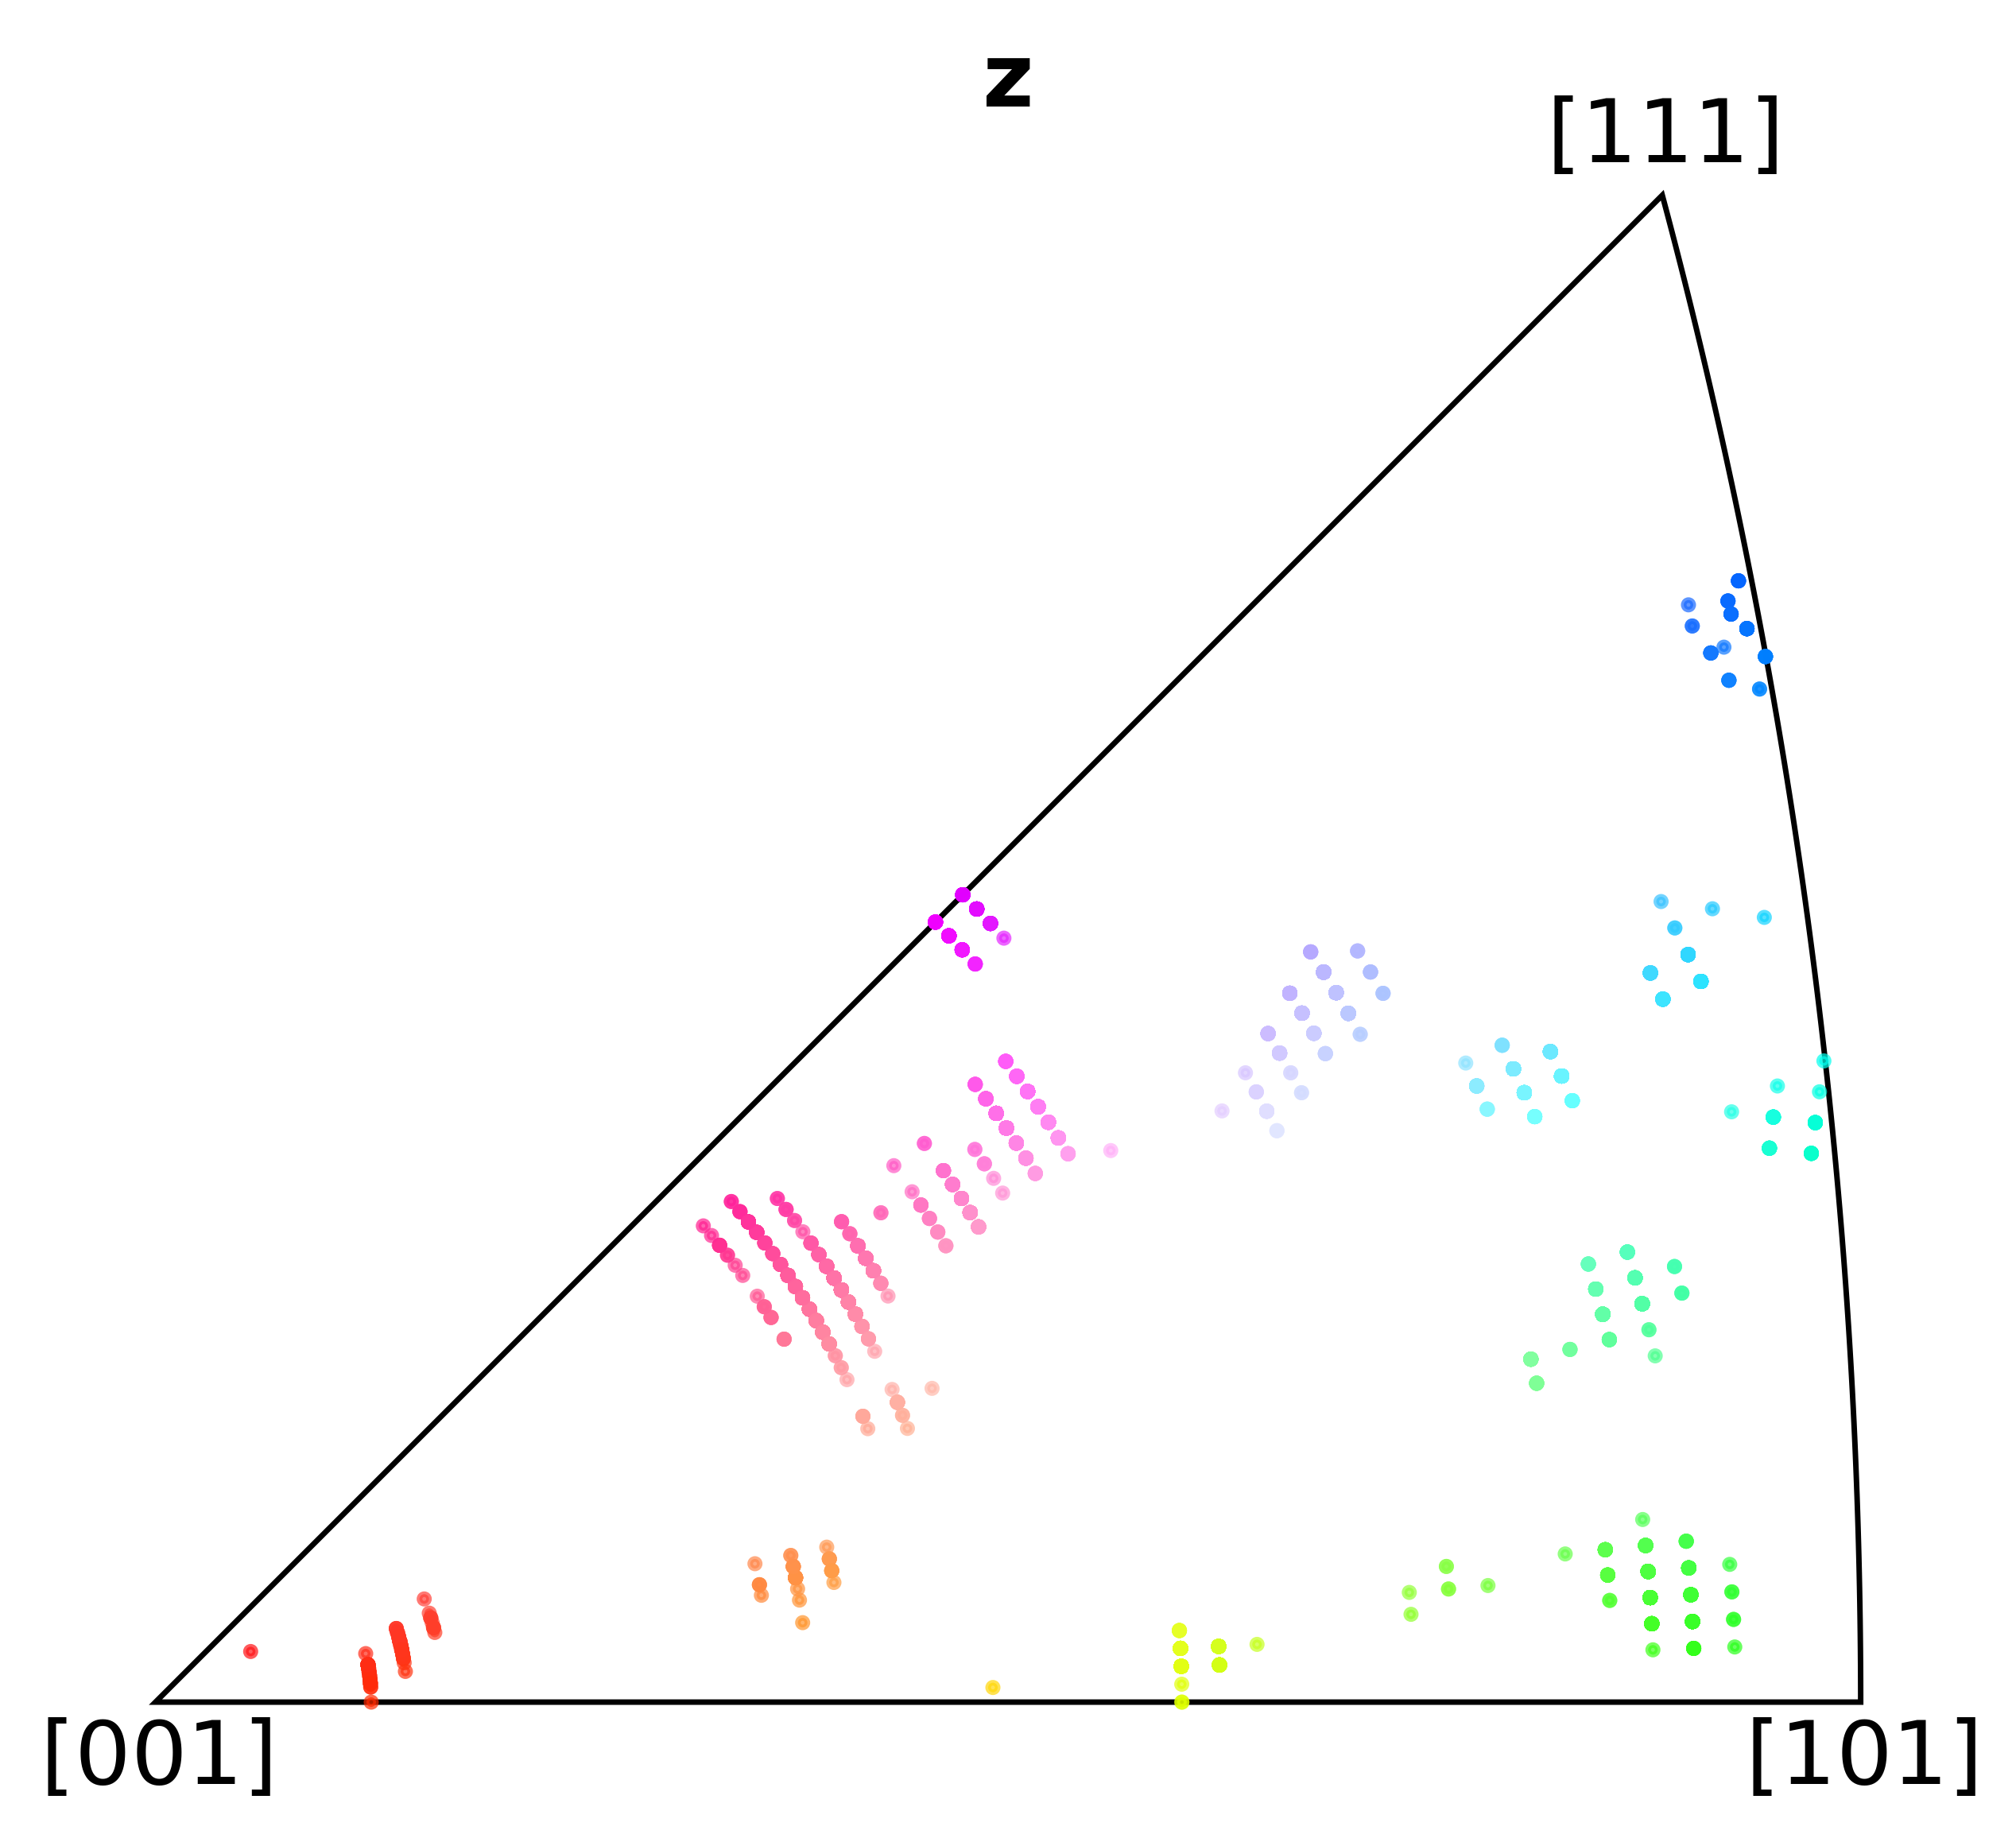

In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)
plot_orientations_on_ipf_xyz(q_spatial, train_ds.sym_class, max_points=8000)


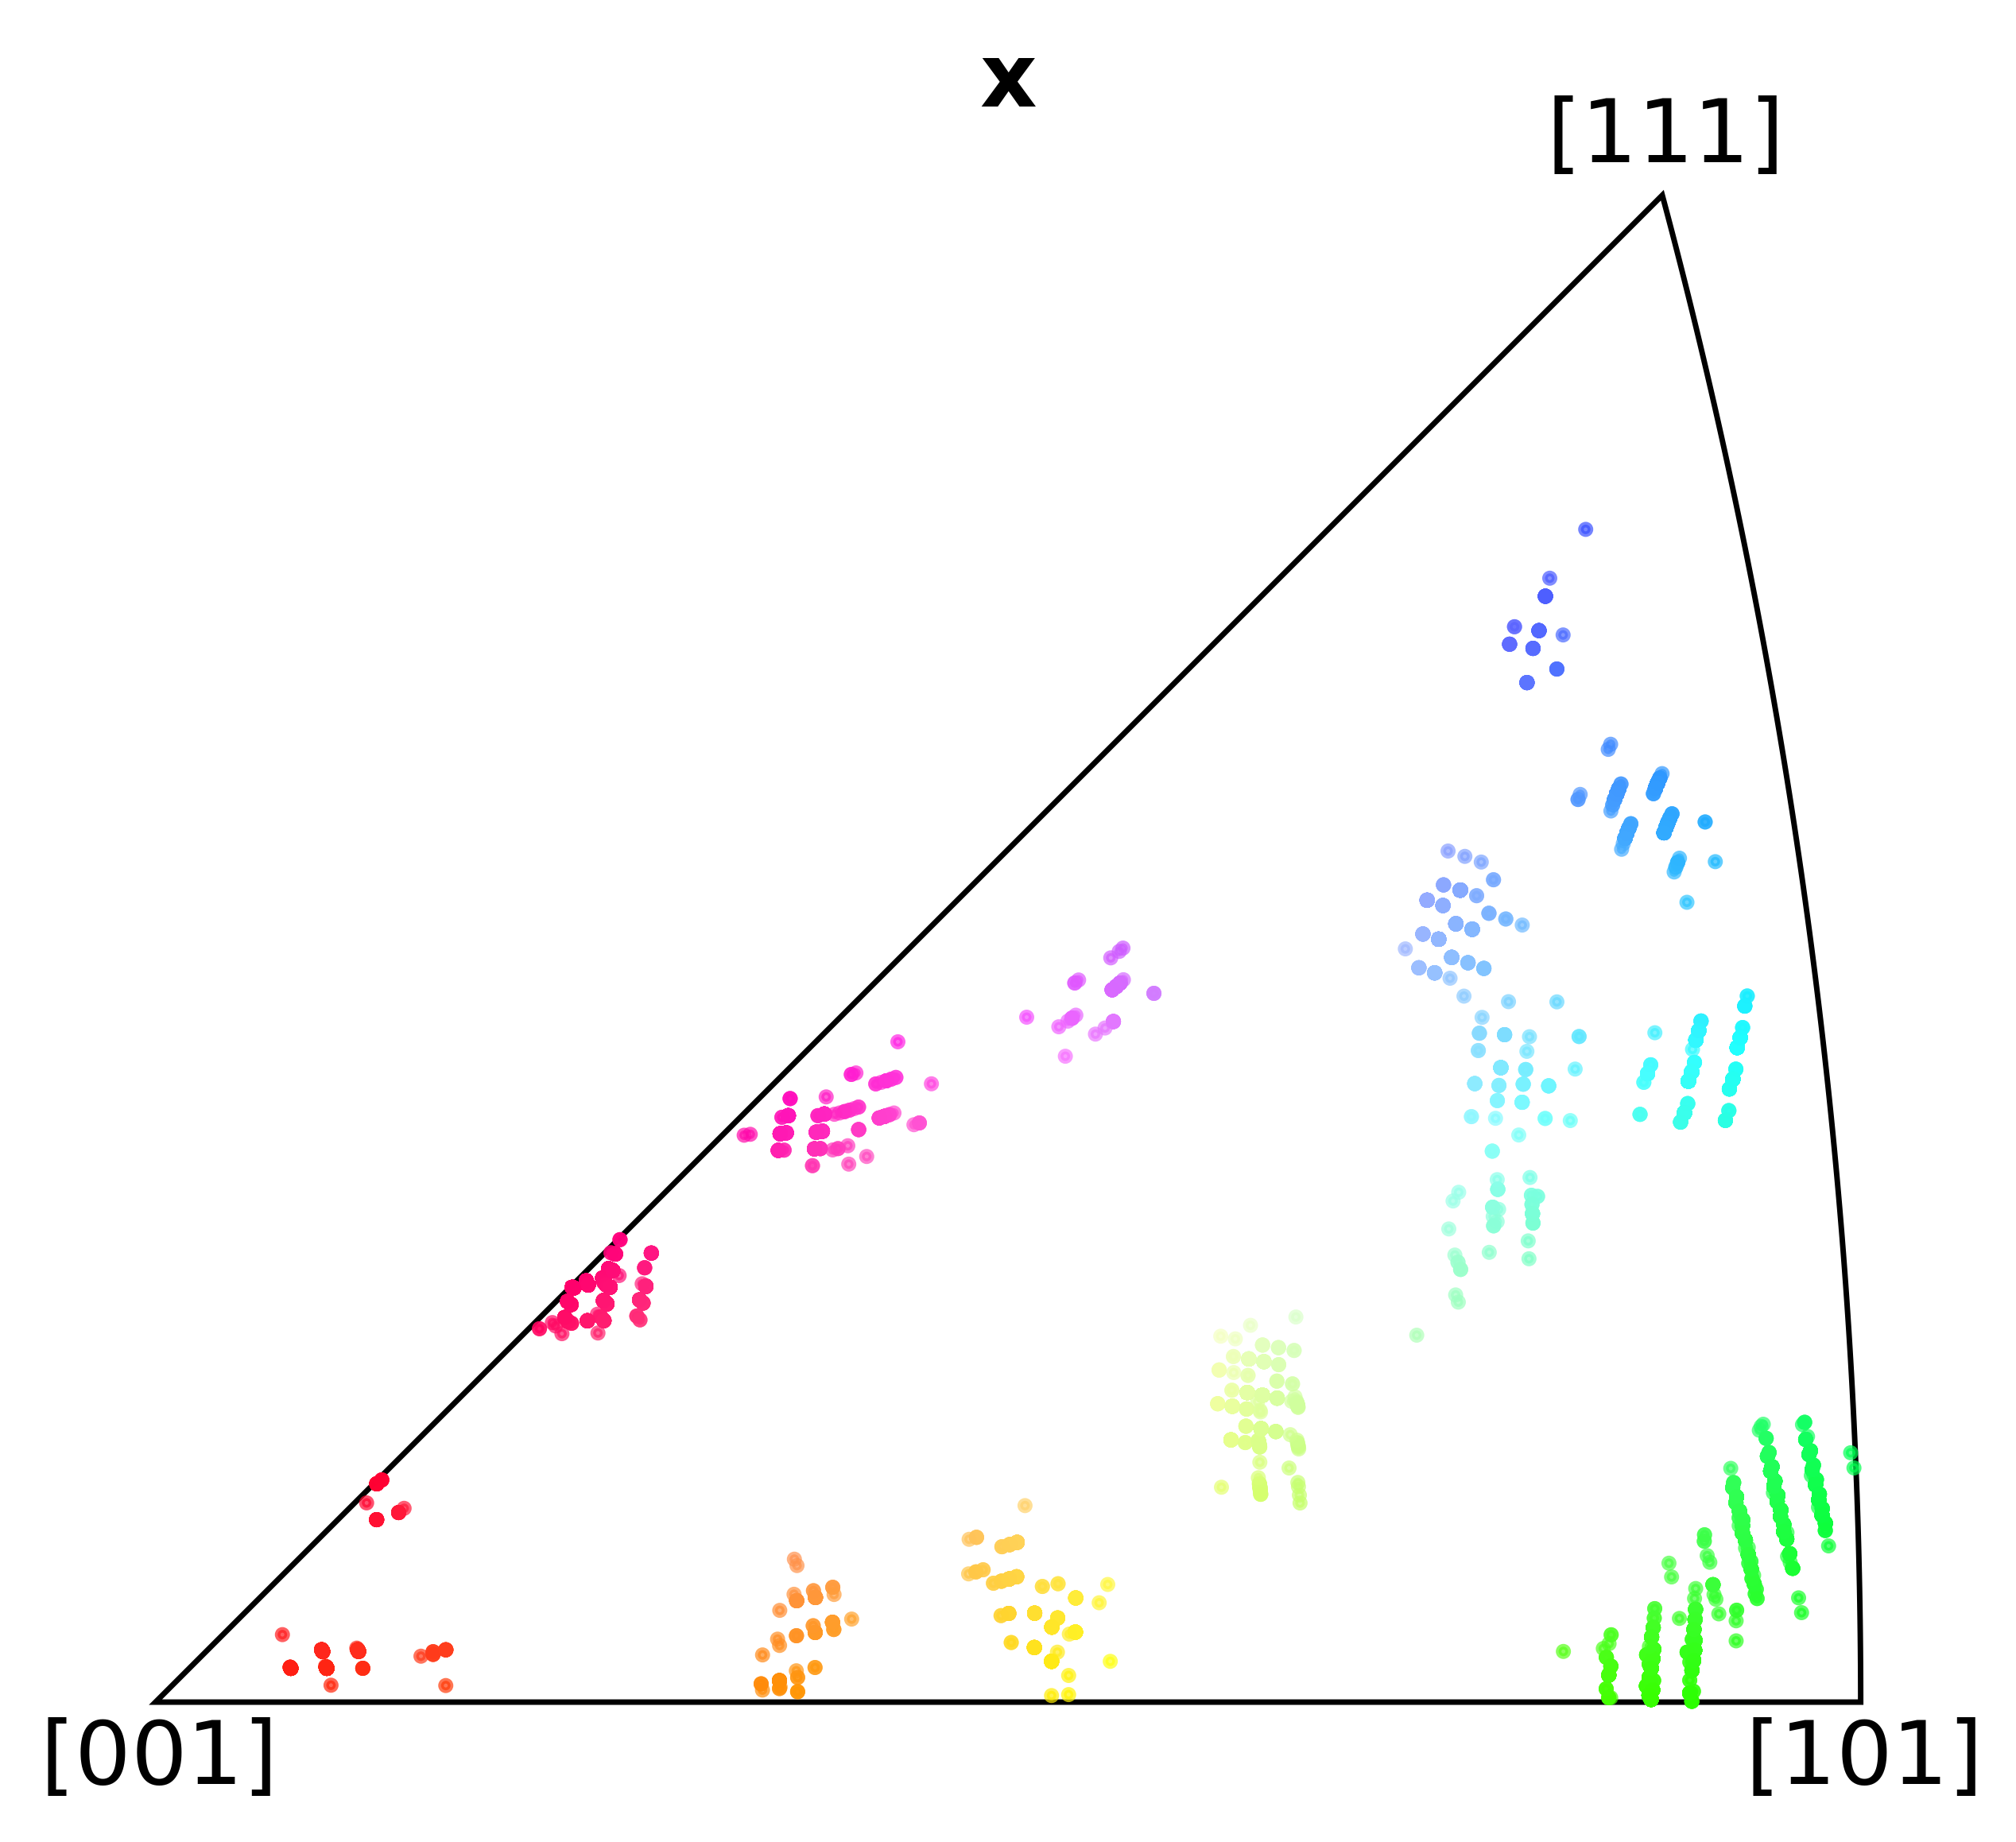

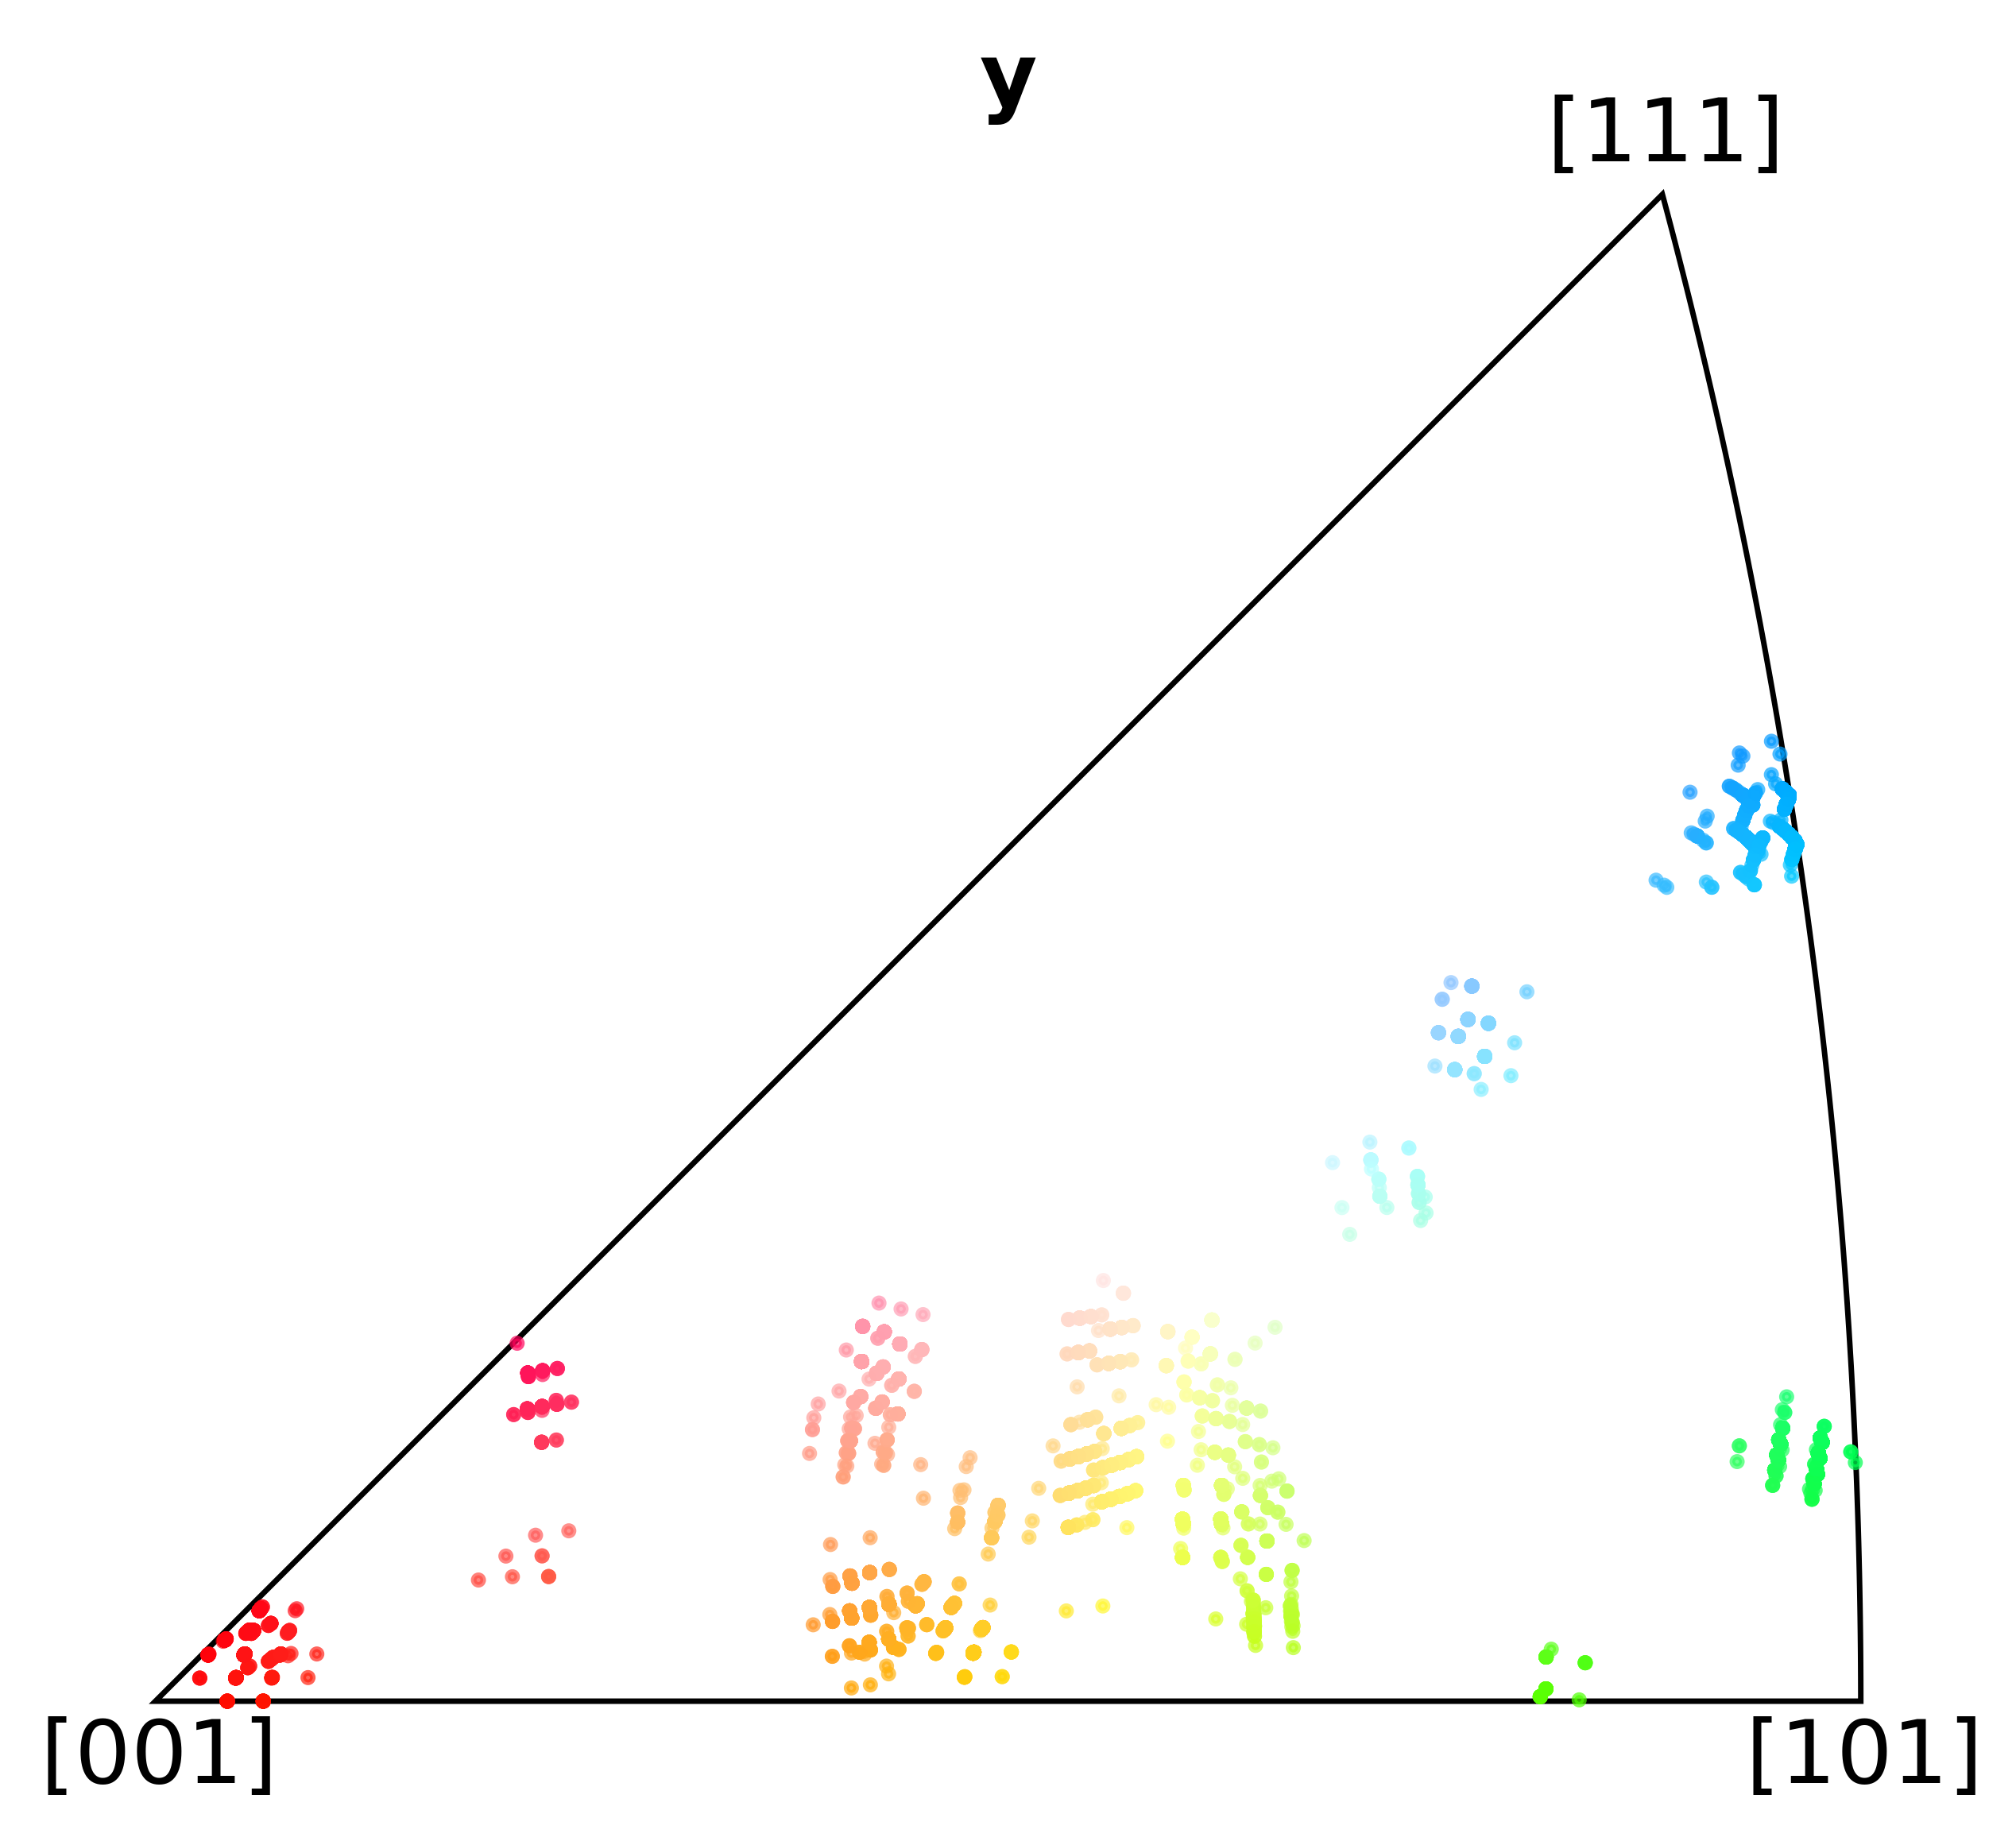

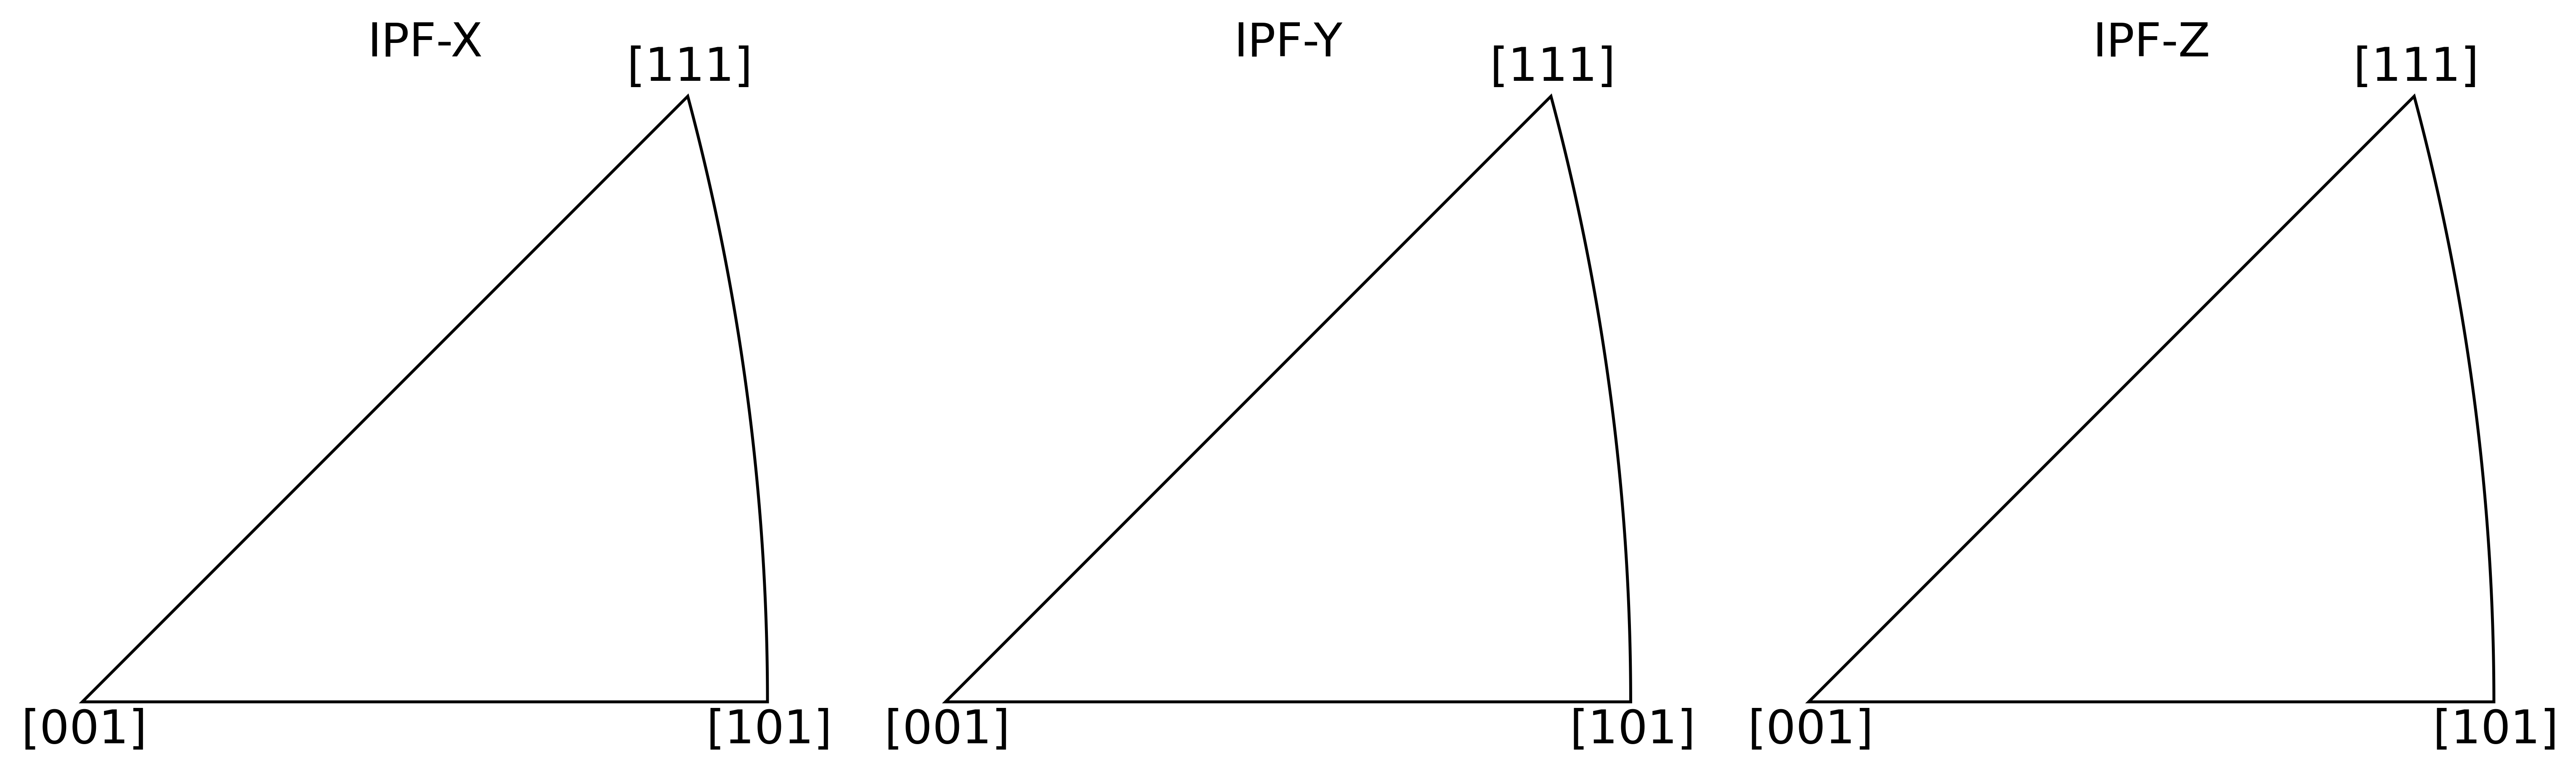

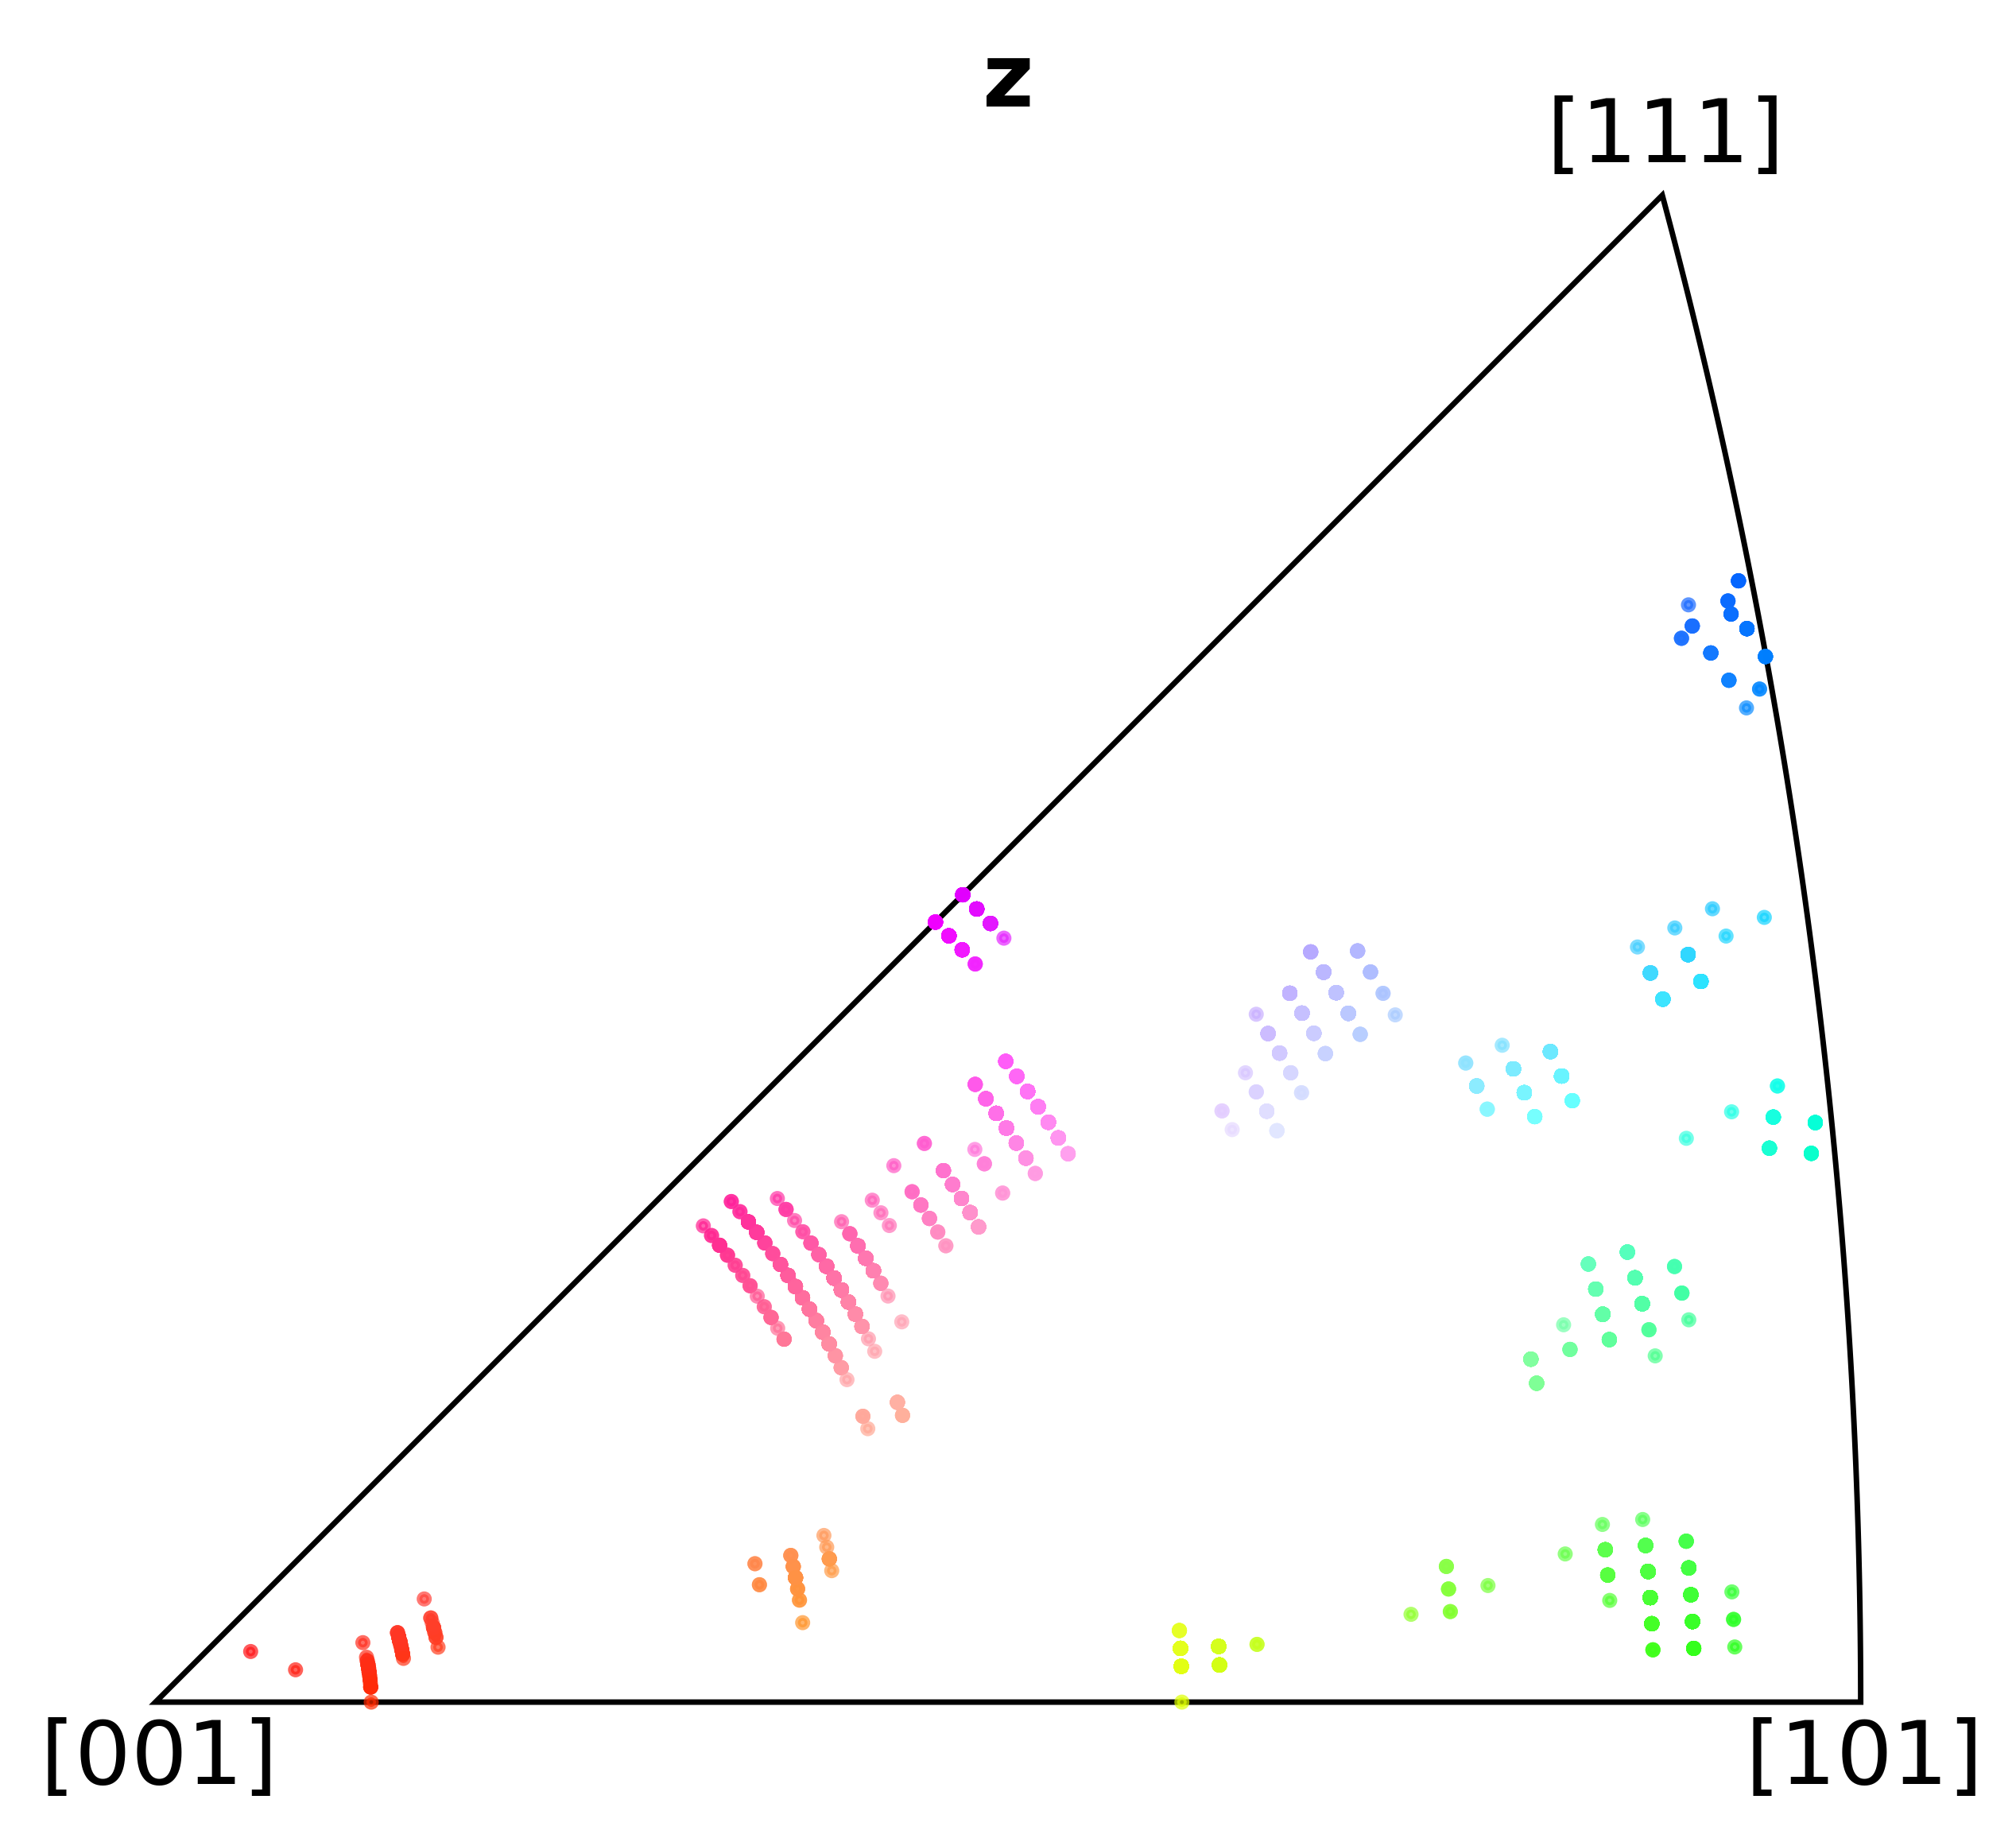

In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(68)
a = plot_orientations_on_ipf_xyz(q_spatial, train_ds.sym_class, max_points=8000)


In [ ]:
result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # X, Y, Z IPF renders, but only ONE mask image
    tol_deg=0.5,
)

[FZ] Best patch at (y=0, x=64) with 3.37% outside FZ
[FZ] Saved multi-panel IPF + blackout + mask + heatmap → fz_patch_debug


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(179)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_68",
    ref_dir="ALL",  # X, Y, Z IPF renders, but only ONE mask image
    tol_deg=0.5,
)

[FZ] Best patch at (y=64, x=64) with 6.15% outside FZ
[FZ] Saved multi-panel IPF + blackout + mask + heatmap → fz_patch_debug


In [ ]:
_, q_spatial = train_ds.get_numpy_spatial_quat(179)

result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_179",
    ref_dir="ALL",  # X, Y, Z IPF renders, but only ONE mask image
    tol_deg=0.5,
)

[FZ] Best patch at (y=64, x=64) with 6.15% outside FZ
[FZ] Saved multi-panel IPF + blackout + mask + heatmap → fz_patch_debug


In [ ]:
result = find_and_render_worst_fz_region(
    q_spatial,
    train_ds.sym_class,
    patch_size=64,
    out_dir="fz_patch_debug",
    base_name="idx_179",
    ref_dir="ALL",  # X, Y, Z IPF renders, but only ONE mask image
    tol_deg=0,
)

[FZ] Best patch at (y=64, x=64) with 6.15% outside FZ
[FZ] Saved multi-panel IPF + blackout + mask + heatmap → fz_patch_debug


In [ ]:
dataset.sym_class

Symmetry (48,) m-3m
[[ 1.      0.      0.      0.    ]
 [ 0.7071  0.      0.      0.7071]
 [ 0.      0.      0.      1.    ]
 [-0.7071  0.      0.      0.7071]
 [ 0.5     0.5     0.5     0.5   ]
 [ 0.      0.      0.7071  0.7071]
 [-0.5    -0.5     0.5     0.5   ]
 [-0.7071 -0.7071  0.      0.    ]
 [ 0.      1.      0.      0.    ]
 [ 0.      0.7071  0.7071  0.    ]
 [ 0.      0.      1.      0.    ]
 [ 0.     -0.7071  0.7071  0.    ]
 [-0.5     0.5     0.5    -0.5   ]
 [ 0.      0.      0.7071 -0.7071]
 [ 0.5    -0.5     0.5    -0.5   ]
 [ 0.7071 -0.7071  0.      0.    ]
 [ 0.      0.7071  0.      0.7071]
 [-0.5     0.5     0.5     0.5   ]
 [-0.7071  0.      0.7071  0.    ]
 [-0.5    -0.5     0.5    -0.5   ]
 [ 0.      0.7071  0.     -0.7071]
 [ 0.5     0.5     0.5    -0.5   ]
 [ 0.7071  0.      0.7071  0.    ]
 [ 0.5    -0.5     0.5     0.5   ]
 [ 1.      0.      0.      0.    ]
 [ 0.7071  0.      0.      0.7071]
 [ 0.      0.      0.      1.    ]
 [-0.7071  0.      0.      0.7071]


In [ ]:
dataset.sym_class._symmetry

AttributeError: 'Symmetry' object has no attribute '_symmetry'

In [ ]:
a, b = dataset.sym_class

ValueError: too many values to unpack (expected 2)

In [ ]:
    ori_full = Orientation(q_spatial.reshape(-1, 4), symmetry=sym_class)

In [ ]:
ori_full._symmetry

(Symmetry (1,) 1
 [[1. 0. 0. 0.]],
 Symmetry (48,) m-3m
 [[ 1.      0.      0.      0.    ]
  [ 0.7071  0.      0.      0.7071]
  [ 0.      0.      0.      1.    ]
  [-0.7071  0.      0.      0.7071]
  [ 0.5     0.5     0.5     0.5   ]
  [ 0.      0.      0.7071  0.7071]
  [-0.5    -0.5     0.5     0.5   ]
  [-0.7071 -0.7071  0.      0.    ]
  [ 0.      1.      0.      0.    ]
  [ 0.      0.7071  0.7071  0.    ]
  [ 0.      0.      1.      0.    ]
  [ 0.     -0.7071  0.7071  0.    ]
  [-0.5     0.5     0.5    -0.5   ]
  [ 0.      0.      0.7071 -0.7071]
  [ 0.5    -0.5     0.5    -0.5   ]
  [ 0.7071 -0.7071  0.      0.    ]
  [ 0.      0.7071  0.      0.7071]
  [-0.5     0.5     0.5     0.5   ]
  [-0.7071  0.      0.7071  0.    ]
  [-0.5    -0.5     0.5    -0.5   ]
  [ 0.      0.7071  0.     -0.7071]
  [ 0.5     0.5     0.5    -0.5   ]
  [ 0.7071  0.      0.7071  0.    ]
  [ 0.5    -0.5     0.5     0.5   ]
  [ 1.      0.      0.      0.    ]
  [ 0.7071  0.      0.      0.7071]
  [ 0.  

In [ ]:
a,b = ori_full._symmetry

In [ ]:
a

Symmetry (1,) 1
[[1. 0. 0. 0.]]

In [ ]:
b

Symmetry (48,) m-3m
[[ 1.      0.      0.      0.    ]
 [ 0.7071  0.      0.      0.7071]
 [ 0.      0.      0.      1.    ]
 [-0.7071  0.      0.      0.7071]
 [ 0.5     0.5     0.5     0.5   ]
 [ 0.      0.      0.7071  0.7071]
 [-0.5    -0.5     0.5     0.5   ]
 [-0.7071 -0.7071  0.      0.    ]
 [ 0.      1.      0.      0.    ]
 [ 0.      0.7071  0.7071  0.    ]
 [ 0.      0.      1.      0.    ]
 [ 0.     -0.7071  0.7071  0.    ]
 [-0.5     0.5     0.5    -0.5   ]
 [ 0.      0.      0.7071 -0.7071]
 [ 0.5    -0.5     0.5    -0.5   ]
 [ 0.7071 -0.7071  0.      0.    ]
 [ 0.      0.7071  0.      0.7071]
 [-0.5     0.5     0.5     0.5   ]
 [-0.7071  0.      0.7071  0.    ]
 [-0.5    -0.5     0.5    -0.5   ]
 [ 0.      0.7071  0.     -0.7071]
 [ 0.5     0.5     0.5    -0.5   ]
 [ 0.7071  0.      0.7071  0.    ]
 [ 0.5    -0.5     0.5     0.5   ]
 [ 1.      0.      0.      0.    ]
 [ 0.7071  0.      0.      0.7071]
 [ 0.      0.      0.      1.    ]
 [-0.7071  0.      0.      0.7071]


In [ ]:
form itertools import product as iproduct

SyntaxError: invalid syntax (<ipython-input-115-e5ab00236379>, line 1)

In [ ]:
from itertools import product as iproduct

In [ ]:
Gl, Gr =ori_full._symmetry
symmetry_pairs = iproduct(Gl, Gr)

In [ ]:
symmetry_pairs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d
import orix.plot as orix_plot

# --- Define cubic symmetry ---
sym = symmetry.Oh  # m-3m point group (cubic)
ref_dir = Vector3d.zvector()

# --- Construct a quaternion that is outside the FZ ---
# A 90° rotation around x-axis
axis = np.array([1, 0, 0], dtype=float)
theta = np.deg2rad(90)
w = np.cos(theta / 2)
xyz = axis * np.sin(theta / 2)
q_outside = np.concatenate([[w], xyz])  # scalar-first
ori_outside = Orientation(q_outside[np.newaxis, :], symmetry=sym)

# --- Map into FZ ---
ori_fz = ori_outside.map_into_symmetry_reduced_zone()

# --- Compute misorientation angle ---
mis = ori_fz.inv() * ori_outside
ang_deg = np.rad2deg(mis.angle[0])
print(f"→ Misorientation angle to FZ: {ang_deg:.3f}°")

# --- Generate all symmetry equivalents ---
sym_ops = sym.operators
ori_equiv = sym_ops * ori_outside  # 24 equivalent orientations

# --- Convert to pole directions ---
v_orig = ori_outside * ref_dir
v_fz = ori_fz * ref_dir
v_equiv = ori_equiv * ref_dir

# --- IPF Key ---
ipf_key = orix_plot.IPFColorKeyTSL(sym.laue)
ipf_key.direction = ref_dir

# --- Plot ---
fig, ax = plt.subplots(subplot_kw={"projection": "ipf", "symmetry": sym.laue}, figsize=(6, 6))

# all equivalents
ax.scatter(v_equiv, c="lightgray", s=30, label="Symmetry equivalents")

# original orientation
ax.scatter(v_orig, c="red", s=60, marker="o", label="Original")

# FZ-mapped orientation
ax.scatter(v_fz, c="black", s=80, marker="*", label="FZ mapped")

# FZ boundary
ax.restrict_to_sector(sym.fundamental_sector, edgecolor="black", lw=1.5, pad=3)
ax.legend(loc="upper right")
ax.set_title(f"Cubic FZ Mapping — {ang_deg:.1f}° misorientation")
plt.tight_layout()
plt.show()


→ Misorientation angle to FZ: 90.000°


AttributeError: 'Symmetry' object has no attribute 'operators'

In [ ]:
 sym.get_operators()

AttributeError: 'Symmetry' object has no attribute 'get_operators'

In [ ]:
sym.rotations

AttributeError: 'Symmetry' object has no attribute 'rotations'

In [ ]:
sym

Symmetry (48,) m-3m
[[ 1.      0.      0.      0.    ]
 [ 0.7071  0.      0.      0.7071]
 [ 0.      0.      0.      1.    ]
 [-0.7071  0.      0.      0.7071]
 [ 0.5     0.5     0.5     0.5   ]
 [ 0.      0.      0.7071  0.7071]
 [-0.5    -0.5     0.5     0.5   ]
 [-0.7071 -0.7071  0.      0.    ]
 [ 0.      1.      0.      0.    ]
 [ 0.      0.7071  0.7071  0.    ]
 [ 0.      0.      1.      0.    ]
 [ 0.     -0.7071  0.7071  0.    ]
 [-0.5     0.5     0.5    -0.5   ]
 [ 0.      0.      0.7071 -0.7071]
 [ 0.5    -0.5     0.5    -0.5   ]
 [ 0.7071 -0.7071  0.      0.    ]
 [ 0.      0.7071  0.      0.7071]
 [-0.5     0.5     0.5     0.5   ]
 [-0.7071  0.      0.7071  0.    ]
 [-0.5    -0.5     0.5    -0.5   ]
 [ 0.      0.7071  0.     -0.7071]
 [ 0.5     0.5     0.5    -0.5   ]
 [ 0.7071  0.      0.7071  0.    ]
 [ 0.5    -0.5     0.5     0.5   ]
 [ 1.      0.      0.      0.    ]
 [ 0.7071  0.      0.      0.7071]
 [ 0.      0.      0.      1.    ]
 [-0.7071  0.      0.      0.7071]


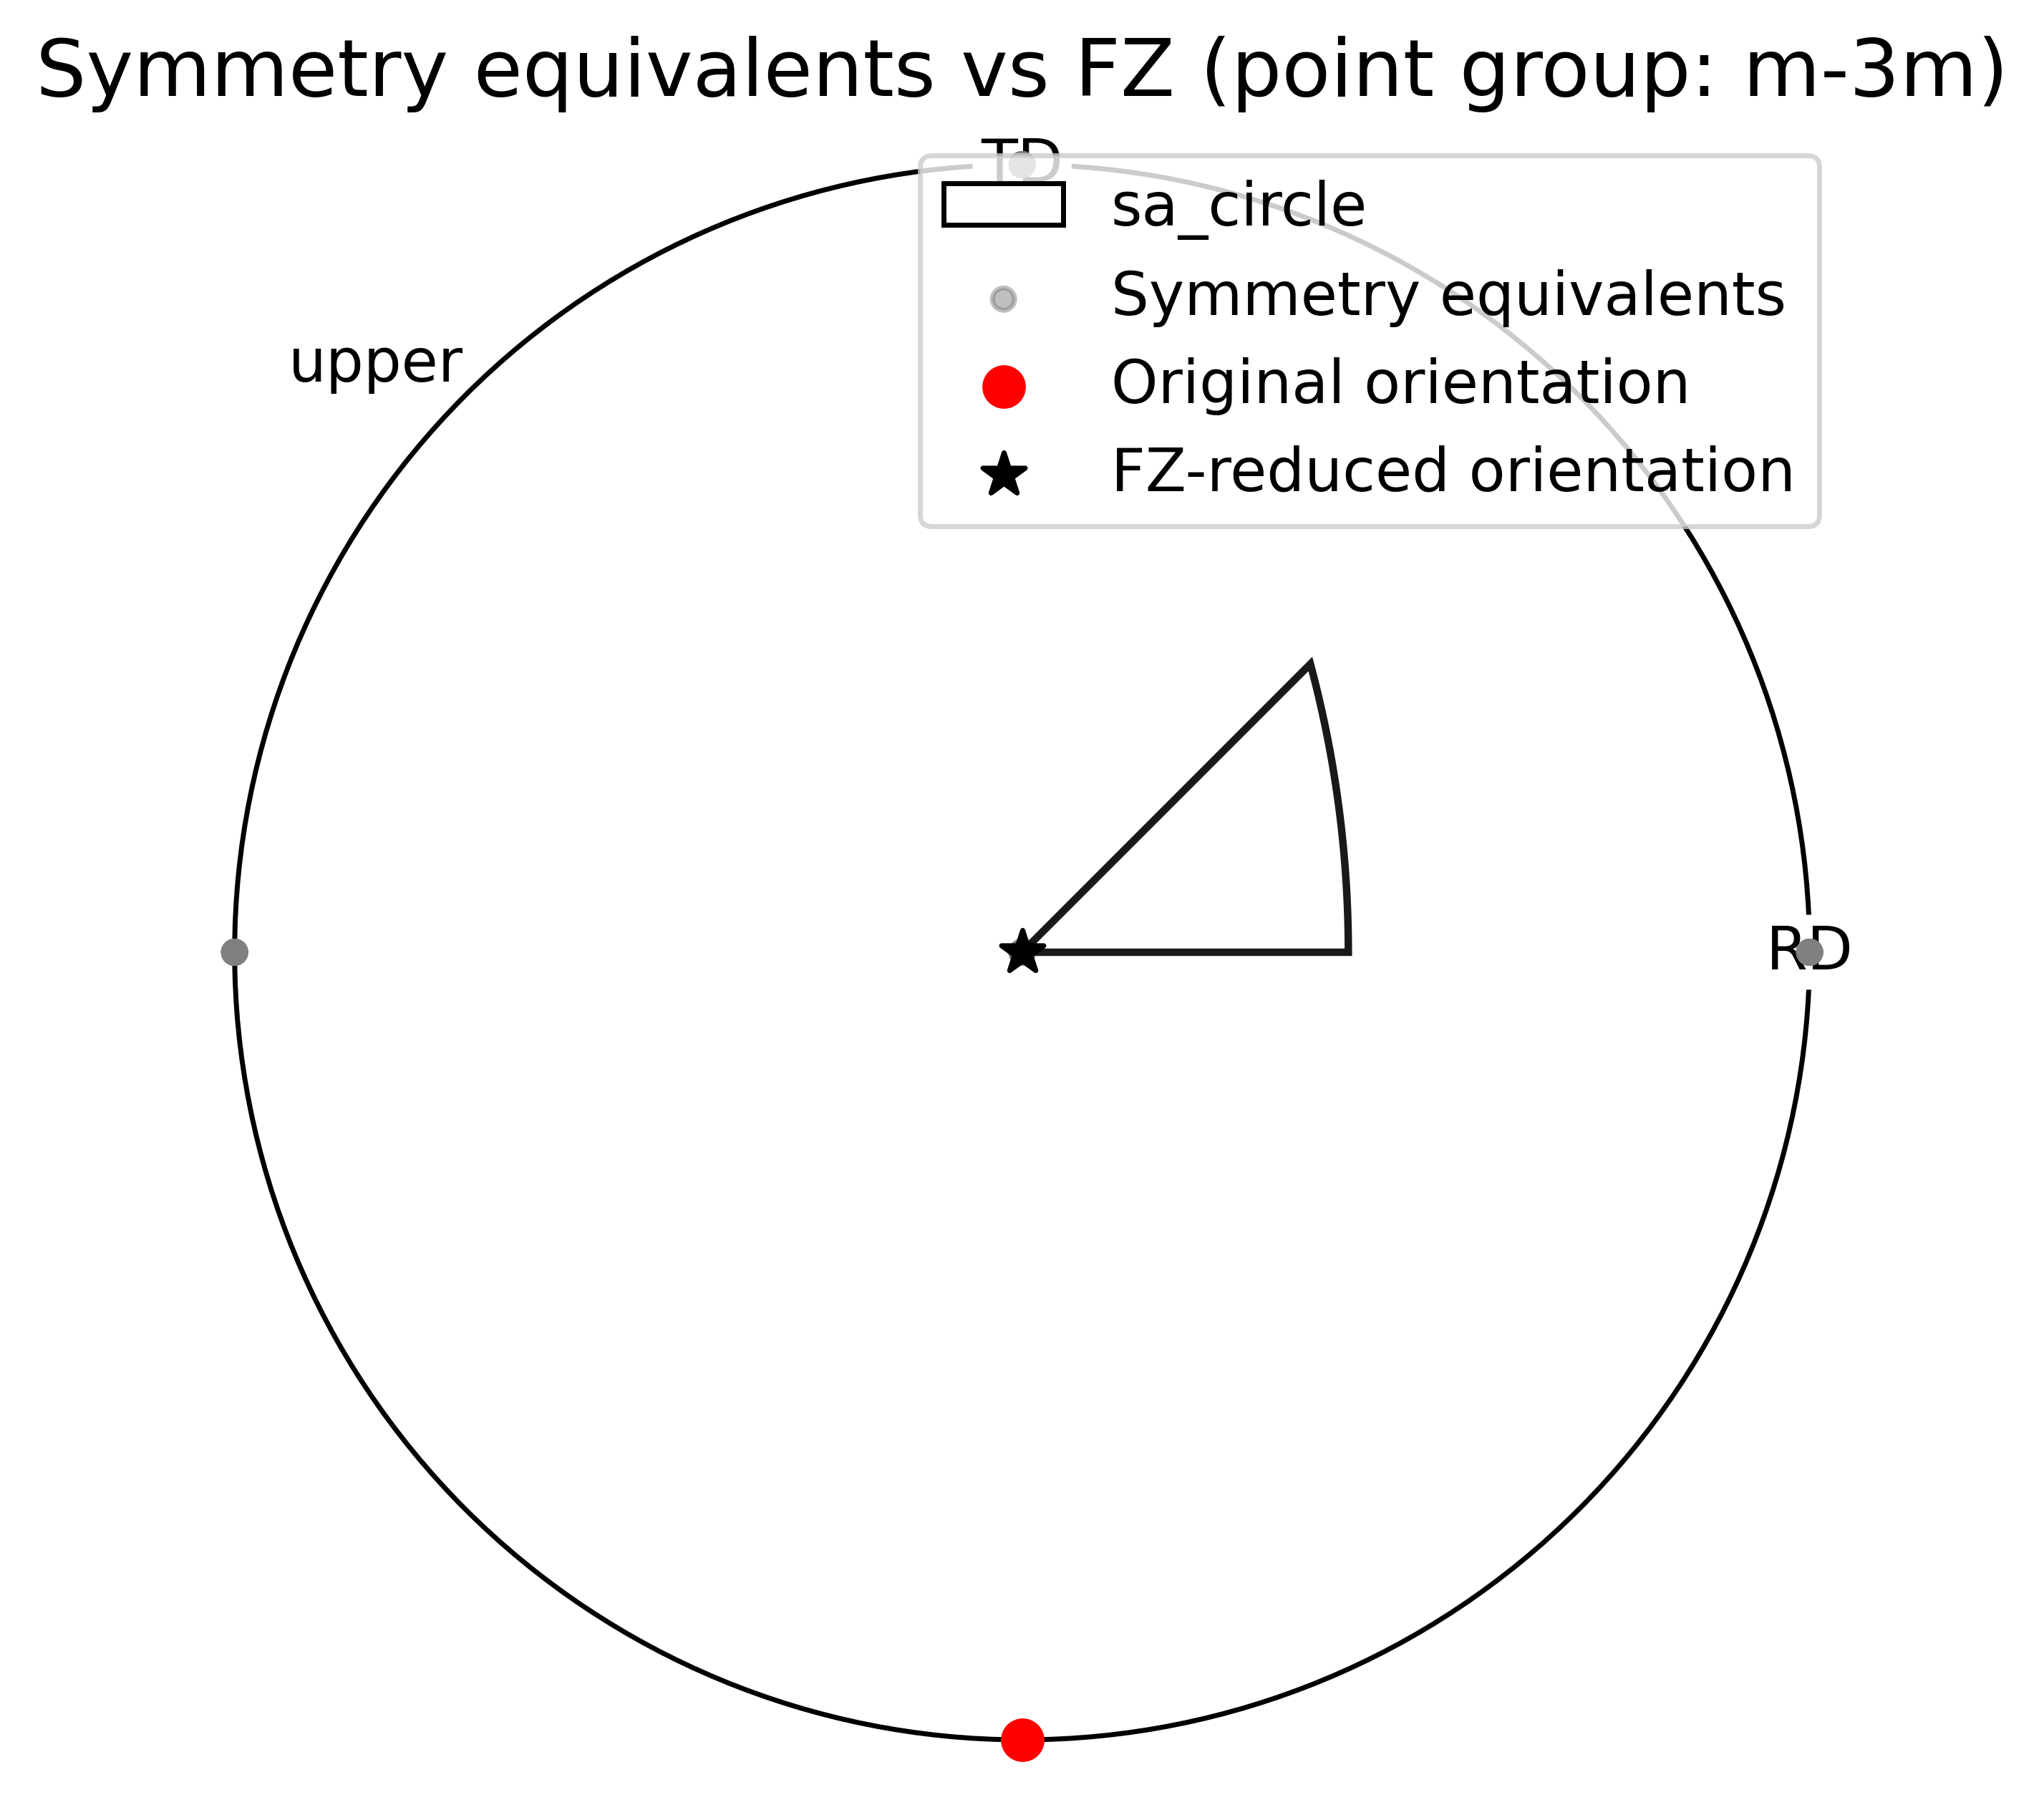

In [ ]:
from orix.quaternion import Orientation

# Suppose we have a single orientation outside the FZ
ori_outside = Orientation(q_outside[np.newaxis], symmetry=sym)
ori_fz = ori_outside.map_into_symmetry_reduced_zone()

# Get symmetry operators
sym_ops = Orientation(sym.data)   # ✅ works for all versions
ori_equiv = sym_ops * ori_outside  # equivalent orientations

# Convert to pole directions (e.g., Z axis)
from orix.vector import Vector3d
ref_dir = Vector3d.zvector()

v_orig = ori_outside * ref_dir
v_fz = ori_fz * ref_dir
v_equiv = ori_equiv * ref_dir

# Plot stereographic projection
import matplotlib.pyplot as plt

fig, ax = plt.subplots(subplot_kw={"projection": "stereographic"}, figsize=(6, 6))
ax.scatter(v_equiv, c="gray", s=20, alpha=0.5, label="Symmetry equivalents")
ax.scatter(v_orig, c="red", s=60, marker="o", label="Original orientation")
ax.scatter(v_fz, c="black", s=80, marker="*", label="FZ-reduced orientation")

# Plot FZ boundary
sector = sym.fundamental_sector
original_pole = sector._pole
sector._pole = ax.pole
x, y, _ = ax._pretransform_input((sector.edges,))
sector._pole = original_pole

import matplotlib.patches as mpatches
import matplotlib.path as mpath

patch = mpatches.PathPatch(
    mpath.Path(np.column_stack([x, y]), closed=True),
    facecolor="none",
    edgecolor="black",
    linewidth=1.5,
    alpha=0.9,
    zorder=5,
)
ax.add_patch(patch)

ax.set_labels("RD", "TD", None)
ax.show_hemisphere_label()
ax.legend()
ax.set_title(f"Symmetry equivalents vs FZ (point group: {sym.name})")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.path as mpath

from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

# --- Choose symmetry and make a sample orientation ---
sym = symmetry.Oh  # e.g. cubic (m-3m)
# sample quaternion [w,x,y,z]
q_outside = np.array([0.0, 0.7071068, 0.0, 0.7071068], dtype=np.float32)  # 90° about y

ori_outside = Orientation(q_outside[np.newaxis], symmetry=sym)
ori_fz = ori_outside.map_into_symmetry_reduced_zone()

# --- Generate symmetry equivalents ---
sym_ops = Orientation(sym.data)  # All symmetry operators
ori_equiv = sym_ops * ori_outside

# --- Convert to pole directions (Z direction here) ---
ref_dir = Vector3d.zvector()
v_orig = ori_outside * ref_dir
v_fz = ori_fz * ref_dir
v_equiv = ori_equiv * ref_dir

# --- Plot ---
fig, ax = plt.subplots(subplot_kw={"projection": "stereographic"}, figsize=(7, 7))

# Symmetry equivalents in gray
ax.scatter(v_equiv, c="gray", s=25, alpha=0.6, label="Symmetry equivalents")

# Original in red, reduced in black star
ax.scatter(v_orig, c="red", s=80, marker="o", label="Original")
ax.scatter(v_fz, c="black", s=100, marker="*", label="FZ reduced")

# --- Draw full FZ boundary ---
sector = sym.fundamental_sector
original_pole = sector._pole
sector._pole = ax.pole  # temporarily project onto same pole
x, y, _ = ax._pretransform_input((sector.edges,))
sector._pole = original_pole

patch = mpatches.PathPatch(
    mpath.Path(np.column_stack([x, y]), closed=True),
    facecolor="none",
    edgecolor="black",
    linewidth=2,
    alpha=0.9,
    zorder=5,
)
ax.add_patch(patch)

# optional: pad axis a bit
pad_min = 0.01
ax.set(
    xlim=(x.min() - pad_min, x.max() + pad_min),
    ylim=(y.min() - pad_min, y.max() + pad_min),
)

ax.set_title(f"Full Fundamental Zone Boundary – {sym.name}", pad=15)
ax.set_labels("RD", "TD", None)
ax.show_hemisphere_label()
ax.legend()
plt.tight_layout()
plt.show()


<ipython-input-124-e362bd9943a8>:65: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.path as mpath

from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

# --- Parameters ---
sym = symmetry.Oh                # e.g. m-3m
q_outside = np.array([0.0, 0.7071068, 0.0, 0.7071068], dtype=np.float32)  # 90° about y
ref_dir = Vector3d.zvector()

# --- Build orientations ---
ori_outside = Orientation(q_outside[np.newaxis], symmetry=sym)
ori_fz = ori_outside.map_into_symmetry_reduced_zone()
sym_ops = Orientation(sym.data)
ori_equiv = sym_ops * ori_outside

# --- Convert to pole directions ---
v_orig = ori_outside * ref_dir
v_fz = ori_fz * ref_dir
v_equiv = ori_equiv * ref_dir

# --- Plot stereographic projection ---
fig, ax = plt.subplots(subplot_kw={"projection": "stereographic"}, figsize=(7, 7))

# Plot the symmetry equivalents
ax.scatter(v_equiv, c="gray", s=25, alpha=0.6, label="Symmetry equivalents")

# Original in red
ax.scatter(v_orig, c="red", s=80, marker="o", label="Original orientation")

# Reduced in black
ax.scatter(v_fz, c="black", s=100, marker="*", label="Mapped to FZ")

# --- Draw the full fundamental zone polygon ---
sector = sym.fundamental_sector

# Project edges into stereographic projection coordinates
original_pole = sector._pole
sector._pole = ax.pole
edges = sector.edges
sector._pole = original_pole

x, y, _ = ax._pretransform_input((edges,))
# Build closed polygon path
poly_path = mpath.Path(np.column_stack([x, y]), closed=True)
patch = mpatches.PathPatch(
    poly_path,
    facecolor="none",
    edgecolor="black",
    linewidth=2,
    alpha=1.0,
    zorder=5,
)
ax.add_patch(patch)

# Adjust plot limits with some padding
pad = 0.02
ax.set_xlim(x.min() - pad, x.max() + pad)
ax.set_ylim(y.min() - pad, y.max() + pad)

# --- Final plot settings ---
ax.set_title(f"Full Fundamental Zone – {sym.name}", pad=14)
ax.set_labels("RD", "TD", None)
ax.show_hemisphere_label()
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


<ipython-input-125-f2ff0c248f5e>:69: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.path as mpath

from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

# --- Parameters ---
sym = symmetry.Oh  # cubic m-3m (48 operators)
n_boundary_points = 500  # more points for smoother boundary

# --- Step 1: Sample boundary points along FZ edge ---
sector = sym.fundamental_sector
# Get boundary edges in stereographic space
original_pole = sector._pole
sector._pole = Vector3d.zvector().pole  # temporarily align to standard pole
edges = sector.edges
sector._pole = original_pole

# Interpolate more points along boundary edges for smooth outline
xy = np.column_stack([edges[:, 0], edges[:, 1]])
t = np.linspace(0, 1, n_boundary_points)
interp = np.vstack([
    (1 - s) * xy[:-1] + s * xy[1:] for s in t
]).reshape(-1, 2)

# Convert 2D stereographic coords → 3D unit vectors
# Inverse stereographic projection
r2 = interp[:, 0]**2 + interp[:, 1]**2
z = (1 - r2) / (1 + r2)
x = 2 * interp[:, 0] / (1 + r2)
y = 2 * interp[:, 1] / (1 + r2)
v_boundary = Vector3d(np.stack([x, y, z], axis=1))

# --- Step 2: Apply symmetry operations to boundary points ---
sym_ops = Orientation(sym.data)
v_all = (sym_ops * v_boundary).flatten()

# --- Step 3: Plot ---
fig, ax = plt.subplots(subplot_kw={"projection": "stereographic"}, figsize=(7, 7))
ax.scatter(v_all, c="black", s=2, alpha=0.8, label="FZ boundary (tiled)")

ax.set_title(f"Full FZ boundary from symmetry tiling – {sym.name}", pad=14)
ax.set_labels("RD", "TD", None)
ax.show_hemisphere_label()
ax.legend()
plt.tight_layout()
plt.show()


AttributeError: 'Vector3d' object has no attribute 'pole'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

# --- Parameters ---
sym = symmetry.Oh  # cubic m-3m
n_boundary_points = 500

# --- Step 1: get boundary vertices of the FZ sector in 3D ---
sector = sym.fundamental_sector

# The edges of the sector are already given as 3D points (Vector3d)
v_boundary = sector.edges

# Interpolate along edges to get a denser boundary curve
def interpolate_vectors(vectors, n_points):
    pts = []
    for i in range(len(vectors) - 1):
        start = vectors[i].data
        end = vectors[i + 1].data
        for t in np.linspace(0, 1, n_points, endpoint=False):
            vec = (1 - t) * start + t * end
            vec /= np.linalg.norm(vec)
            pts.append(vec)
    return Vector3d(np.array(pts))

v_boundary_dense = interpolate_vectors(v_boundary, n_boundary_points)

# --- Step 2: apply all symmetry operators ---
sym_ops = Orientation(sym.data)
v_all = (sym_ops * v_boundary_dense).flatten()

# --- Step 3: plot the tiled boundary ---
fig, ax = plt.subplots(subplot_kw={"projection": "stereographic"}, figsize=(7, 7))
ax.scatter(v_all, c="black", s=2, alpha=0.8, label="FZ boundary (tiled)")

ax.set_title(f"Full FZ boundary (symmetry tiled) – {sym.name}", pad=14)
ax.set_labels("RD", "TD", None)
ax.show_hemisphere_label()
ax.legend()
plt.tight_layout()
plt.show()


TypeError: object of type 'Vector3d' has no len()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

# --- Parameters ---
sym = symmetry.Oh  # e.g. cubic m-3m
n_boundary_points = 500

# --- Step 1: get boundary vertices of the FZ sector in 3D ---
sector = sym.fundamental_sector
v_boundary = sector.edges  # Vector3d object with boundary vertices in 3D
v_data = v_boundary.data   # shape (N, 3)

# --- Interpolate along boundary segments ---
def interpolate_vectors(v_data, n_points):
    pts = []
    n_vertices = v_data.shape[0]
    for i in range(n_vertices):
        start = v_data[i]
        end = v_data[(i + 1) % n_vertices]  # wrap around
        for t in np.linspace(0, 1, n_points, endpoint=False):
            vec = (1 - t) * start + t * end
            vec /= np.linalg.norm(vec)
            pts.append(vec)
    return Vector3d(np.array(pts))

v_boundary_dense = interpolate_vectors(v_data, n_boundary_points)

# --- Step 2: apply all symmetry operators ---
sym_ops = Orientation(sym.data)
v_all = (sym_ops * v_boundary_dense).flatten()

# --- Step 3: plot the tiled boundary ---
fig, ax = plt.subplots(subplot_kw={"projection": "stereographic"}, figsize=(7, 7))
ax.scatter(v_all, c="black", s=2, alpha=0.8, label="FZ boundary (tiled)")

ax.set_title(f"Full FZ boundary (symmetry tiled) – {sym.name}", pad=14)
ax.set_labels("RD", "TD", None)
ax.show_hemisphere_label()
ax.legend()
plt.tight_layout()
plt.show()


ValueError: operands could not be broadcast together with shapes (48,) (189000,) 

<ipython-input-129-4757a804bfb7>:52: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/warren/anaconda3/envs/sym-QSR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


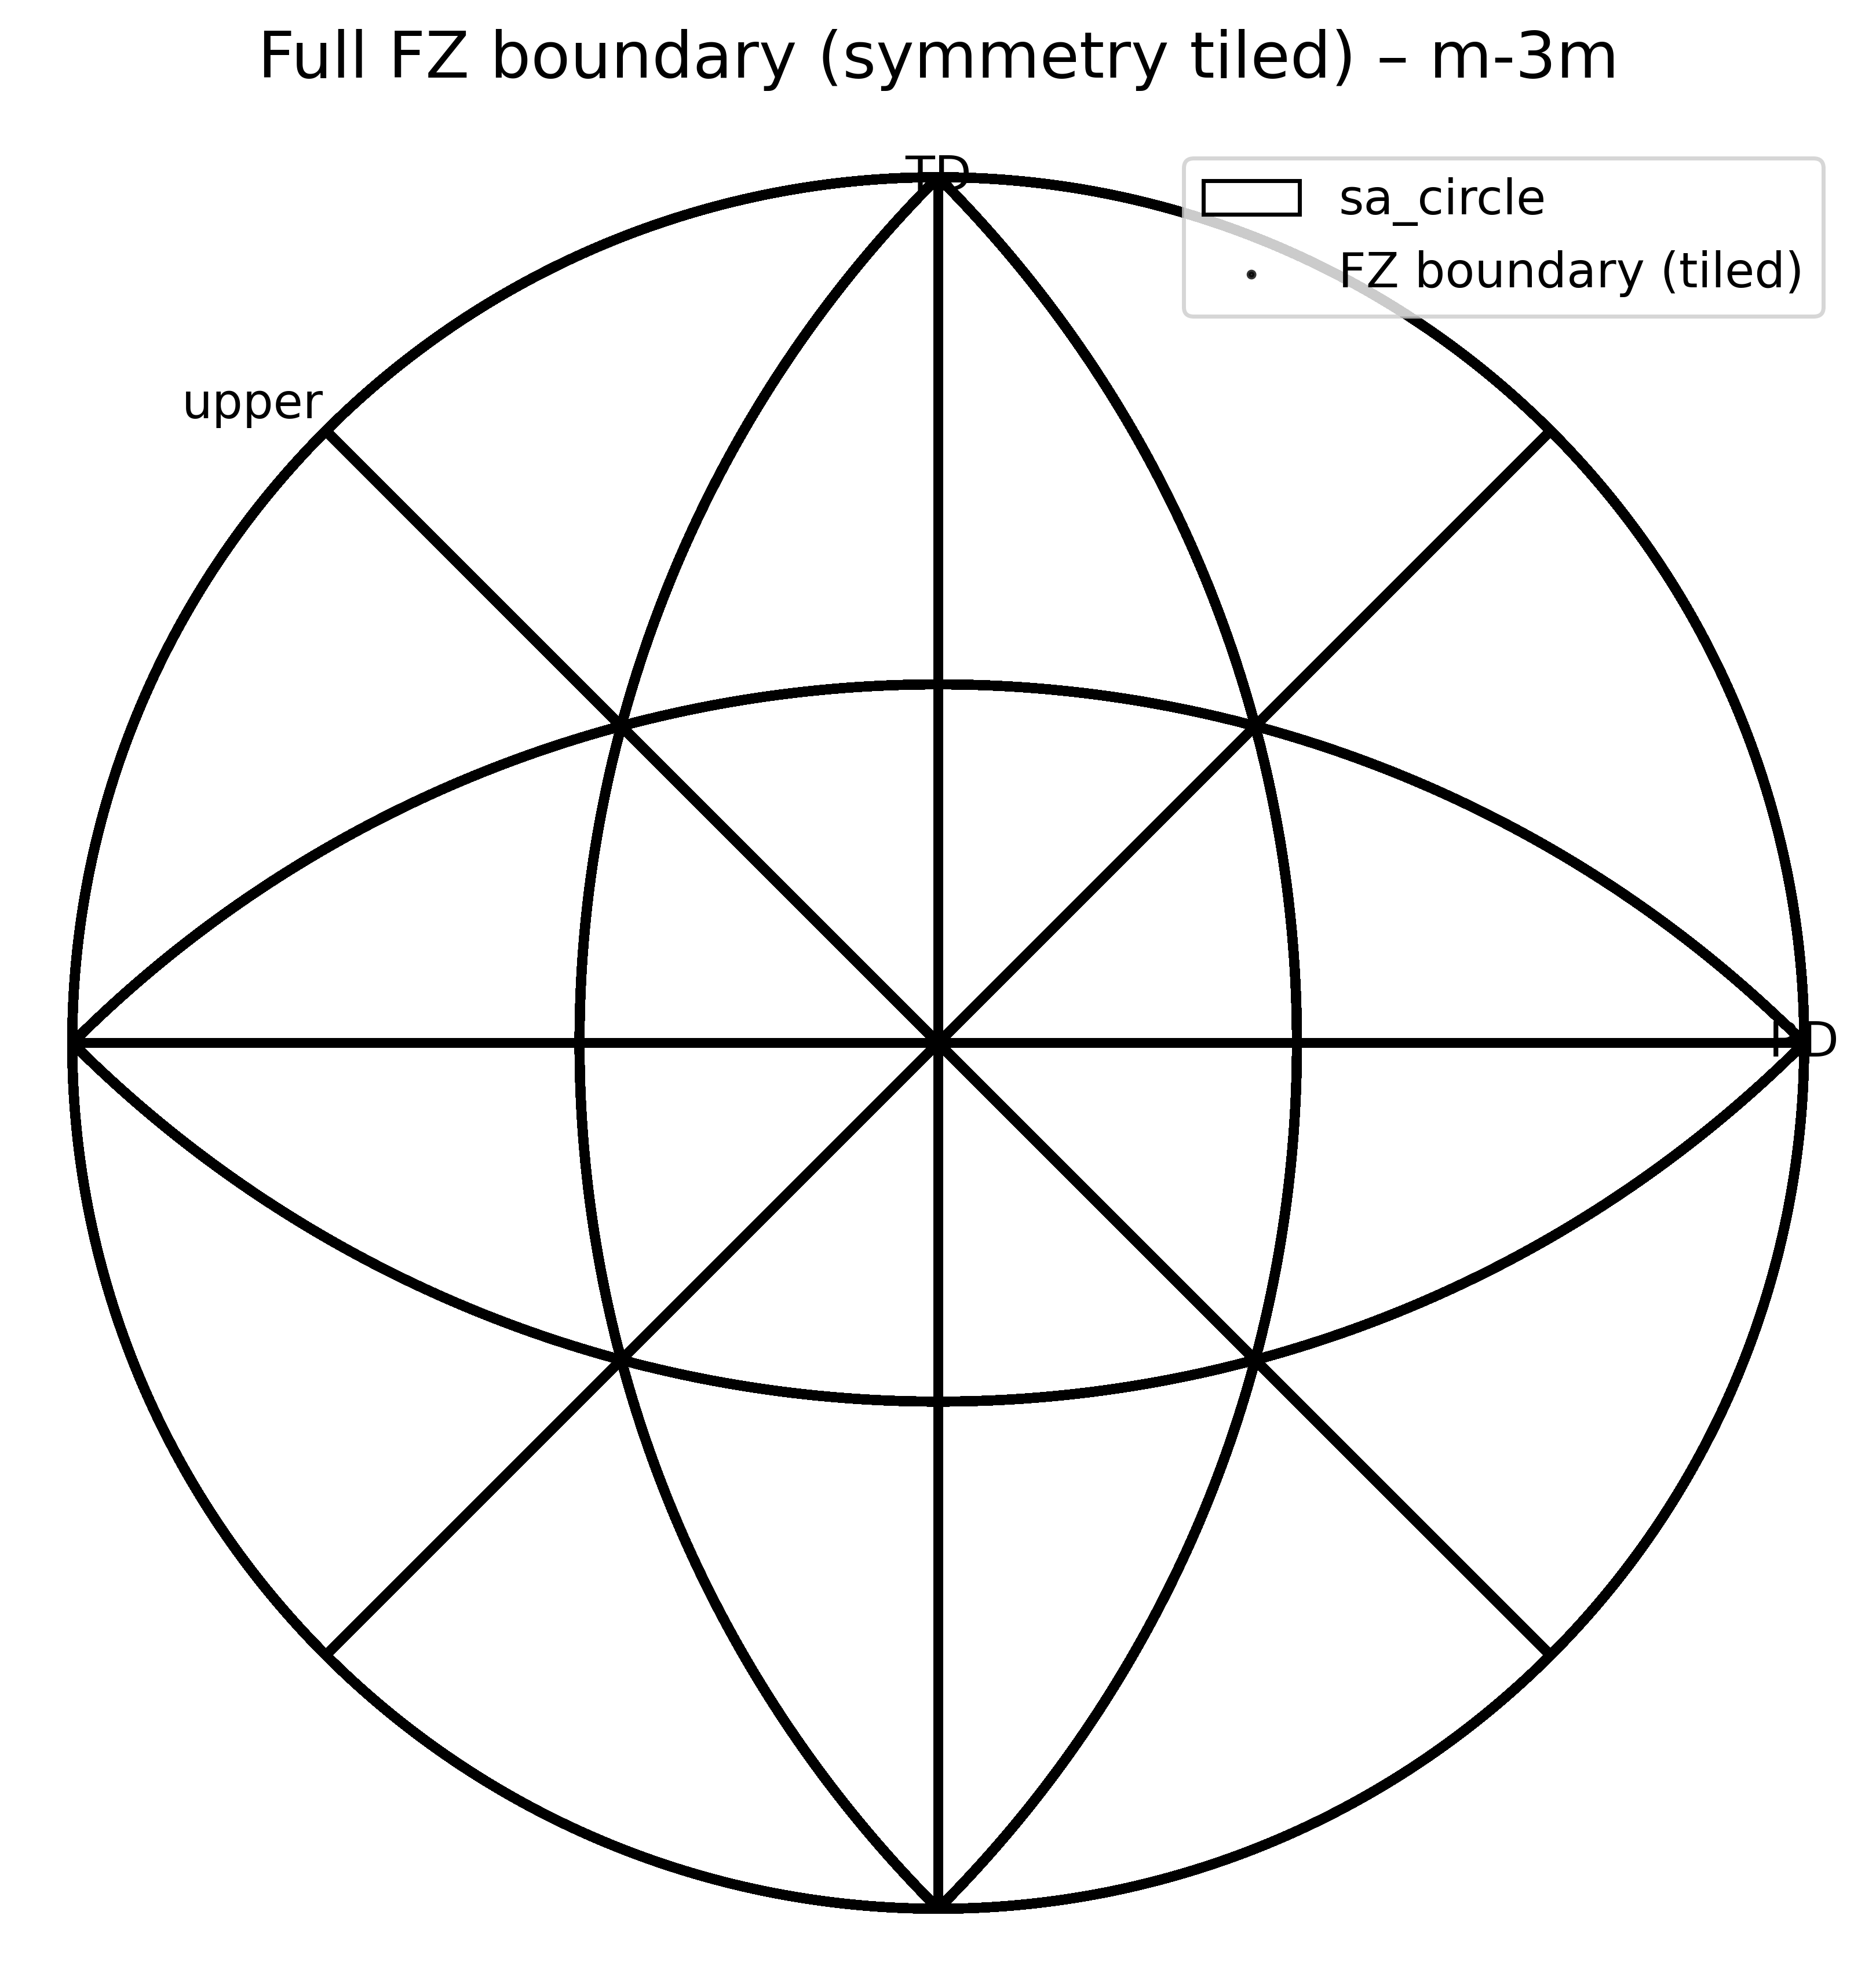

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

# --- Parameters ---
sym = symmetry.Oh  # cubic m-3m
n_boundary_points = 500

# --- Step 1: get boundary vertices of the FZ sector in 3D ---
sector = sym.fundamental_sector
v_boundary = sector.edges
v_data = v_boundary.data

# --- Interpolate along boundary segments ---
def interpolate_vectors(v_data, n_points):
    pts = []
    n_vertices = v_data.shape[0]
    for i in range(n_vertices):
        start = v_data[i]
        end = v_data[(i + 1) % n_vertices]
        for t in np.linspace(0, 1, n_points, endpoint=False):
            vec = (1 - t) * start + t * end
            vec /= np.linalg.norm(vec)
            pts.append(vec)
    return Vector3d(np.array(pts))

v_boundary_dense = interpolate_vectors(v_data, n_boundary_points)

# --- Step 2: Apply symmetry operators properly ---
sym_ops = Orientation(sym.data)
n_sym = sym_ops.size
n_vec = v_boundary_dense.size

# Tile vectors for each symmetry operator
v_tiled = Vector3d(np.tile(v_boundary_dense.data, (n_sym, 1)))

# Repeat symmetry operators accordingly
sym_tiled = Orientation(np.repeat(sym_ops.data, n_vec, axis=0))

# Multiply (now shapes match)
v_all = sym_tiled * v_tiled

# --- Step 3: plot the tiled boundary ---
fig, ax = plt.subplots(subplot_kw={"projection": "stereographic"}, figsize=(7, 7))
ax.scatter(v_all, c="black", s=2, alpha=0.8, label="FZ boundary (tiled)")

ax.set_title(f"Full FZ boundary (symmetry tiled) – {sym.name}", pad=14)
ax.set_labels("RD", "TD", None)
ax.show_hemisphere_label()
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.vector import Vector3d
from copy import deepcopy

def plot_sym_equivalents_on_unfolded_ipf(
    q_spatial,
    sym_class,
    ref_dir="Z",
    tol_deg=0.5,
    idx_select=None,
    n_boundary_points=400,
    out_png=None,
):
    """
    Plot symmetry equivalents of a selected outside-FZ orientation on unfolded IPF.
    """
    # --- Prepare orientation arrays ---
    q_flat = q_spatial.reshape(-1, 4)
    ori = Orientation(q_flat, symmetry=sym_class)
    ori_fz = ori.map_into_symmetry_reduced_zone()
    mis = (~ori_fz).outer(ori)
    ang = mis.angle
    outside_mask = ang > np.deg2rad(tol_deg)

    outside_idx = np.where(outside_mask)[0]
    if outside_idx.size == 0:
        print("[INFO] No orientations outside FZ found.")
        return

    # Pick a specific orientation (or default to the first one)
    if idx_select is None or idx_select >= outside_idx.size:
        idx_select = 0
    sel_idx = outside_idx[idx_select]
    ori_outside = ori[sel_idx]
    ori_fz_sel = ori_fz[sel_idx]
    mis_ang = np.rad2deg((~ori_fz_sel * ori_outside).angle)
    print(f"[INFO] Selected outside-FZ orientation at index {sel_idx}")
    print(f"       Misorientation to FZ representative: {mis_ang:.3f}°")

    # --- Get all symmetry equivalents ---
    sym_ops = Orientation(sym_class.data)
    ori_equiv = sym_ops * ori_outside

    # --- Project on stereographic plane ---
    ref_dirs = {"X": Vector3d.xvector(), "Y": Vector3d.yvector(), "Z": Vector3d.zvector()}
    ref_v = ref_dirs[ref_dir.upper()]
    v_equiv = ori_equiv * ref_v

    # --- Build FZ boundary (tiled) ---
    sector = sym_class.fundamental_sector
    v_boundary = sector.edges.data
    def interpolate_boundary(v_data, n_points):
        pts = []
        n_vertices = v_data.shape[0]
        for i in range(n_vertices):
            start = v_data[i]
            end = v_data[(i+1) % n_vertices]
            for t in np.linspace(0, 1, n_points, endpoint=False):
                vec = (1 - t)*start + t*end
                vec /= np.linalg.norm(vec)
                pts.append(vec)
        return np.array(pts)
    v_boundary_dense = interpolate_boundary(v_boundary, n_boundary_points)

    sym_ops = Orientation(sym_class.data)
    n_sym = sym_ops.size
    n_vec = v_boundary_dense.shape[0]
    v_tiled = Vector3d(np.tile(v_boundary_dense, (n_sym, 1)))
    sym_tiled = Orientation(np.repeat(sym_ops.data, n_vec, axis=0))
    v_boundary_all = sym_tiled * v_tiled

    # --- Plot ---
    fig, ax = plt.subplots(subplot_kw={"projection": "stereographic"}, figsize=(7, 7))
    ax.scatter(v_boundary_all, c="gray", s=1, alpha=0.4, label="FZ boundaries")

    # FZ representative (inside)
    ax.scatter(ori_fz_sel * ref_v, c="green", s=80, marker="x", label="FZ representative")

    # Original outside orientation
    ax.scatter(ori_outside * ref_v, c="red", s=120, marker="*", label="Outside orientation")

    # All symmetry equivalents
    ax.scatter(v_equiv, c="blue", s=25, alpha=0.7, label="Symmetry equivalents")

    ax.set_title(
        f"Unfolded IPF ({ref_dir}) — Outside orientation ({mis_ang:.2f}° off)",
        pad=14,
    )
    ax.set_labels("RD", "TD", None)
    ax.show_hemisphere_label()
    ax.legend(loc="upper right")

    if out_png:
        plt.tight_layout()
        fig.savefig(out_png, dpi=400, bbox_inches="tight")
        plt.close(fig)
        print(f"[INFO] Saved → {out_png}")
    else:
        plt.show()

# --- Usage example with your dataset ---
_, q_spatial = train_ds.get_numpy_spatial_quat(68)
plot_sym_equivalents_on_unfolded_ipf(q_spatial, train_ds.sym_class, ref_dir="Z")


[INFO] Selected outside-FZ orientation at index 0


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.vector import Vector3d
from copy import deepcopy

def plot_sym_equivalents_on_unfolded_ipf(
    q_spatial,
    sym_class,
    ref_dir="Z",
    tol_deg=0.5,
    idx_select=None,
    n_boundary_points=400,
    out_png=None,
):
    """
    Plot symmetry equivalents of a selected outside-FZ orientation on unfolded IPF.
    """
    # --- Prepare orientation arrays ---
    q_flat = q_spatial.reshape(-1, 4)
    ori = Orientation(q_flat, symmetry=sym_class)
    ori_fz = ori.map_into_symmetry_reduced_zone()
    mis = (~ori_fz).outer(ori)
    ang = mis.angle
    outside_mask = ang > np.deg2rad(tol_deg)

    outside_idx = np.where(outside_mask)[0]
    if outside_idx.size == 0:
        print("[INFO] No orientations outside FZ found.")
        return

    # Pick a specific orientation (or default to the first one)
    if idx_select is None or idx_select >= outside_idx.size:
        idx_select = 0
    sel_idx = outside_idx[idx_select]
    ori_outside = ori[sel_idx]
    ori_fz_sel = ori_fz[sel_idx]
    mis_ang = np.rad2deg((~ori_fz_sel * ori_outside).angle).item()
    print(f"[INFO] Selected outside-FZ orientation at index {sel_idx}")
    print(f"       Misorientation to FZ representative: {mis_ang:.3f}°")

    # --- Get all symmetry equivalents ---
    sym_ops = Orientation(sym_class.data)
    ori_equiv = sym_ops * ori_outside

    # --- Project on stereographic plane ---
    ref_dirs = {"X": Vector3d.xvector(), "Y": Vector3d.yvector(), "Z": Vector3d.zvector()}
    ref_v = ref_dirs[ref_dir.upper()]
    v_equiv = ori_equiv * ref_v

    # --- Build FZ boundary (tiled) ---
    sector = sym_class.fundamental_sector
    v_boundary = sector.edges.data
    def interpolate_boundary(v_data, n_points):
        pts = []
        n_vertices = v_data.shape[0]
        for i in range(n_vertices):
            start = v_data[i]
            end = v_data[(i+1) % n_vertices]
            for t in np.linspace(0, 1, n_points, endpoint=False):
                vec = (1 - t)*start + t*end
                vec /= np.linalg.norm(vec)
                pts.append(vec)
        return np.array(pts)
    v_boundary_dense = interpolate_boundary(v_boundary, n_boundary_points)

    sym_ops = Orientation(sym_class.data)
    n_sym = sym_ops.size
    n_vec = v_boundary_dense.shape[0]
    v_tiled = Vector3d(np.tile(v_boundary_dense, (n_sym, 1)))
    sym_tiled = Orientation(np.repeat(sym_ops.data, n_vec, axis=0))
    v_boundary_all = sym_tiled * v_tiled

    # --- Plot ---
    fig, ax = plt.subplots(subplot_kw={"projection": "stereographic"}, figsize=(7, 7))
    ax.scatter(v_boundary_all, c="gray", s=1, alpha=0.4, label="FZ boundaries")

    # FZ representative (inside)
    ax.scatter(ori_fz_sel * ref_v, c="green", s=80, marker="x", label="FZ representative")

    # Original outside orientation
    ax.scatter(ori_outside * ref_v, c="red", s=120, marker="*", label="Outside orientation")

    # All symmetry equivalents
    ax.scatter(v_equiv, c="blue", s=25, alpha=0.7, label="Symmetry equivalents")

    ax.set_title(
        f"Unfolded IPF ({ref_dir}) — Outside orientation ({mis_ang:.2f}° off)",
        pad=14,
    )
    ax.set_labels("RD", "TD", None)
    ax.show_hemisphere_label()
    ax.legend(loc="upper right")

    if out_png:
        plt.tight_layout()
        fig.savefig(out_png, dpi=400, bbox_inches="tight")
        plt.close(fig)
        print(f"[INFO] Saved → {out_png}")
    else:
        plt.show()

# --- Usage example with your dataset ---
_, q_spatial = train_ds.get_numpy_spatial_quat(68)
plot_sym_equivalents_on_unfolded_ipf(q_spatial, train_ds.sym_class, ref_dir="Z")


: 